# Tunneling at fixed $Q$: Euclidean saddle and seed diagnostics

## Abstract

This notebook covers the fixed-$Q$ Euclidean saddle and seed diagnostics for *Globally Charged Vacuum Decay* ([arXiv:2606.21653](https://arxiv.org/abs/2606.21653)). It walks through the reduced potential $\Omega$, one-dimensional $O(d)$ bounces, a short scan in $\omega$, and the full two-dimensional Euclidean solve with a unified seed framework. The emphasis is on the O(4)-connected saddle, energy decomposition in terms of $\rho_{\mathrm{phys}}$ and the hyperbolic phase $\alpha$, comparisons with other seeds, and final potential plots.

## Table of contents

1. [Project setup, imports, and global configuration](#1-project-setup-imports-and-global-configuration)
2. [Potential and vacua of $\Omega$](#2-potential-and-vacua-of-omega)
3. [One-dimensional bounce solutions at fixed $\omega$](#3-one-dimensional-bounce-solutions-at-fixed-omega)
4. [One-dimensional charge, energy, and density diagnostics](#4-one-dimensional-charge-energy-and-density-diagnostics)
5. [One-dimensional scan in $\omega$](#5-one-dimensional-scan-in-omega)
6. [Two-dimensional problem: conventions and solver logic](#6-two-dimensional-problem-conventions-and-solver-logic)
7. [Default 2D grid and solver parameters](#7-default-2d-grid-and-solver-parameters)
8. [Unified 2D seed system](#8-unified-2d-seed-system)
9. [Focus study: O(4)-inspired seed](#9-focus-study-o4-inspired-seed)
10. [2D Newton solve from O(4) seed and $\eta_0$ scan](#10-2d-newton-solve-from-o4-seed-and-eta_0-scan)
11. [Final O(4)-based 2D solution and 1D comparisons](#11-final-o4-based-2d-solution-and-1d-comparisons)
    - [11.1 Hyperbolic rapidity $\alpha$ alongside $\rho(r,\tau)$](#111-hyperbolic-rapidity-alpha-alongside-rrtau)
12. [Extended O(4) maps and beta ladder](#12-extended-o4-maps-and-beta-ladder)
    - [12.1 Beta continuation ladder](#121-beta-continuation-ladder-on-the-o4-branch)
    - [12.2 Side-by-side $\rho$ maps at selected $\beta$](#122-side-by-side-rho-maps-at-selected-beta)
13. [Energy decomposition and static-barrier comparisons](#13-energy-decomposition-and-static-barrier-comparisons)
    - [13.1 Comparison with the neutral $Q=0$ case](#131-comparison-with-the-neutral-q0-case)
    - [13.2 Charged Bitar–Chang barrier](#132-charged-bitar-chang-barrier)
    - [13.3 Static-barrier comparison plots](#133-static-barrier-comparison-plots)
14. [Parallel 2D analyses for O(3), O(1), and homogeneous seeds](#14-parallel-2d-analyses-for-o3-o1-and-homogeneous-seeds)
    - [14.1 O(3) static seed](#141-o3-static-seed)
    - [14.2 O(1) tau seed](#142-o1-tau-seed)
    - [14.3 Homogeneous seed](#143-homogeneous-seed)
15. [Interface contours, charge flow, and dielectric comparison](#15-interface-contours-charge-flow-and-dielectric-comparison)
    - [15.1 Symmetry-extended O(4) map](#151-symmetry-extended-o4-map)
    - [15.2 Reduced-$\omega$ contour study](#152-reduced-omega-contour-study)
    - [15.3 Numerical interface vs thin-wall dielectric ansatz](#153-numerical-interface-vs-thin-wall-dielectric-ansatz)
16. [Paper figures](#16-paper-figures)
    - [16.1 Scalar potential: two-branch construction](#161-scalar-potential-two-branch-construction)
    - [16.2 Effective potential branches colored by $Q_{\mathrm{hom}}/Q_{\max}$](#162-effective-potential-branches-colored-by-q_mathrmhomq_max)



## 1. Project Setup, Imports, and Global Configuration

We first set paths robustly, import all required backend modules once, and define global plotting/runtime configuration. The rest of the notebook reuses these objects and avoids repeated imports or duplicated setup cells.

The plotting style is configured globally with LaTeX-like serif/math fonts, consistent labels, and serif math fonts and consistent axis labels.



In [28]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import RegularGridInterpolator

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Robust project-root discovery (works if notebook is run from different cwd values)
def find_qubble_root(start: Path) -> Path:
    """Return the repository root containing Bubble_finder/ and Q_ball_finder/."""
    cur = start.resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "Bubble_finder").is_dir() and (parent / "Q_ball_finder").is_dir():
            return parent
    raise RuntimeError(
        "Could not locate the Qubble repository root. "
        "Run this notebook from inside the repository checkout."
    )


QUBBLE_ROOT = find_qubble_root(Path.cwd())
NOTEBOOK_DIR = QUBBLE_ROOT / "Bubble_finder" / "notebooks"

if str(QUBBLE_ROOT) not in sys.path:
    sys.path.insert(0, str(QUBBLE_ROOT))

from Bubble_finder.potential_bubble import V_phi, dV_dphi, d2V_dphi2, Omega_phi, vacua_of_Omega, dOmega_dphi
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V
from Bubble_finder.observables_1d import (
    compute_charge,
    compute_energy_minkowski_1d_spherical,
    compute_free_energy_grandcanonical,
)
from Bubble_finder.observables_2d import (
    compute_observables_tau0_ghost,
    compute_targets_tau0_ghost,
    compute_charge_tau0_ghost_2d,
)
from Bubble_finder.clean_analysis_helpers import (
    ModelParams,
    configure_matplotlib,
    solve_or_load_bounce_1d,
    compute_1d_observables,
    run_1d_scan,
    build_seed,
    run_newton_with_eta_scan,
    summarize_solution,
    compute_static_energy_minus_hom_vs_tau,
    plot_seed_maps,
    plot_solution_maps,
)

# Global runtime/plotting configuration
CFG = {
    "save_figures": True,
    "use_tex": True,
    "random_seed": 7,
    "figures_dir": NOTEBOOK_DIR / "figures",
}

np.random.seed(CFG["random_seed"])
CFG["figures_dir"].mkdir(parents=True, exist_ok=True)

configure_matplotlib(use_tex=CFG["use_tex"], fontsize=12, dpi=140)

print(f"Qubble root: {QUBBLE_ROOT}")
print(f"Figures dir:   {CFG['figures_dir']}")


## 2. Potential and Vacua of $\Omega$

We use the model potential $V(\phi)$ implemented in `potential_bubble.py`, and define the grand potential

$$
\Omega(\phi) = V(\phi) - \frac{1}{2}\,\omega^2\phi^2.
$$

For each fixed $\omega$, the extrema of $\Omega$ determine metastable and stable vacua. We denote by $\phi_{\mathrm{false}}$ the local minimum with higher $\Omega$, and by $\phi_{\mathrm{true}}$ the one with lower $\Omega$.

Because of the $-\tfrac12\omega^2\phi^2$ term, these vacua are $\omega$-dependent.

$\textbf{Disclaimer.}$ In *Globally Charged Vacuum Decay*, the solver variable $\phi$ corresponds to the physical modulus $\rho$.

$\textbf{THIN WALL CASE}$: Here for the thin wall case better to use 

MODEL = ModelParams(phi0=1.999999999, v1=1.0, v2=2.0)
OMEGA_REF = 1.3

as a starting solution.


Reference parameters: phi0=1.999, v1=1.0, v2=2.0, omega=0.95
False vacuum: phi_false = 1.0312018015
True vacuum:  phi_true  = 2.0656590991


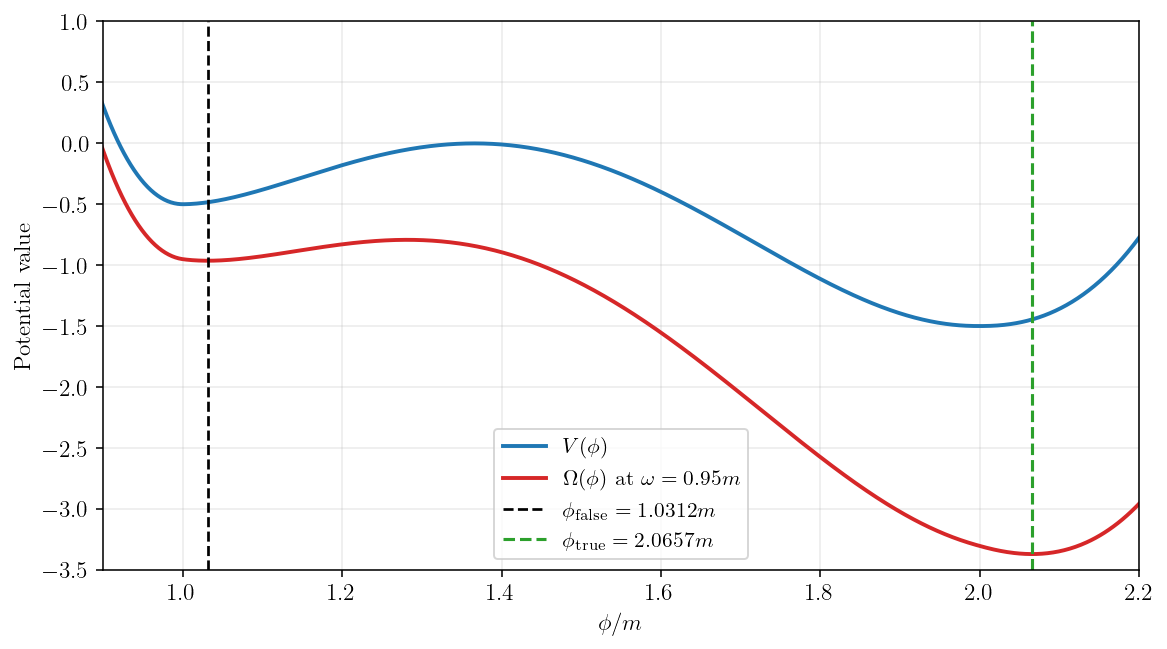

In [29]:
# Model parameters and reference omega
MODEL = ModelParams(phi0=1.999, v1=1.0, v2=2.0)
OMEGA_REF = 0.95

phi_grid = np.linspace(MODEL.v1-0.2, MODEL.v2 + 0.2, 1000)
V_vals = V_phi(phi_grid, MODEL.phi0, MODEL.v1, MODEL.v2)
Om_vals = Omega_phi(phi_grid, MODEL.phi0, MODEL.v1, MODEL.v2, OMEGA_REF)

phi_false_ref, phi_true_ref = vacua_of_Omega(
    MODEL.phi0, MODEL.v1, MODEL.v2, OMEGA_REF, verbose=False
)

print(f"Reference parameters: phi0={MODEL.phi0}, v1={MODEL.v1}, v2={MODEL.v2}, omega={OMEGA_REF}")
print(f"False vacuum: phi_false = {phi_false_ref:.10f}")
print(f"True vacuum:  phi_true  = {phi_true_ref:.10f}")

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(phi_grid, V_vals, color="C0", label=r"$V(\phi)$")
ax.plot(phi_grid, Om_vals, color="C3", label=rf"$\Omega(\phi)$ at $\omega={OMEGA_REF:.2f}m$")

ax.axvline(phi_false_ref, color="k", ls="--", lw=1.4, label=rf"$\phi_{{\mathrm{{false}}}}={phi_false_ref:.4f}m$")
ax.axvline(phi_true_ref, color="C2", ls="--", lw=1.6, label=rf"$\phi_{{\mathrm{{true}}}}={phi_true_ref:.4f}m$")

ax.set_xlabel(r"$\phi/m$")
ax.set_ylabel(r"Potential value")
ax.set_xlim(MODEL.v1*0.9, MODEL.v2*1.1)
ax.set_ylim(-3.5, 1)
#ax.set_title(r"$V(\phi)$ and $\Omega(\phi)$ on the same axis")
ax.legend(loc="best")

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "potential_and_omega_vacua.pdf", bbox_inches="tight")
plt.show()


## 3. One-Dimensional Bounce Solutions at Fixed $\omega$

For an $O(d)$-symmetric profile $\phi(r)$, the radial equation is

$$
\phi''(r) + \frac{d-1}{r}\phi'(r) = \frac{\partial \Omega}{\partial \phi}.
$$

We compute $d=1,3,4$:

- $d=1$: reference one-dimensional radial equation (useful as a limiting/profile diagnostic),
- $d=3$: finite-density thermal-like bounce sector,
- $d=4$: Euclidean instanton-like sector.

We do this both at a fixed reference $\omega$ and at $\omega=0$. All solutions are cached and reusable.

$\textbf{Disclaimer.}$ In *Globally Charged Vacuum Decay*, the solver variable $\phi$ corresponds to the physical modulus $\rho$.


In [30]:
DIMENSIONS = (1, 3, 4)
OMEGA_SET = {
    "omega_ref": float(OMEGA_REF),
    "omega_zero": 0.0,
}

bounces_fixed: dict[str, dict[int, dict]] = {k: {} for k in OMEGA_SET}

for om_label, om in OMEGA_SET.items():
    for d in DIMENSIONS:
        bounces_fixed[om_label][d] = solve_or_load_bounce_1d(
            None,
            MODEL,
            omega=om,
            d=d,
            rmax=260.0,
            n_grid_points=1000,
            max_iter=180,
            verbose=False,
        )

print("1D bounce profiles:")
for om_label, dct in bounces_fixed.items():
    print(f"  {om_label}:")
    for d, b in dct.items():
        src = "cache" if b["from_cache"] else "new"
        print(f"    O({d}): points={len(b['r'])}, phi_false={b['phi_false']:.6f}, source={src}")


1D bounce profiles:
  omega_ref:
    O(1): points=1000, phi_false=1.031202, source=new
    O(3): points=1000, phi_false=1.031202, source=new
    O(4): points=1000, phi_false=1.031202, source=new
  omega_zero:
    O(1): points=1000, phi_false=1.000000, source=new
    O(3): points=1000, phi_false=1.000000, source=new
    O(4): points=1000, phi_false=1.000000, source=new


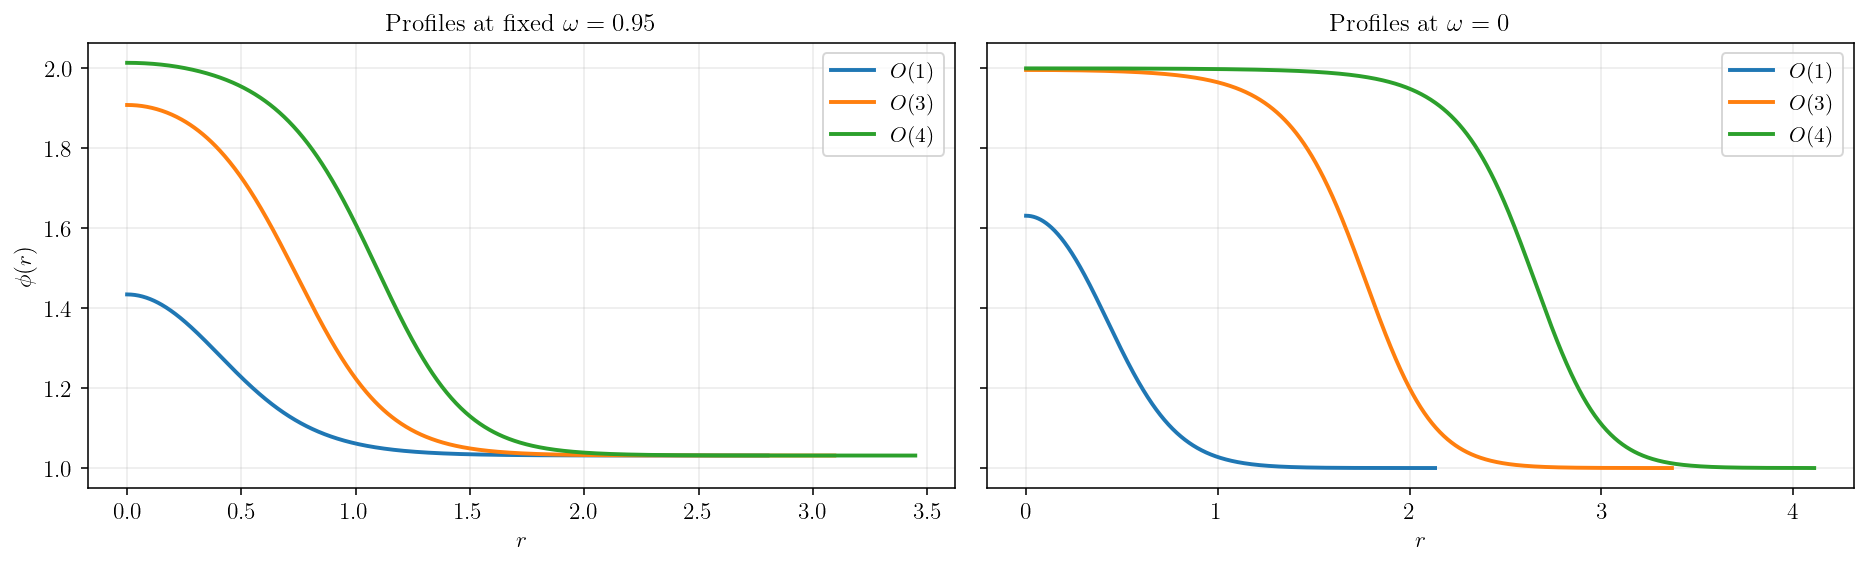

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), sharey=True)

for d in DIMENSIONS:
    b = bounces_fixed["omega_ref"][d]
    axes[0].plot(b["r"], b["phi"], label=rf"$O({d})$")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\phi(r)$")
axes[0].set_title(rf"Profiles at fixed $\omega={OMEGA_REF:.2f}$")
axes[0].legend()

for d in DIMENSIONS:
    b = bounces_fixed["omega_zero"][d]
    axes[1].plot(b["r"], b["phi"], label=rf"$O({d})$")
axes[1].set_xlabel(r"$r$")
axes[1].set_title(r"Profiles at $\omega=0$")
axes[1].legend()

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "bounce_profiles_fixed_and_zero_omega.pdf", bbox_inches="tight")
plt.show()


## 4. One-Dimensional Charge, Energy, and Density Diagnostics

For fixed $\omega$, we report and compare:

- **Charge** $Q$,
- **Physical Minkowski energy** $E_M$,
- **Grand-canonical functional** $F_\omega = E_M - \omega Q$.

In this notebook, physical energy comparisons always use $E_M$. The quantity $F_\omega$ is still useful for fixed-$\omega$ barrier diagnostics. We also plot radial charge and Minkowski-energy density integrands.


1D integrated observables at fixed omega:
  O(1): Q=9.42495384e+01, E_M=1.23971029e+00, F_omega=-8.82973512e+01
  O(3): Q=1.31420513e+02, E_M=6.95099943e+00, F_omega=-1.17898487e+02
  O(4): Q=1.89933044e+02, E_M=1.48908916e+01, F_omega=-1.65545500e+02


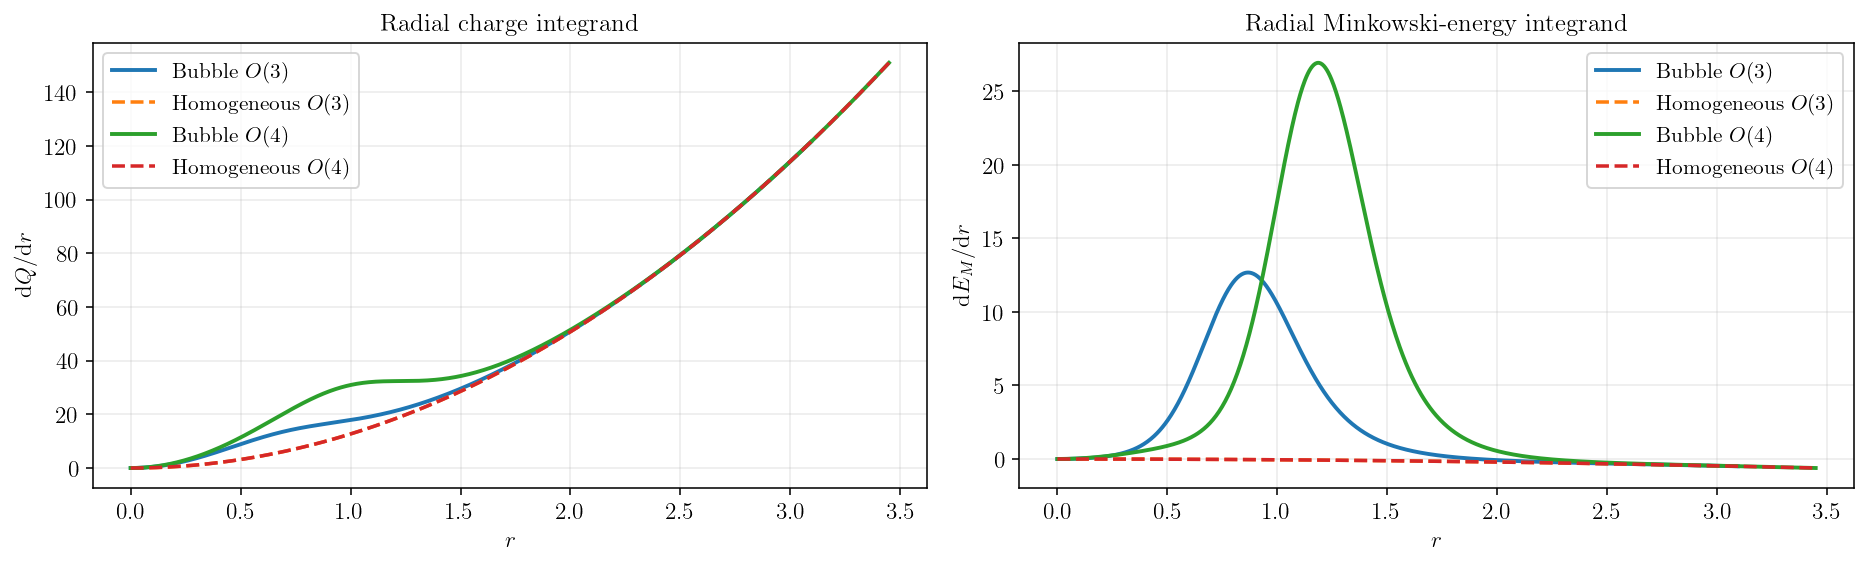

In [32]:
obs_fixed = {}
for d in DIMENSIONS:
    obs_fixed[d] = compute_1d_observables(MODEL, bounces_fixed["omega_ref"][d])

print("1D integrated observables at fixed omega:")
for d in DIMENSIONS:
    o = obs_fixed[d]
    print(f"  O({d}): Q={o['Q']:.8e}, E_M={o['E_M']:.8e}, F_omega={o['F_omega']:.8e}")

# Density-like radial integrands (for visualization)
V_of_rho = lambda rho: V_phi(rho, MODEL.phi0, MODEL.v1, MODEL.v2)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))

for d in (3, 4):
    b = bounces_fixed["omega_ref"][d]
    r = b["r"]
    phi = b["phi"]
    phi_hom = float(b["phi_false"])  # homogeneous (false-vacuum) amplitude at the same omega

    dphi = np.gradient(phi, r, edge_order=2)
    dphi[0] = 0.0

    charge_integrand = 4.0 * np.pi * OMEGA_REF * r**2 * phi**2
    energy_integrand = 4.0 * np.pi * r**2 * (
        0.5 * dphi**2 + 0.5 * OMEGA_REF**2 * phi**2 + V_of_rho(phi)
    )

    charge_integrand_hom = 4.0 * np.pi * OMEGA_REF * r**2 * phi_hom**2
    energy_integrand_hom = 4.0 * np.pi * r**2 * (
        0.5 * OMEGA_REF**2 * phi_hom**2 + V_of_rho(phi_hom)
    )

    axes[0].plot(r, charge_integrand, label=rf"Bubble $O({d})$")
    axes[0].plot(r, charge_integrand_hom, "--", lw=1.8, label=rf"Homogeneous $O({d})$")

    axes[1].plot(r, energy_integrand, label=rf"Bubble $O({d})$")
    axes[1].plot(r, energy_integrand_hom, "--", lw=1.8, label=rf"Homogeneous $O({d})$")

axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\mathrm{d}Q/\mathrm{d}r$")
axes[0].set_title(r"Radial charge integrand")
axes[0].legend()

axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\mathrm{d}E_M/\mathrm{d}r$")
axes[1].set_title(r"Radial Minkowski-energy integrand")
axes[1].legend()

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "one_dimensional_density_profiles.pdf", bbox_inches="tight")
plt.show()


## 5. One-Dimensional Scan in $\omega$

We scan $\omega$ from $0$ up to the maximal range where two distinct vacua of $\Omega(\phi)$ still exist. For each $\omega$ we solve and cache the $O(3)$ and $O(4)$ profiles, then compute key observables.

Main outputs:

- profile evolution with $\omega$,
- bounce center value $\phi(0)$ vs $\omega$,
- $Q(\omega)$,
- $E_M(\omega)$,
- $F_\omega(\omega)$ for reference.


In [33]:
def estimate_omega_max(model: ModelParams, omega_hi: float = 1.4, ntest: int = 240) -> float:
    oms = np.linspace(0.0, omega_hi, ntest)
    ok = []
    for om in oms:
        try:
            vacua_of_Omega(model.phi0, model.v1, model.v2, float(om), verbose=False)
            ok.append(True)
        except Exception:
            ok.append(False)
    ok = np.asarray(ok, dtype=bool)
    if not np.any(ok):
        raise RuntimeError("No valid omega found in tested range")
    last = np.where(ok)[0][-1]
    return float(oms[last])

OMEGA_MAX = estimate_omega_max(MODEL)
omega_scan = np.linspace(0.0, 0.999 * OMEGA_MAX, 2)
print(f"Estimated omega_max ~ {OMEGA_MAX:.6f}")
print(f"Scan points: {len(omega_scan)} in [0, {omega_scan[-1]:.6f}]")

SCAN_1D_RMAX = 260.0

scan_profiles = run_1d_scan(
    None,
    MODEL,
    omega_values=omega_scan,
    dimensions=(3, 4),
    rmax=SCAN_1D_RMAX,
    n_grid_points=1300,
    max_iter=170,
    verbose=False,
)

scan_summary = {3: [], 4: []}
for d in (3, 4):
    for b in scan_profiles[d]:
        obs = compute_1d_observables(MODEL, b)
        scan_summary[d].append(
            {
                "omega": b["omega"],
                "phi_center": b["phi0_center"],
                "phi_false": b["phi_false"],
                "phi_true": b["phi_true"],
                **obs,
            }
        )

for d in (3, 4):
    scan_summary[d] = sorted(scan_summary[d], key=lambda x: x["omega"])

print(f"Converged points: O(3)={len(scan_summary[3])}, O(4)={len(scan_summary[4])}")


Estimated omega_max ~ 1.341423
Scan points: 2 in [0, 1.340081]
Converged points: O(3)=2, O(4)=2


## 6. Two-Dimensional Problem: Conventions and Solver Logic

We now move to the Euclidean 2D problem in $(r,\tau)$ with half-interval in Euclidean time. The solver uses rotated variables and two partner fields $(y,\bar y)$.

The key mapping is:

$$
\phi_{\mathrm{rot}} = \varphi_0 + \frac{y}{r},\qquad
\bar\phi_{\mathrm{rot}} = \varphi_0 + \frac{\bar y}{r},
$$

with twisted closure at $\tau=-\beta/2$ and reflection/swap at $\tau=0$.

The Newton method solves the nonlinear residual on the full 2D grid. The twist parameter $\eta_0$ is scanned (with a bracketing/root procedure) so that the final 2D solution matches a chosen target charge.

Seed quality is crucial: we compare four seed families with a unified interface and the same downstream solver pipeline.


## 7. Default 2D Grid and Solver Parameters

Default analysis values are centralized here:

- $L_r = 6$,
- $\beta = 10$,
- grid approximately $60\times 60$,
- one central dictionary for Newton/twist options.

These defaults are used consistently in all seed subsections unless explicitly overridden.

$\textbf{Note:}$ For more refined solutions or the Minkowski evolution better to use a resolution of $N_r \times N_\tau=600 \times 200$.


In [34]:
# 2D default configuration (centralized)
# IMPORTANT: force the homogeneous background to the FALSE vacuum branch.
phi_false_2d, phi_true_2d = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, float(OMEGA_REF), verbose=False)
rho0_false_solver_units = float(phi_false_2d / np.sqrt(2.0))

CFG_2D = {
    "Nr": 60,
    "Ntau": 60,
    "Lr": 6.0,
    "beta": 10.0,
    "omega_ref": float(OMEGA_REF),
    "eta0_init": 0.0,
    "newton_tol": 1e-8,
    "newton_max_iter": 45,
    "damping": 0.8,
    "max_backtracks": 28,
    "rho0_bracket": (0.6, 1.6),
    "rho0_false": rho0_false_solver_units,
    "complex_saddle": True,
    "verbose": True,
}

# Build potential backend for 2D solver from project functions
U, dU, d2U = make_potential_from_V(
    V_phi,
    dV_dphi,
    d2V_dphi2,
    MODEL.phi0,
    MODEL.v1,
    MODEL.v2,
)

# 1D profiles used to build the 2D seed families at fixed omega
profiles_for_seeds = {
    "O1": bounces_fixed["omega_ref"][1],
    "O3": bounces_fixed["omega_ref"][3],
    "O4": bounces_fixed["omega_ref"][4],
}

# Target charge on the current 2D solver/grid (same convention as SeedSearch_NewAnsatz)
_solver_target = Bubble2DSolver(
    Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=CFG_2D["beta"],
        omega_ref=CFG_2D["omega_ref"],
        eta0=float(CFG_2D["eta0_init"]),
        rho0=float(CFG_2D["rho0_false"]),
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=False,
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    ),
    U,
    dU,
    d2U,
)
_targets_2d = compute_targets_tau0_ghost(
    _solver_target,
    subtract_background_charge=False,
)
Q_TARGET_2D = float(_targets_2d["Q"])

# Keep the previous 1D-based estimate for reference/diagnostics
Q_TARGET_2D_FROM_1D = compute_1d_observables(
    MODEL,
    bounces_fixed["omega_ref"][3],
    r_max_ref=CFG_2D["Lr"],
)["Q"]

print(f"2D vacua at omega_ref: phi_false={phi_false_2d:.10e}, phi_true={phi_true_2d:.10e}")
print(f"Forced solver rho0 (|phi| units): {CFG_2D['rho0_false']:.10e}")
print(f"Forced homogeneous rho_phys = sqrt(2)*rho0: {np.sqrt(2.0)*CFG_2D['rho0_false']:.10e}")
print(f"Target charge for 2D eta0 scan (current 2D grid): Q_target = {Q_TARGET_2D:.10e}")


2D vacua at omega_ref: phi_false=1.0312018015e+00, phi_true=2.0656590991e+00
Forced solver rho0 (|phi| units): 7.2916978659e-01
Forced homogeneous rho_phys = sqrt(2)*rho0: 1.0312018015e+00
Target charge for 2D eta0 scan (current 2D grid): Q_target = 9.1401070247e+02


## 8. Unified 2D Seed System

We define four seed types through a single interface `build_seed(...)`:

1. `O4_seed`: profile based on $\rho_E = \sqrt{r^2+\tau^2}$ from the 1D $O(4)$ solution,
2. `O3_static_seed`: 1D $O(3)$ profile in $r$, constant in $\tau$,
3. `O1_tau_seed`: 1D $O(1)$ profile in $|\tau|$, constant in $r$,
4. `homogeneous_seed`: trivial homogeneous false-vacuum seed.

This logic is centralized in `clean_analysis_helpers.py` and reused in all 2D subsections.


In [35]:
def make_solver(eta0: float = 0.0, verbose: bool = True) -> Bubble2DSolver:
    settings = Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=CFG_2D["beta"],
        omega_ref=CFG_2D["omega_ref"],
        eta0=float(eta0),
        rho0=float(CFG_2D["rho0_false"]),
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=bool(verbose),
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    )
    return Bubble2DSolver(settings, U, dU, d2U)

SEED_TYPES = ["O4_seed", "O3_static_seed", "O1_tau_seed", "homogeneous_seed"]
seed_preview = {}
solver_preview = make_solver(eta0=0.0, verbose=False)
for s in SEED_TYPES:
    x0, rho_seed = build_seed(solver_preview, s, profiles_for_seeds)
    seed_preview[s] = {"x0": x0, "rho_seed": rho_seed}

print("Seed system initialized for:")
for s in SEED_TYPES:
    arr = seed_preview[s]["rho_seed"]
    print(f"  {s:<18} shape={arr.shape}, min={arr.min():.6f}, max={arr.max():.6f}")


Seed system initialized for:
  O4_seed            shape=(60, 60), min=0.729170, max=1.421682
  O3_static_seed     shape=(60, 60), min=0.729170, max=1.344451
  O1_tau_seed        shape=(60, 60), min=0.729170, max=1.012525
  homogeneous_seed   shape=(60, 60), min=0.729170, max=0.729170


## 9. Focus Study: O(4)-Inspired Seed

Before the full multi-seed comparison, we first construct and validate the `O4_seed` carefully. We inspect:

- the full 2D seed map,
- the $r=0$ slice vs $\tau$,
- the $\tau=0$ slice vs $r$,

and compare these with one-dimensional reference profiles ($O(4)$, $O(3)$, $O(1)$) to confirm consistency of the construction.


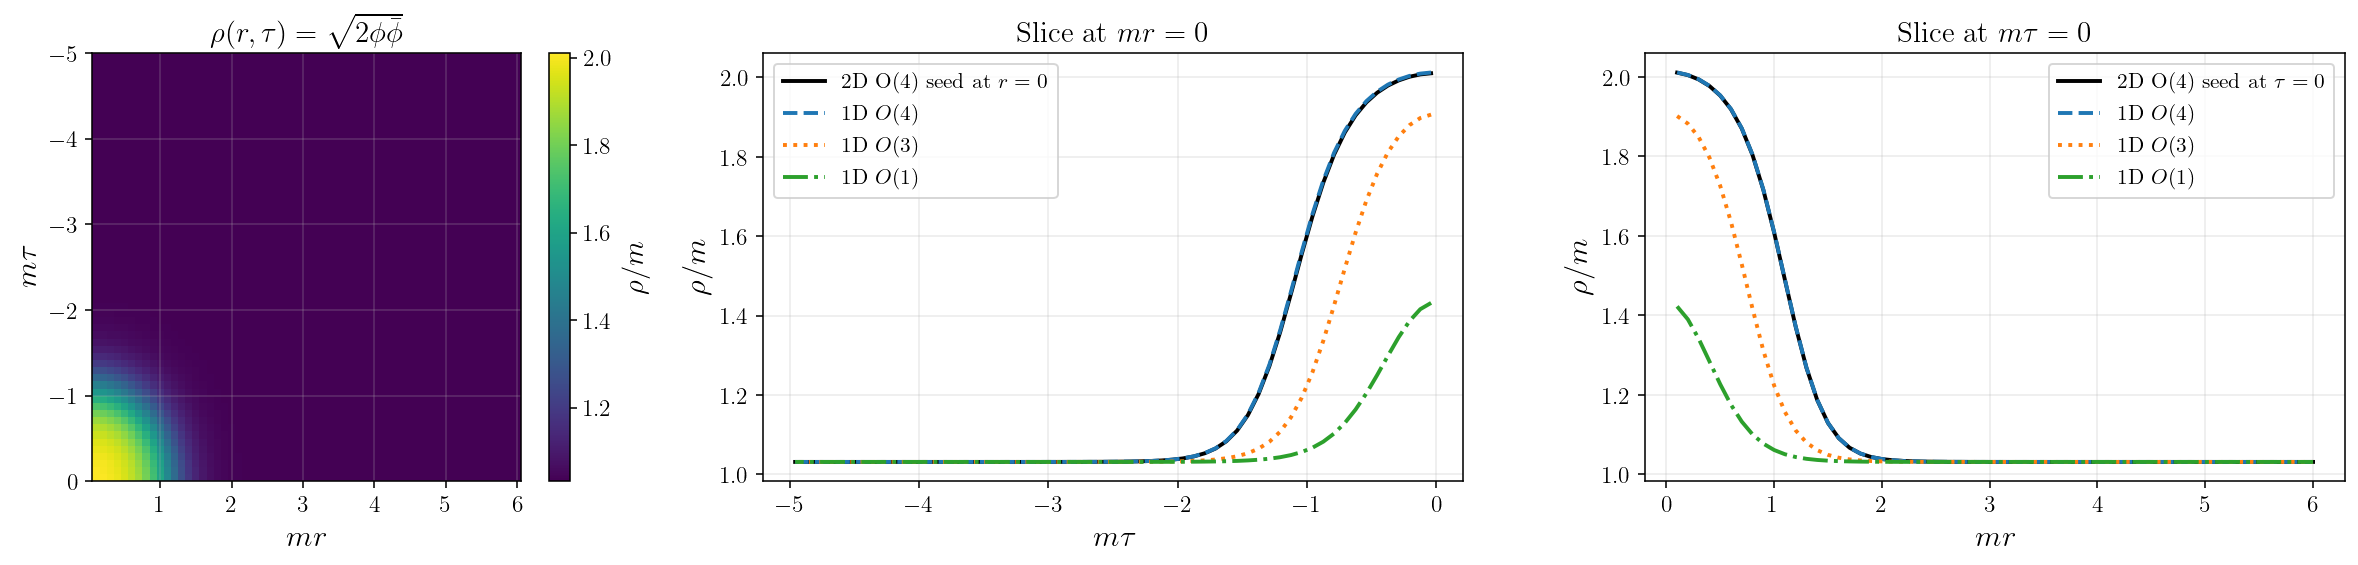

In [36]:
solver_o4_seed = make_solver(eta0=0.0, verbose=False)
x0_o4_seed, rho_o4_seed = build_seed(solver_o4_seed, "O4_seed", profiles_for_seeds)

r2d = np.asarray(solver_o4_seed.grid.r, dtype=float)
tau2d = np.asarray(solver_o4_seed.grid.tau, dtype=float)

# Single horizontal strip: 2D map + two profile comparisons
fig, ax = plt.subplots(1, 3, figsize=(18.0, 4.2))

im = ax[0].pcolormesh(r2d, tau2d, (np.sqrt(2) * rho_o4_seed).T, shading="auto", cmap="viridis", rasterized=True)
ax[0].set_xlabel(r"$mr$", fontsize=16)
ax[0].set_ylabel(r"$m\tau$", fontsize=16)
ax[0].set_title(fr"$\rho(r,\tau)=\sqrt{{2 \phi \bar\phi}}$", fontsize=15)
ax[0].invert_yaxis()  # tau-origin at the top
ax[0].set_box_aspect(1)  # square panel
cbar0 = fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.set_label(r"$\rho/m$", fontsize=15)
cbar0.ax.tick_params(labelsize=12)

# r=0 slice as a function of tau
ax[1].plot(tau2d, np.sqrt(2) * rho_o4_seed[0, :], label=r"2D O(4) seed at $r=0$", color="k")
ax[1].plot(tau2d, np.interp(np.abs(tau2d), bounces_fixed["omega_ref"][4]["r"], bounces_fixed["omega_ref"][4]["phi"]), ls="--", label=r"1D $O(4)$")
ax[1].plot(tau2d, np.interp(np.abs(tau2d), bounces_fixed["omega_ref"][3]["r"], bounces_fixed["omega_ref"][3]["phi"]), ls=":", label=r"1D $O(3)$")
ax[1].plot(tau2d, np.interp(np.abs(tau2d), bounces_fixed["omega_ref"][1]["r"], bounces_fixed["omega_ref"][1]["phi"]), ls="-.", label=r"1D $O(1)$")
ax[1].set_xlabel(r"$m\tau$", fontsize=16)
ax[1].set_ylabel(r"$\rho/m$", fontsize=16)
ax[1].set_title(r"Slice at $mr=0$", fontsize=15)
ax[1].legend(fontsize=11)

# tau=0 slice as a function of r
ax[2].plot(r2d, np.sqrt(2) * rho_o4_seed[:, 0], label=r"2D O(4) seed at $\tau=0$", color="k")
ax[2].plot(r2d, np.interp(r2d, bounces_fixed["omega_ref"][4]["r"], bounces_fixed["omega_ref"][4]["phi"]), ls="--", label=r"1D $O(4)$")
ax[2].plot(r2d, np.interp(r2d, bounces_fixed["omega_ref"][3]["r"], bounces_fixed["omega_ref"][3]["phi"]), ls=":", label=r"1D $O(3)$")
ax[2].plot(r2d, np.interp(r2d, bounces_fixed["omega_ref"][1]["r"], bounces_fixed["omega_ref"][1]["phi"]), ls="-.", label=r"1D $O(1)$")
ax[2].set_xlabel(r"$mr$", fontsize=16)
ax[2].set_ylabel(r"$\rho/m$", fontsize=16)
ax[2].set_title(r"Slice at $m\tau=0$", fontsize=15)
ax[2].legend(fontsize=11)
for axi in ax:
    axi.tick_params(axis="both", labelsize=12)

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "seed_O4_vs_1d_profiles.pdf", bbox_inches="tight")
plt.show()


## 10. 2D Newton Solve from O(4) Seed and $\eta_0$ Scan

Starting from the $O(4)$-inspired seed, we first run a full Newton solve at $\eta_0=0$ with verbose output.

Then we scan $\eta_0$ in fixed steps from that point, detect the first charge-sign crossing relative to $Q_{\mathrm{target}}$, and finally refine with `brentq` while continuously warm-starting from the last Newton state.

We store diagnostics $(\eta_0, Q, E, \|F\|)$ for post-analysis.


In [37]:
def _newton_compact_pat():
    import re
    return re.compile(
        r"iter=(\d+).*?\|\|F\|\|=([+\-0-9.eE]+).*?rhoQ=([+\-0-9.eE]+).*?rhoE=([+\-0-9.eE]+).*?"
        r"rho_Q/rho_Q_ref=([+\-0-9.eE]+).*?rho_E/rho_E_ref=([+\-0-9.eE]+)"
    )


def _print_newton_compact_from_line(line, pat=None):
    if "[Newton-explicit]" not in line:
        return
    pat = pat or _newton_compact_pat()
    m = pat.search(line)
    if m is None:
        return
    it = int(m.group(1))
    nF = float(m.group(2))
    q_val = float(m.group(3))
    e_val = float(m.group(4))
    q_ratio = float(m.group(5))
    e_ratio = float(m.group(6))
    print(
        f"[Newton-compact] iter={it:02d}  ||F||={nF:.3e}  "
        f"rho_Q={q_val:.8e}  rho_E={e_val:.8e}  "
        f"rho_Q/rho_Q*= {q_ratio:.6f}  rho_E/rho_E*= {e_ratio:.6f}",
        flush=True,
    )


class _StdoutNewtonCompactLive:
    """Parse [Newton-explicit] lines from solve() and emit [Newton-compact] immediately."""

    def __init__(self, stream):
        import re
        self._stream = stream
        self._buf = ""
        self._pat = _newton_compact_pat()

    def write(self, text):
        if not text:
            return
        self._buf += text
        while "\n" in self._buf:
            line, self._buf = self._buf.split("\n", 1)
            _print_newton_compact_from_line(line, self._pat)

    def flush(self):
        if self._buf:
            _print_newton_compact_from_line(self._buf, self._pat)
            self._buf = ""
        self._stream.flush()

    def isatty(self):
        return getattr(self._stream, "isatty", lambda: False)()


def _solve_at_eta_local(slv, eta, x_init, verbose=False, newton_live=False):
    import io
    import sys
    from contextlib import redirect_stdout

    slv.settings.eta0 = float(eta)
    slv.eta0 = float(eta)

    use_compact = bool(verbose or newton_live)
    if use_compact and newton_live:
        print(f"[Newton-compact] starting solve at eta0={float(eta):.6f}", flush=True)
        live_out = _StdoutNewtonCompactLive(sys.stdout)
        with redirect_stdout(live_out):
            sol_eta = slv.solve(x_init, verbose=True, verbose_success_block=False)
        live_out.flush()
    elif use_compact:
        buf = io.StringIO()
        with redirect_stdout(buf):
            sol_eta = slv.solve(x_init, verbose=True, verbose_success_block=False)

        for line in buf.getvalue().splitlines():
            _print_newton_compact_from_line(line)
    else:
        sol_eta = slv.solve(x_init, verbose=False, verbose_success_block=False)

    q_eta = float(
        compute_charge_tau0_ghost_2d(
            slv,
            sol_eta.y,
            sol_eta.ybar,
            subtract_background=False,
        )
    )
    e_eta = float(sol_eta.E_tau0)
    r_eta = float(sol_eta.residual_norm)
    return q_eta, e_eta, r_eta, sol_eta


def _eta_scan_match_charge_local(
    slv,
    x_seed,
    Q_target_here,
    eta_start=0.0,
    d_eta=0.02,
    max_steps=80,
    tol_q=1e-6,
    scan_label="eta-scan",
    newton_live=False,
):
    tol_abs = float(tol_q * max(1.0, abs(Q_target_here)))
    history = []

    targets = compute_targets_tau0_ghost(slv, subtract_background_charge=False)
    Q_target = float(targets["Q"])
    E_target = float(targets["E"])

    print("[Targets] eta0 scan references (total observables):")
    print(f"  Q_target_total = {Q_target:.8e}")
    print(f"  E_target_total = {E_target:.8e}")

    def _print_compact_line(tag, eta, q_val, e_val):
        q_ratio = q_val / Q_target if abs(Q_target) > 1e-30 else np.nan
        e_ratio = e_val / E_target if abs(E_target) > 1e-30 else np.nan
        print(
            f"[{tag}] eta={eta:.6f}  Q_total={q_val:.8e}  E_total={e_val:.8e}  "
            f"Q_total/Q*= {q_ratio:.6f}  E_total/E*= {e_ratio:.6f}"
        )

    # First solve at eta=0 with full Newton verbose output
    eta_curr = float(eta_start)
    q_curr, e_curr, r_curr, sol_curr = _solve_at_eta_local(slv, eta_curr, x_seed, verbose=False, newton_live=newton_live)
    x_seed = np.asarray(sol_curr.x, dtype=float).copy()
    history.append({"eta0": eta_curr, "Q": q_curr, "E": e_curr, "residual": r_curr})

    _print_compact_line(scan_label, eta_curr, q_curr, e_curr)
    if abs(q_curr - Q_target_here) <= tol_abs:
        return sol_curr, {
            "eta0": eta_curr,
            "eta_bracket_used": (eta_curr, eta_curr),
            "history": history,
        }

    eta_prev, q_prev = eta_curr, q_curr
    crossed = False

    # Step scan from eta=0, no initial global bracketing
    for _ in range(int(max_steps)):
        eta_prev, q_prev = eta_curr, q_curr
        if q_curr < Q_target_here:
            eta_curr += d_eta
        else:
            eta_curr -= d_eta

        q_curr, e_curr, r_curr, sol_curr = _solve_at_eta_local(slv, eta_curr, x_seed, verbose=False, newton_live=False)
        x_seed = np.asarray(sol_curr.x, dtype=float).copy()
        history.append({"eta0": eta_curr, "Q": q_curr, "E": e_curr, "residual": r_curr})
        _print_compact_line(scan_label, eta_curr, q_curr, e_curr)

        if (q_prev - Q_target_here) * (q_curr - Q_target_here) <= 0:
            crossed = True
            break

    if not crossed:
        raise RuntimeError("O4 eta-scan did not cross target charge within max_steps")

    eta_lo, eta_hi = (eta_prev, eta_curr) if eta_prev < eta_curr else (eta_curr, eta_prev)
    state = {"x_seed": x_seed}
    cache = {}

    def _f_eta(eta):
        key = round(float(eta), 12)
        if key in cache:
            return cache[key]["Q"] - Q_target_here

        q_val, e_val, r_val, sol_val = _solve_at_eta_local(slv, float(eta), state["x_seed"], verbose=False, newton_live=False)
        state["x_seed"] = np.asarray(sol_val.x, dtype=float).copy()
        cache[key] = {"Q": q_val, "E": e_val, "residual": r_val}
        history.append({"eta0": float(eta), "Q": q_val, "E": e_val, "residual": r_val})
        return q_val - Q_target_here

    eta_star = float(brentq(_f_eta, eta_lo, eta_hi, xtol=1e-10))
    q_star, e_star, r_star, sol_star = _solve_at_eta_local(slv, eta_star, state["x_seed"], verbose=False, newton_live=False)
    history.append({"eta0": eta_star, "Q": q_star, "E": e_star, "residual": r_star})

    _print_compact_line(f"{scan_label}*", eta_star, q_star, e_star)

    return sol_star, {
        "eta0": eta_star,
        "eta_bracket_used": (eta_lo, eta_hi),
        "history": history,
    }


def _resample_seed_to_solver_grid(old_solver, new_solver, x_old):
    """
    Resample a full 2D state preserving complex structure (y, ybar),
    then repack in the new solver representation.

    This avoids losing phase information that would be dropped by rho-only resampling.
    """
    y_old, ybar_old = old_solver.unpack(np.asarray(x_old))

    r_old = np.asarray(old_solver.grid.r, dtype=float)
    tau_old = np.asarray(old_solver.grid.tau, dtype=float)
    r_new = np.asarray(new_solver.grid.r, dtype=float)
    tau_new = np.asarray(new_solver.grid.tau, dtype=float)

    def _interp_complex(field_old: np.ndarray) -> np.ndarray:
        f_re = RegularGridInterpolator(
            (r_old, tau_old),
            np.asarray(field_old.real, dtype=float),
            method="linear",
            bounds_error=False,
            fill_value=None,
        )
        f_im = RegularGridInterpolator(
            (r_old, tau_old),
            np.asarray(field_old.imag, dtype=float),
            method="linear",
            bounds_error=False,
            fill_value=None,
        )
        RR, TT = np.meshgrid(r_new, tau_new, indexing="ij")
        pts = np.column_stack([RR.ravel(), TT.ravel()])
        re_new = f_re(pts).reshape((r_new.size, tau_new.size))
        im_new = f_im(pts).reshape((r_new.size, tau_new.size))
        return re_new + 1j * im_new

    y_new = _interp_complex(np.asarray(y_old))
    ybar_new = _interp_complex(np.asarray(ybar_old))

    return new_solver.pack(y_new, ybar_new)


def _prepare_seed_for_solver_grid(solver_target, x_seed, solver_source=None, label="seed"):
    try:
        _ = solver_target.unpack(np.asarray(x_seed))
        return np.asarray(x_seed).copy()
    except Exception:
        if solver_source is None:
            raise RuntimeError(f"[{label}] incompatible seed and no source solver provided for resampling.")
        x_resampled = _resample_seed_to_solver_grid(solver_source, solver_target, x_seed)
        return x_resampled


solver_o4 = make_solver(eta0=0.0, verbose=True)
x0_o4_native, rho_seed_o4_native = build_seed(solver_o4, "O4_seed", profiles_for_seeds)

# Align with SeedSearch workflow: optionally reuse preview seed and enforce grid compatibility.
x0_candidate = np.asarray(x0_o4_native).copy()
solver_candidate = solver_o4
if "x0_o4_seed" in globals():
    x0_candidate = np.asarray(x0_o4_seed).copy()
if "solver_o4_seed" in globals():
    solver_candidate = solver_o4_seed

x0_o4 = _prepare_seed_for_solver_grid(
    solver_target=solver_o4,
    x_seed=x0_candidate,
    solver_source=solver_candidate,
    label="O4",
)

y_o4_seed, yb_o4_seed = solver_o4.unpack(np.asarray(x0_o4))
rho_seed_o4 = np.asarray(solver_o4.rho_map(y_o4_seed, yb_o4_seed), dtype=float)

sol_o4, meta_o4 = _eta_scan_match_charge_local(
    solver_o4,
    x0_o4,
    Q_TARGET_2D,
    eta_start=0.0,
    d_eta=0.02,
    max_steps=80,
    tol_q=1e-6,
)

summary_o4 = summarize_solution(sol_o4)
print("\nFinal O(4)-seed solution summary:")
for k, v in summary_o4.items():
    print(f"  {k}: {v}")

print(f"\neta0* from scan metadata: {meta_o4.get('eta0', np.nan)}")


[Targets] eta0 scan references (total observables):
  Q_target_total = 9.14010702e+02
  E_target_total = 3.71899095e+00
[eta-scan] eta=0.000000  Q_total=9.17679948e+02  E_total=2.85664797e-01  Q_total/Q*= 1.004014  E_total/E*= 0.076812
[eta-scan] eta=-0.020000  Q_total=9.15461032e+02  E_total=2.39931827e+00  Q_total/Q*= 1.001587  E_total/E*= 0.645153
[eta-scan] eta=-0.040000  Q_total=9.13245257e+02  E_total=4.50560945e+00  Q_total/Q*= 0.999163  E_total/E*= 1.211514
[eta-scan*] eta=-0.033088  Q_total=9.14010702e+02  E_total=3.77847981e+00  Q_total/Q*= 1.000000  E_total/E*= 1.015996

Final O(4)-seed solution summary:
  success: 1.0
  iterations: 2.0
  residual_norm: 7.829244610051461e-13
  Q_tau0: 914.0107024737232
  E_tau0: 3.7784798144467917
  rho0: 0.7291697864840424
  E_hom: 3.7190081666790507
  energy_ratio: 1.015991265709117

eta0* from scan metadata: -0.033087754928255074


## 11. Final O(4)-Based 2D Solution and 1D Comparisons

After convergence, we show the full 2D profile and compare the two key slices with 1D $O(4)$, $O(3)$, and $O(1)$ profiles.

This provides a direct geometric interpretation of how the final 2D saddle relates to the one-dimensional reduced solutions.


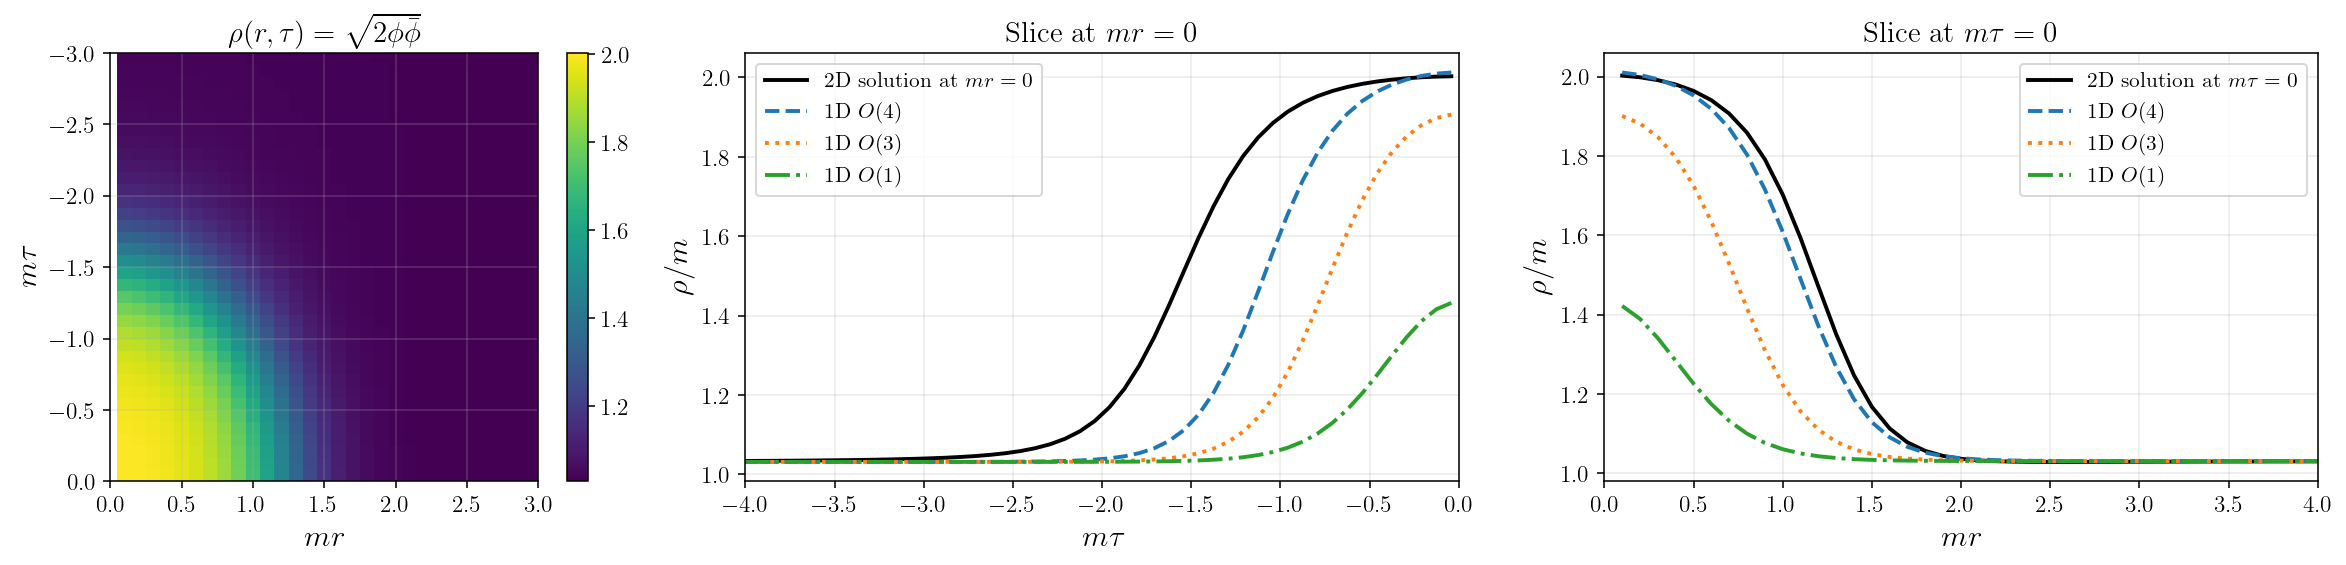

In [38]:
rho_o4_final = solver_o4.rho_map(sol_o4.y, sol_o4.ybar)
r2d = np.asarray(solver_o4.grid.r, dtype=float)
tau2d = np.asarray(solver_o4.grid.tau, dtype=float)

fig, ax = plt.subplots(1, 3, figsize=(18.0, 4.2))

im = ax[0].pcolormesh(r2d, tau2d, rho_o4_final.T, shading="auto", cmap="viridis", rasterized=True)
ax[0].set_xlabel(r"$mr$", fontsize=16)
ax[0].set_ylabel(r"$m\tau$", fontsize=16)
ax[0].set_xlim(0, 3.0)
ax[0].set_ylim(-3.0, 0)
ax[0].set_title(fr"$\rho(r,\tau)=\sqrt{{2 \phi \bar\phi}}$", fontsize=15)
ax[0].invert_yaxis()  # tau-origin at the top
ax[0].set_box_aspect(1)  # square panel
cbar0 = fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.ax.tick_params(labelsize=12)

# r=0 comparison
ax[1].plot(tau2d, rho_o4_final[0, :], color="k", label=r"2D solution at $mr=0$")
for d, style in zip((4, 3, 1), ("--", ":", "-.")):
    b = bounces_fixed["omega_ref"][d]
    ax[1].plot(tau2d, np.interp(np.abs(tau2d), b["r"], b["phi"]), style, label=rf"1D $O({d})$")
ax[1].set_xlabel(r"$m\tau$", fontsize=16)
ax[1].set_ylabel(r"$\rho/m$", fontsize=16)
ax[1].set_xlim(-4.0,0)
ax[1].set_title(r"Slice at $mr=0$", fontsize=15)
ax[1].legend(fontsize=11)

# tau=0 comparison
ax[2].plot(r2d, rho_o4_final[:, 0], color="k", label=r"2D solution at $m\tau=0$")
for d, style in zip((4, 3, 1), ("--", ":", "-.")):
    b = bounces_fixed["omega_ref"][d]
    ax[2].plot(r2d, np.interp(r2d, b["r"], b["phi"]), style, label=rf"1D $O({d})$")
ax[2].set_xlabel(r"$mr$", fontsize=16)
ax[2].set_ylabel(r"$\rho/m$", fontsize=16)
ax[2].set_xlim(0, 4.0)
ax[2].set_title(r"Slice at $m\tau=0$", fontsize=15)
ax[2].legend(fontsize=11)
for axi in ax:
    axi.tick_params(axis="both", labelsize=12)

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "o4_red_vs_1d_profiles.pdf", bbox_inches="tight")
plt.show()


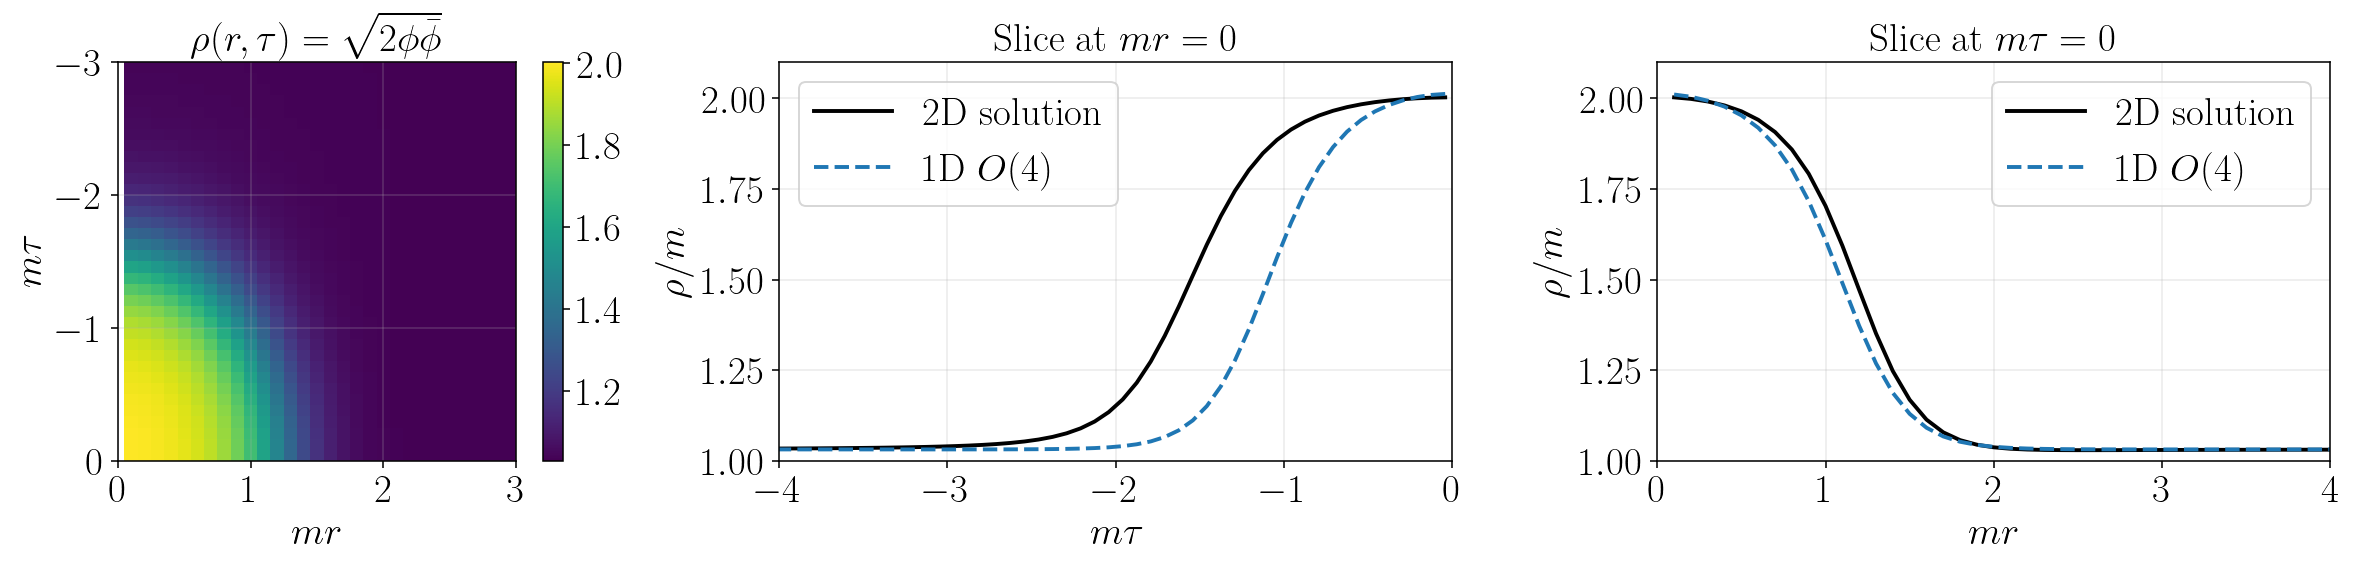

In [39]:
rho_o4_final = solver_o4.rho_map(sol_o4.y, sol_o4.ybar)
r2d = np.asarray(solver_o4.grid.r, dtype=float)
tau2d = np.asarray(solver_o4.grid.tau, dtype=float)

_FS = 20  # labels, legend, ticks (minimum 14)

fig, ax = plt.subplots(1, 3, figsize=(18.0, 4.2))

im = ax[0].pcolormesh(r2d, tau2d, rho_o4_final.T, shading="auto", cmap="viridis", rasterized=True)
ax[0].set_xlabel(r"$mr$", fontsize=_FS)
ax[0].set_ylabel(r"$m\tau$", fontsize=_FS)
ax[0].set_xlim(0, 3.0)
ax[0].set_ylim(-3.0, 0)
ax[0].set_title(fr"$\rho(r,\tau)=\sqrt{{2 \phi \bar\phi}}$", fontsize=_FS)
ax[0].invert_yaxis()  # tau-origin at the top
ax[0].set_box_aspect(1)  # square panel
cbar0 = fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.ax.tick_params(labelsize=_FS)

# r=0 comparison (1D O(4) seed only; no O(3), O(1))
ax[1].plot(tau2d, rho_o4_final[0, :], color="k", label=r"2D solution")
b4 = bounces_fixed["omega_ref"][4]
ax[1].plot(tau2d, np.interp(np.abs(tau2d), b4["r"], b4["phi"]), "--", label=r"1D $O(4)$")
ax[1].set_xlabel(r"$m\tau$", fontsize=_FS)
ax[1].set_ylabel(r"$\rho/m$", fontsize=_FS)
ax[1].set_xlim(-4.0, 0)
ax[1].set_ylim(1, 2.1)
ax[1].set_title(r"Slice at $mr=0$", fontsize=_FS)
ax[1].legend(fontsize=_FS)

# tau=0 comparison (1D O(4) seed only; no O(3), O(1))
ax[2].plot(r2d, rho_o4_final[:, 0], color="k", label=r"2D solution")
ax[2].plot(r2d, np.interp(r2d, b4["r"], b4["phi"]), "--", label=r"1D $O(4)$")
ax[2].set_xlabel(r"$mr$", fontsize=_FS)
ax[2].set_ylabel(r"$\rho/m$", fontsize=_FS)
ax[2].set_xlim(0, 4.0)
ax[2].set_ylim(1, 2.1)
ax[2].set_title(r"Slice at $m\tau=0$", fontsize=_FS)
ax[2].legend(fontsize=_FS)
for axi in ax:
    axi.tick_params(axis="both", labelsize=_FS)

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "o4_red_vs_1d_o4_only_profiles.pdf", bbox_inches="tight")
plt.show()


### 11.1 Hyperbolic rapidity $\alpha$ alongside $\rho(r,\tau)$

On the same half-box grid as the previous figure, we plot the physical modulus and the hyperbolic rapidity built from the rotated fields $(\varphi,\bar\varphi)$.

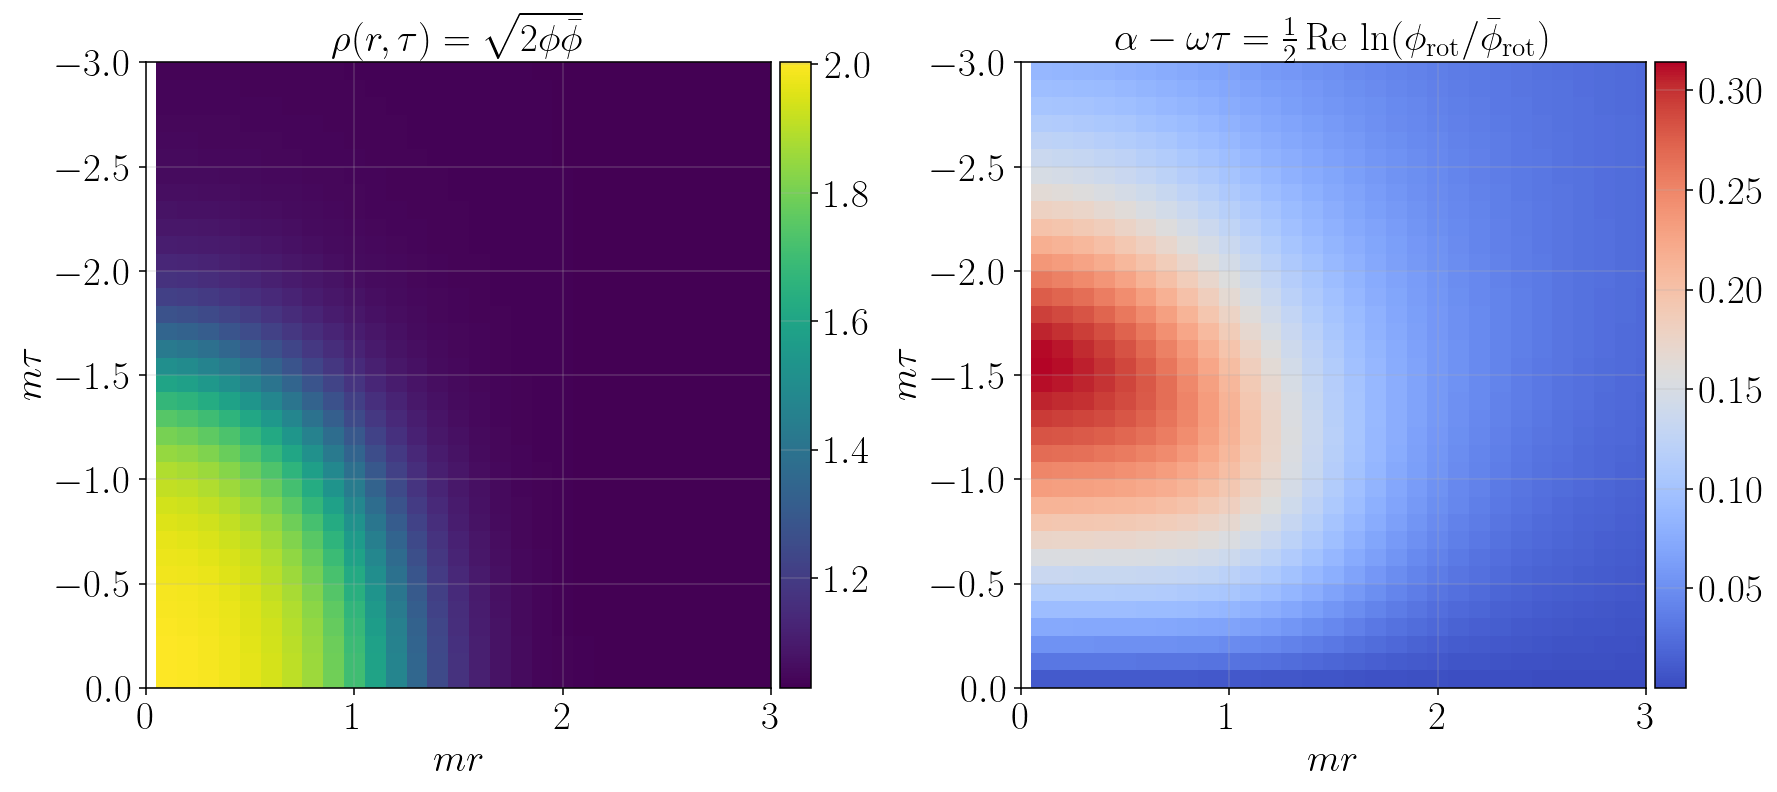

In [40]:
# rho(r,tau) and hyperbolic rapidity alpha on the same half-box grid as the previous figure.
#
# We reuse solver_o4.phi_rot(y,ybar) -> (phi_rot, phibar_rot), i.e. the same reduced fields that enter
# rho_map via u = Re(phi_rot * phibar_rot). The hyperbolic rapidity is
#   alpha = (1/2) Re log(phi_rot / phibar_rot),
# which reduces to (1/2) log(|phi_rot|/|phibar_rot|) along a real bounce branch.

import numpy as np
import matplotlib.pyplot as plt

rho_o4_mesh = solver_o4.rho_map(sol_o4.y, sol_o4.ybar)
r2d = np.asarray(solver_o4.grid.r, dtype=float)
tau2d = np.asarray(solver_o4.grid.tau, dtype=float)

phi_rot, phibar_rot = solver_o4.phi_rot(sol_o4.y, sol_o4.ybar)

_tol = 1e-30
mask = np.abs(phibar_rot) > _tol
alpha_c = np.full(np.shape(phi_rot), np.nan, dtype=complex)
alpha_c[mask] = 0.5 * np.log(phi_rot[mask] / phibar_rot[mask])
alpha_plot = np.real(alpha_c)

_FS = 20  # labels, legend, ticks (minimum 14)

# ImageGrid: axes_pad is the gap *between the two heatmap axes* (inches).
# cbar_pad / cbar_size control each colorbar relative to its own axes only.
from mpl_toolkits.axes_grid1 import ImageGrid

fig = plt.figure(figsize=(17.5, 5.8))
grid = ImageGrid(
    fig,
    111,
    nrows_ncols=(1, 2),
    axes_pad=1.5,
    label_mode="keep",
    cbar_mode="each",
    cbar_size="5%",
    cbar_pad=0.06,
)

ax0, ax1 = grid[0], grid[1]

im0 = ax0.pcolormesh(
    r2d, tau2d, rho_o4_mesh.T, shading="auto", cmap="viridis", rasterized=True
)
ax0.set_xlabel(r"$mr$", fontsize=_FS)
ax0.set_ylabel(r"$m\tau$", fontsize=_FS)
ax0.set_xlim(0, 3.0)
ax0.set_ylim(-3.0, 0)
ax0.set_title(fr"$\rho(r,\tau)=\sqrt{{2 \phi \bar\phi}}$", fontsize=_FS)
ax0.invert_yaxis()  # tau-origin at the top
ax0.set_box_aspect(1)  # square panel
cbar0 = grid.cbar_axes[0].colorbar(im0)
cbar0.ax.tick_params(labelsize=_FS)

im1 = ax1.pcolormesh(
    r2d, tau2d, alpha_plot.T, shading="auto", cmap="coolwarm", rasterized=True
)
ax1.set_xlabel(r"$mr$", fontsize=_FS)
ax1.set_ylabel(r"$m\tau$", fontsize=_FS)
ax1.set_xlim(0, 3.0)
ax1.set_ylim(-3.0, 0)
ax1.set_title(
    r"$\alpha-\omega \tau=\frac{1}{2}\,\mathrm{Re}\,\ln(\phi_{\mathrm{rot}}/\bar{\phi}_{\mathrm{rot}})$",
    fontsize=_FS,
)
ax1.invert_yaxis()
ax1.set_box_aspect(1)
cbar1 = grid.cbar_axes[1].colorbar(im1)
cbar1.ax.tick_params(labelsize=_FS)

for axi in (ax0, ax1):
    axi.tick_params(axis="both", labelsize=_FS)

if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_rho_and_hyperbolic_alpha_maps.pdf",
        bbox_inches="tight",
    )
plt.show()


## 12. Extended O(4) maps and beta ladder

This block visualizes the converged O(4) saddle on symmetry-extended $(r,\tau)$ domains and compares selected $\beta$ values along a short continuation ladder. The goal is to show how the modulus profile and its O(4)-like embedding change when the Euclidean time extent is reduced.

/tmp/ipykernel_156388/4283317830.py:76: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


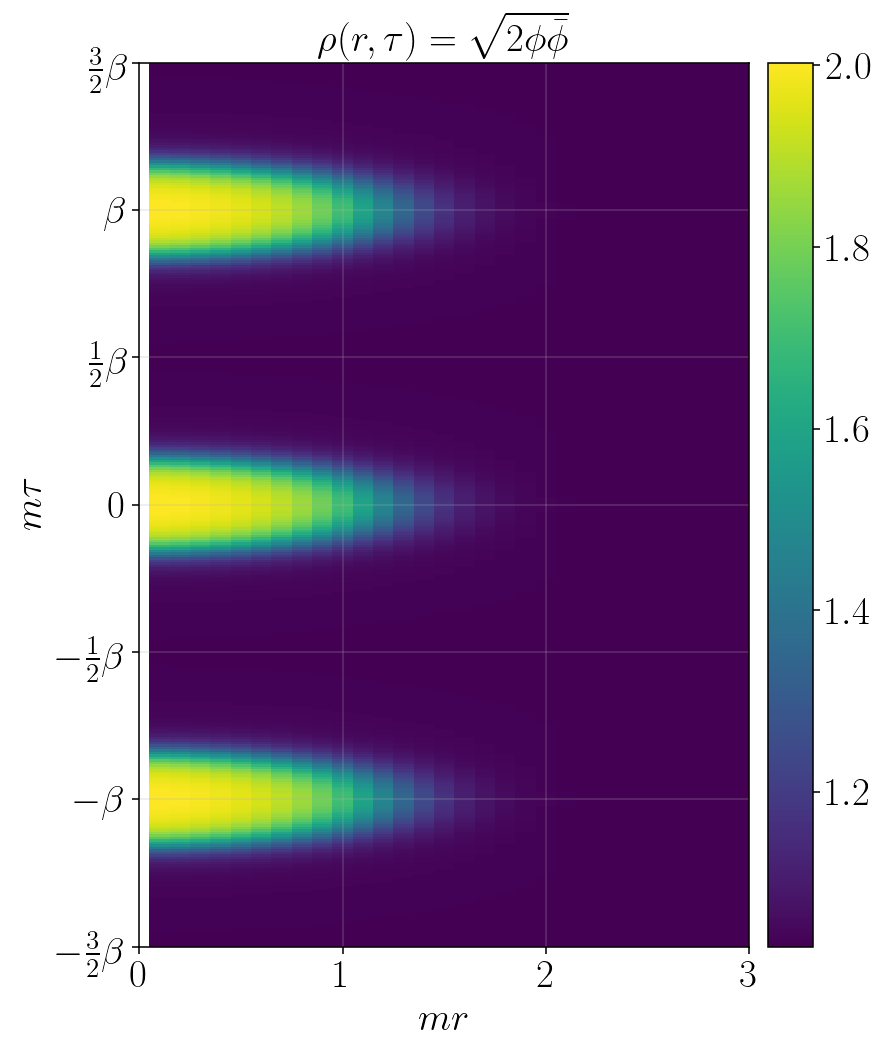

In [41]:
# rho(r,tau): reflect around tau=0 and copy up to +/- 3 beta/2

import numpy as np
import matplotlib.pyplot as plt

rho_o4_mesh = solver_o4.rho_map(sol_o4.y, sol_o4.ybar)

r = np.asarray(solver_o4.grid.r, dtype=float)
tau_half = np.asarray(solver_o4.grid.tau, dtype=float)
rho_half = np.asarray(rho_o4_mesh, dtype=float)   # expected shape: (Nr, Ntau)

# ------------------------------------------------------------
# Ensure tau is ordered increasingly: [-beta/2, ..., 0]
# ------------------------------------------------------------
order = np.argsort(tau_half)
tau_half = tau_half[order]
rho_half = rho_half[:, order]

# The half-box should be tau in [-beta/2, 0]
tau_min = tau_half[0]
tau_max = tau_half[-1]

if not np.isclose(tau_max, 0.0, rtol=0.0, atol=1e-10):
    print(f"Warning: tau grid does not end exactly at 0. tau_max = {tau_max}")

beta = 2.0 * (tau_max - tau_min)

# ------------------------------------------------------------
# Build one full period [-beta/2, beta/2] by reflection
#
# rho(tau>0) = rho(-tau)
#
# Skip tau=0 in the reflected copy to avoid duplicating it.
# ------------------------------------------------------------
tau_base = np.concatenate([
    tau_half,
    -tau_half[-2::-1],
])

rho_base = np.concatenate([
    rho_half,
    rho_half[:, -2::-1],
], axis=1)

# ------------------------------------------------------------
# Copy the full period by shifts -beta, 0, +beta
# to cover [-3 beta/2, 3 beta/2].
#
# Skip the first point of each later block to avoid duplicate
# pcolormesh coordinates at the joins.
# ------------------------------------------------------------
tau_blocks = []
rho_blocks = []

for i, k in enumerate([-1, 0, 1]):
    t_block = tau_base + k * beta
    r_block = rho_base

    if i > 0:
        t_block = t_block[1:]
        r_block = r_block[:, 1:]

    tau_blocks.append(t_block)
    rho_blocks.append(r_block)

tau_ext = np.concatenate(tau_blocks)
rho_ext = np.concatenate(rho_blocks, axis=1)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
_FS = 20

fig, ax = plt.subplots(figsize=(7.2, 8.2))

im = ax.pcolormesh(
    r,
    tau_ext,
    rho_ext.T,
    shading="auto",
    cmap="viridis",
    rasterized=True,
)

ax.set_xlabel(r"$mr$", fontsize=_FS)
ax.set_ylabel(r"$m\tau$", fontsize=_FS)

ax.set_xlim(0, 3)
ax.set_ylim(-1.5 * beta, 1.5 * beta)

ax.set_title(fr"$\rho(r,\tau)=\sqrt{{2\phi\bar\phi}}$", fontsize=_FS)

# Ticks only at multiples of beta/2
yticks = 0.5 * beta * np.arange(-3, 4)
yticklabels = [
    r"$-\frac{3}{2}\beta$",
    r"$-\beta$",
    r"$-\frac{1}{2}\beta$",
    r"$0$",
    r"$\frac{1}{2}\beta$",
    r"$\beta$",
    r"$\frac{3}{2}\beta$",
]

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

ax.tick_params(axis="both", labelsize=_FS)
ax.set_box_aspect(1.45)

cbar = fig.colorbar(im, ax=ax, pad=0.025)
cbar.ax.tick_params(labelsize=_FS)

if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_rho_reflected_three_periods.pdf",
        bbox_inches="tight",
    )

plt.show()

### 12.1 Beta continuation ladder on the O(4) branch

Selected $\beta$ values along a short ladder starting from the reference O(4) solution at $\beta=10$.

In [42]:
# ============================================================
# O(4) branch: selected beta ladder from the converged O(4) solution
#
# Reference: solver_o4 @ beta=10 (stored, not used as ansatz for the ladder).
# beta=6: fresh O4_seed rebuilt on the beta=6 grid; then 4.5 continues from beta=6.
# beta=3: fresh O(3) static seed (O3_static_seed).
# Results kept in notebook memory: o4_beta_selected_by_beta, o4_beta_selected_records.
#
# Newton output:
#   - reuses the same Newton-compact live parser used in the O(4) solve cell.
#   - first Newton solve of each eta-scan is live by default.
# ============================================================

import io
import re
import sys
from contextlib import redirect_stdout

import numpy as np
from scipy.optimize import brentq


O4_BETA_SELECTED_TARGETS = [6.0, 4.5, 3.0]
O4_BETA_O4_SEED_AT = 6.0
O4_BETA_O3_SEED_AT = 3.0

O4_BETA_NEWTON_LIVE_FIRST_SOLVE = True
O4_BETA_NEWTON_LIVE_ALL_SCAN_SOLVES = True


# ------------------------------------------------------------
# Newton compact parser.
# Reuse the one from the O(4) cell if it already exists.
# Otherwise define it here.
# ------------------------------------------------------------
if "_newton_compact_pat" not in globals():

    def _newton_compact_pat():
        return re.compile(
            r"iter=(\d+).*?\|\|F\|\|=([+\-0-9.eE]+).*?rhoQ=([+\-0-9.eE]+).*?rhoE=([+\-0-9.eE]+).*?"
            r"rho_Q/rho_Q_ref=([+\-0-9.eE]+).*?rho_E/rho_E_ref=([+\-0-9.eE]+)"
        )


if "_print_newton_compact_from_line" not in globals():

    def _print_newton_compact_from_line(line, pat=None):
        if "[Newton-explicit]" not in line:
            return

        pat = pat or _newton_compact_pat()
        m = pat.search(line)
        if m is None:
            return

        it = int(m.group(1))
        nF = float(m.group(2))
        q_val = float(m.group(3))
        e_val = float(m.group(4))
        q_ratio = float(m.group(5))
        e_ratio = float(m.group(6))

        print(
            f"[Newton-compact] iter={it:02d}  ||F||={nF:.3e}  "
            f"rho_Q={q_val:.8e}  rho_E={e_val:.8e}  "
            f"rho_Q/rho_Q*= {q_ratio:.6f}  rho_E/rho_E*= {e_ratio:.6f}",
            flush=True,
        )


if "_StdoutNewtonCompactLive" not in globals():

    class _StdoutNewtonCompactLive:
        """Parse [Newton-explicit] lines from solve() and emit [Newton-compact] immediately."""

        def __init__(self, stream):
            self._stream = stream
            self._buf = ""
            self._pat = _newton_compact_pat()

        def write(self, text):
            if not text:
                return

            self._buf += text
            while "\n" in self._buf:
                line, self._buf = self._buf.split("\n", 1)
                _print_newton_compact_from_line(line, self._pat)

        def flush(self):
            if self._buf:
                _print_newton_compact_from_line(self._buf, self._pat)
                self._buf = ""

            self._stream.flush()

        def isatty(self):
            return getattr(self._stream, "isatty", lambda: False)()


def _solve_at_eta_beta(slv, eta, x_init, *, verbose=False, newton_live=False):
    """
    Solve at fixed eta0.

    If newton_live=True:
      solve(..., verbose=True) is redirected through the compact parser,
      so every Newton iteration appears immediately as [Newton-compact].

    If verbose=True and newton_live=False:
      the full verbose output is captured and only compact Newton lines are printed after the solve.
    """

    slv.settings.eta0 = float(eta)
    slv.eta0 = float(eta)

    use_compact = bool(verbose or newton_live)

    if use_compact and newton_live:
        print(f"[Newton-compact] starting solve at eta0={float(eta):.6f}", flush=True)
        live_out = _StdoutNewtonCompactLive(sys.stdout)

        with redirect_stdout(live_out):
            sol_eta = slv.solve(
                x_init,
                verbose=True,
                verbose_success_block=False,
            )

        live_out.flush()

    elif use_compact:
        buf = io.StringIO()

        with redirect_stdout(buf):
            sol_eta = slv.solve(
                x_init,
                verbose=True,
                verbose_success_block=False,
            )

        for line in buf.getvalue().splitlines():
            _print_newton_compact_from_line(line)

    else:
        sol_eta = slv.solve(
            x_init,
            verbose=False,
            verbose_success_block=False,
        )

    q_eta = float(
        compute_charge_tau0_ghost_2d(
            slv,
            sol_eta.y,
            sol_eta.ybar,
            subtract_background=False,
        )
    )

    e_eta = float(sol_eta.E_tau0)
    r_eta = float(sol_eta.residual_norm)

    return q_eta, e_eta, r_eta, sol_eta


def _eta_scan_o4_beta_selected(
    slv,
    x_seed,
    Q_target_here,
    eta_start=0.0,
    d_eta=0.05,
    max_steps=100,
    tol_q=1e-6,
    scan_label="O4 beta-selected",
    newton_live_first=True,
    newton_live_all=False,
):
    tol_abs = float(tol_q * max(1.0, abs(Q_target_here)))
    history = []

    targets = compute_targets_tau0_ghost(
        slv,
        subtract_background_charge=False,
    )

    Q_ref = float(targets["Q"])
    E_ref = float(targets["E"])

    print("[Targets] eta0 scan references (total observables):", flush=True)
    print(f"  Q_target_total = {Q_ref:.8e}", flush=True)
    print(f"  E_target_total = {E_ref:.8e}", flush=True)

    def _print_eta_line(tag, eta, q_val, e_val):
        q_ratio = q_val / Q_ref if abs(Q_ref) > 1e-30 else np.nan
        e_ratio = e_val / E_ref if abs(E_ref) > 1e-30 else np.nan

        print(
            f"[{tag}] eta={eta:.6f}  Q_total={q_val:.8e}  E_total={e_val:.8e}  "
            f"Q_total/Q*= {q_ratio:.6f}  E_total/E*= {e_ratio:.6f}",
            flush=True,
        )

    # --------------------------------------------------------
    # First eta solve: live Newton output by default.
    # --------------------------------------------------------
    eta_curr = float(eta_start)

    q_curr, e_curr, r_curr, sol_curr = _solve_at_eta_beta(
        slv,
        eta_curr,
        x_seed,
        newton_live=bool(newton_live_first),
    )

    x_seed = np.asarray(sol_curr.x, dtype=float).copy()

    history.append(
        {
            "eta0": eta_curr,
            "Q": q_curr,
            "E": e_curr,
            "residual": r_curr,
        }
    )

    _print_eta_line(scan_label, eta_curr, q_curr, e_curr)

    if abs(q_curr - Q_target_here) <= tol_abs:
        return sol_curr, {
            "eta0": eta_curr,
            "eta_bracket_used": (eta_curr, eta_curr),
            "history": history,
        }

    # --------------------------------------------------------
    # Step scan in eta0.
    # --------------------------------------------------------
    eta_prev, q_prev = eta_curr, q_curr
    crossed = False

    for _ in range(int(max_steps)):
        eta_prev, q_prev = eta_curr, q_curr

        if q_curr < Q_target_here:
            eta_curr += d_eta
        else:
            eta_curr -= d_eta

        q_curr, e_curr, r_curr, sol_curr = _solve_at_eta_beta(
            slv,
            eta_curr,
            x_seed,
            newton_live=bool(newton_live_all),
        )

        x_seed = np.asarray(sol_curr.x, dtype=float).copy()

        history.append(
            {
                "eta0": eta_curr,
                "Q": q_curr,
                "E": e_curr,
                "residual": r_curr,
            }
        )

        _print_eta_line(scan_label, eta_curr, q_curr, e_curr)

        if (q_prev - Q_target_here) * (q_curr - Q_target_here) <= 0:
            crossed = True
            break

    if not crossed:
        raise RuntimeError(f"{scan_label}: eta scan did not bracket target charge")

    eta_lo, eta_hi = (
        (eta_prev, eta_curr)
        if eta_prev < eta_curr
        else (eta_curr, eta_prev)
    )

    state = {"x_seed": x_seed}
    cache = {}

    # --------------------------------------------------------
    # Brent refinement.
    # Usually keep Newton silent here unless newton_live_all=True.
    # --------------------------------------------------------
    def _f_eta(eta):
        key = round(float(eta), 12)

        if key in cache:
            return cache[key]["Q"] - Q_target_here

        q_val, e_val, r_val, sol_val = _solve_at_eta_beta(
            slv,
            float(eta),
            state["x_seed"],
            newton_live=bool(newton_live_all),
        )

        state["x_seed"] = np.asarray(sol_val.x, dtype=float).copy()

        cache[key] = {
            "Q": q_val,
            "E": e_val,
            "residual": r_val,
        }

        history.append(
            {
                "eta0": float(eta),
                "Q": q_val,
                "E": e_val,
                "residual": r_val,
            }
        )

        return q_val - Q_target_here

    eta_star = float(brentq(_f_eta, eta_lo, eta_hi, xtol=1e-10))

    q_star, e_star, r_star, sol_star = _solve_at_eta_beta(
        slv,
        eta_star,
        state["x_seed"],
        newton_live=bool(newton_live_all),
    )

    history.append(
        {
            "eta0": eta_star,
            "Q": q_star,
            "E": e_star,
            "residual": r_star,
        }
    )

    _print_eta_line(f"{scan_label}*", eta_star, q_star, e_star)

    return sol_star, {
        "eta0": eta_star,
        "eta_bracket_used": (eta_lo, eta_hi),
        "history": history,
    }


def _make_solver_for_beta(beta_val: float, eta0_guess: float) -> Bubble2DSolver:
    settings = Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=float(beta_val),
        omega_ref=CFG_2D["omega_ref"],
        eta0=float(eta0_guess),
        rho0=float(CFG_2D["rho0_false"]),
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=True,
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    )

    return Bubble2DSolver(settings, U, dU, d2U)


if "_resample_seed_to_solver_grid" not in globals():
    raise RuntimeError(
        "Run the eta-scan helper cell (_resample_seed_to_solver_grid) first."
    )

if "solver_o4" not in globals() or "sol_o4" not in globals():
    raise RuntimeError(
        "Run the O(4) solve cell (solver_o4, sol_o4) before this ladder."
    )

if "profiles_for_seeds" not in globals():
    raise RuntimeError("Run the 2D setup cell (profiles_for_seeds) first.")


Q_target_beta_selected = float(Q_TARGET_2D)

prev_solver = solver_o4
prev_sol = sol_o4

if "meta_o4" in globals():
    prev_eta = float(meta_o4.get("eta0", getattr(solver_o4, "eta0", 0.0)))
else:
    prev_eta = float(getattr(solver_o4, "eta0", 0.0))


o4_beta_selected_records = []
o4_beta_selected_by_beta = {}


_beta_ref = float(prev_solver.settings.beta)

_tgt0 = compute_targets_tau0_ghost(
    prev_solver,
    subtract_background_charge=False,
)

_q0 = float(
    compute_charge_tau0_ghost_2d(
        prev_solver,
        prev_sol.y,
        prev_sol.ybar,
        subtract_background=False,
    )
)

_qref0 = float(_tgt0["Q"])

o4_beta_selected_by_beta[_beta_ref] = {
    "beta": _beta_ref,
    "eta0": prev_eta,
    "Q": _q0,
    "Q_ref": _qref0,
    "Q_ratio": _q0 / _qref0 if abs(_qref0) > 1e-30 else np.nan,
    "E_tau0": float(prev_sol.E_tau0),
    "seed_mode": "reference (solver_o4)",
    "solver": prev_solver,
    "solution": prev_sol,
    "meta": meta_o4 if "meta_o4" in globals() else None,
    "status": "ok",
}

print(
    f"[O4 beta-selected] reference beta={_beta_ref:.3f}  eta0={prev_eta:+.5f}  "
    f"Q/Q_ref={o4_beta_selected_by_beta[_beta_ref]['Q_ratio']:.6f}",
    flush=True,
)


for beta_val in O4_BETA_SELECTED_TARGETS:
    beta_val = float(beta_val)

    print("\n" + "=" * 88, flush=True)
    print(f"[O4 beta-selected] solving beta={beta_val:.3f}", flush=True)

    if abs(beta_val - O4_BETA_O4_SEED_AT) < 1e-12:
        eta_guess_solver = 0.0
        eta_start_scan = 0.0
    else:
        eta_guess_solver = float(prev_eta)
        eta_start_scan = float(prev_eta)

    solver_new = _make_solver_for_beta(beta_val, eta_guess_solver)

    if abs(beta_val - O4_BETA_O3_SEED_AT) < 1e-12:
        x_seed_new, _rho_seed_o3 = build_seed(
            solver_new,
            "O3_static_seed",
            profiles_for_seeds,
        )
        seed_mode = "O3_static_seed (fresh O(3))"

    elif abs(beta_val - O4_BETA_O4_SEED_AT) < 1e-12:
        x_seed_new, _rho_seed_o4 = build_seed(
            solver_new,
            "O4_seed",
            profiles_for_seeds,
        )
        seed_mode = "O4_seed (rebuilt at beta=6)"

    else:
        x_prev = np.asarray(prev_sol.x, dtype=float).copy()

        if x_prev.size == solver_new._zero_vec().size:
            x_seed_new = x_prev
            seed_mode = "continuation prev_sol.x"
        else:
            x_seed_new = _resample_seed_to_solver_grid(
                prev_solver,
                solver_new,
                x_prev,
            )
            seed_mode = "resampled prev_sol.x"

    seed_res = float(
        np.linalg.norm(
            solver_new.residual(
                np.asarray(x_seed_new, dtype=float)
            )
        )
    )

    print(f"[O4 beta-selected] beta={beta_val:.3f}: {seed_mode}", flush=True)
    print(f"[O4 beta-selected] beta={beta_val:.3f}: seed residual = {seed_res:.6e}", flush=True)

    try:
        sol_new, meta_new = _eta_scan_o4_beta_selected(
            solver_new,
            x_seed_new,
            Q_target_here=Q_target_beta_selected,
            eta_start=float(eta_start_scan),
            d_eta=0.05,
            max_steps=100,
            tol_q=1e-6,
            scan_label=f"O4 beta-selected @ beta={beta_val:.1f}",
            newton_live_first=O4_BETA_NEWTON_LIVE_FIRST_SOLVE,
            newton_live_all=O4_BETA_NEWTON_LIVE_ALL_SCAN_SOLVES,
        )

        eta_star = float(meta_new.get("eta0", np.nan))

        solver_new.settings.eta0 = eta_star
        solver_new.eta0 = eta_star

        tgt = compute_targets_tau0_ghost(
            solver_new,
            subtract_background_charge=False,
        )

        q_val = float(
            compute_charge_tau0_ghost_2d(
                solver_new,
                sol_new.y,
                sol_new.ybar,
                subtract_background=False,
            )
        )

        q_ref = float(tgt["Q"])

        rec = {
            "beta": beta_val,
            "eta0": eta_star,
            "Q": q_val,
            "Q_ref": q_ref,
            "Q_ratio": q_val / q_ref if abs(q_ref) > 1e-30 else np.nan,
            "E_tau0": float(sol_new.E_tau0),
            "seed_mode": seed_mode,
            "solver": solver_new,
            "solution": sol_new,
            "meta": meta_new,
            "status": "ok",
        }

        o4_beta_selected_records.append(rec)
        o4_beta_selected_by_beta[beta_val] = rec

        print(
            f"[O4 beta-selected] beta={beta_val:.3f}  eta0={eta_star:+.5f}  "
            f"Q/Q_ref={rec['Q_ratio']:.6f}  ||F||={sol_new.residual_norm:.6e}",
            flush=True,
        )

        prev_solver = solver_new
        prev_sol = sol_new
        prev_eta = eta_star

    except Exception as exc:
        msg = f"{type(exc).__name__}: {exc}"

        print(f"[O4 beta-selected] beta={beta_val:.3f} FAILED -> {msg}", flush=True)

        rec = {
            "beta": beta_val,
            "eta0": np.nan,
            "Q": np.nan,
            "Q_ref": np.nan,
            "Q_ratio": np.nan,
            "E_tau0": np.nan,
            "seed_mode": seed_mode,
            "solver": solver_new,
            "solution": None,
            "meta": None,
            "status": "failed",
            "error": msg,
        }

        o4_beta_selected_records.append(rec)
        o4_beta_selected_by_beta[beta_val] = rec


print("\n=== O(4) beta-selected ladder (in-memory) ===", flush=True)
print("o4_beta_selected_by_beta   -> dict beta -> record (solver, solution, ...)", flush=True)
print("o4_beta_selected_records   -> list of solved betas", flush=True)

for b in sorted(o4_beta_selected_by_beta.keys(), reverse=True):
    rec = o4_beta_selected_by_beta[b]

    print(
        f"  beta={b:5.1f}  status={rec.get('status', '?')}  seed={rec.get('seed_mode', '?')}",
        flush=True,
    )


[O4 beta-selected] reference beta=10.000  eta0=-0.03309  Q/Q_ref=1.000000

[O4 beta-selected] solving beta=6.000
[O4 beta-selected] beta=6.000: O4_seed (rebuilt at beta=6)
[O4 beta-selected] beta=6.000: seed residual = 1.263614e+01
[Targets] eta0 scan references (total observables):
  Q_target_total = 9.14010702e+02
  E_target_total = 3.71899095e+00
[Newton-compact] starting solve at eta0=0.000000
[O4 beta-selected @ beta=6.0] eta=0.000000  Q_total=9.19895998e+02  E_total=-1.93775436e+00  Q_total/Q*= 1.006439  E_total/E*= -0.521043
[Newton-compact] starting solve at eta0=-0.050000
[O4 beta-selected @ beta=6.0] eta=-0.050000  Q_total=9.10727102e+02  E_total=6.77967018e+00  Q_total/Q*= 0.996407  E_total/E*= 1.822986
[Newton-compact] starting solve at eta0=-0.050000
[Newton-compact] starting solve at eta0=0.000000
[Newton-compact] starting solve at eta0=-0.032094
[Newton-compact] starting solve at eta0=-0.032059
[Newton-compact] starting solve at eta0=-0.032059
[Newton-compact] starting s

### 12.2 Side-by-side $\rho$ maps at selected $\beta$

Three $\beta$-selected modulus maps on a symmetry-extended domain, using a white-to-blue colormap normalized by the false-vacuum modulus.

[rho plateaux] rho_in=2.06565910e+00, rho_out=1.03120180e+00  (2D vacua direct: |phi_true_2d|, |phi_false_2d|)
[rho plateaux] rho map global range=[1.02938451e+00, 2.00178603e+00]
[rho contours] fractions=[0.1  0.25 0.5  0.78]
[rho contours] requested levels=[1.13464753 1.28981613 1.54843045 1.83807849]
[rho colormap] continuous RdBu half-map: rho_min=1.02938451e+00, rho_max=2.00178603e+00


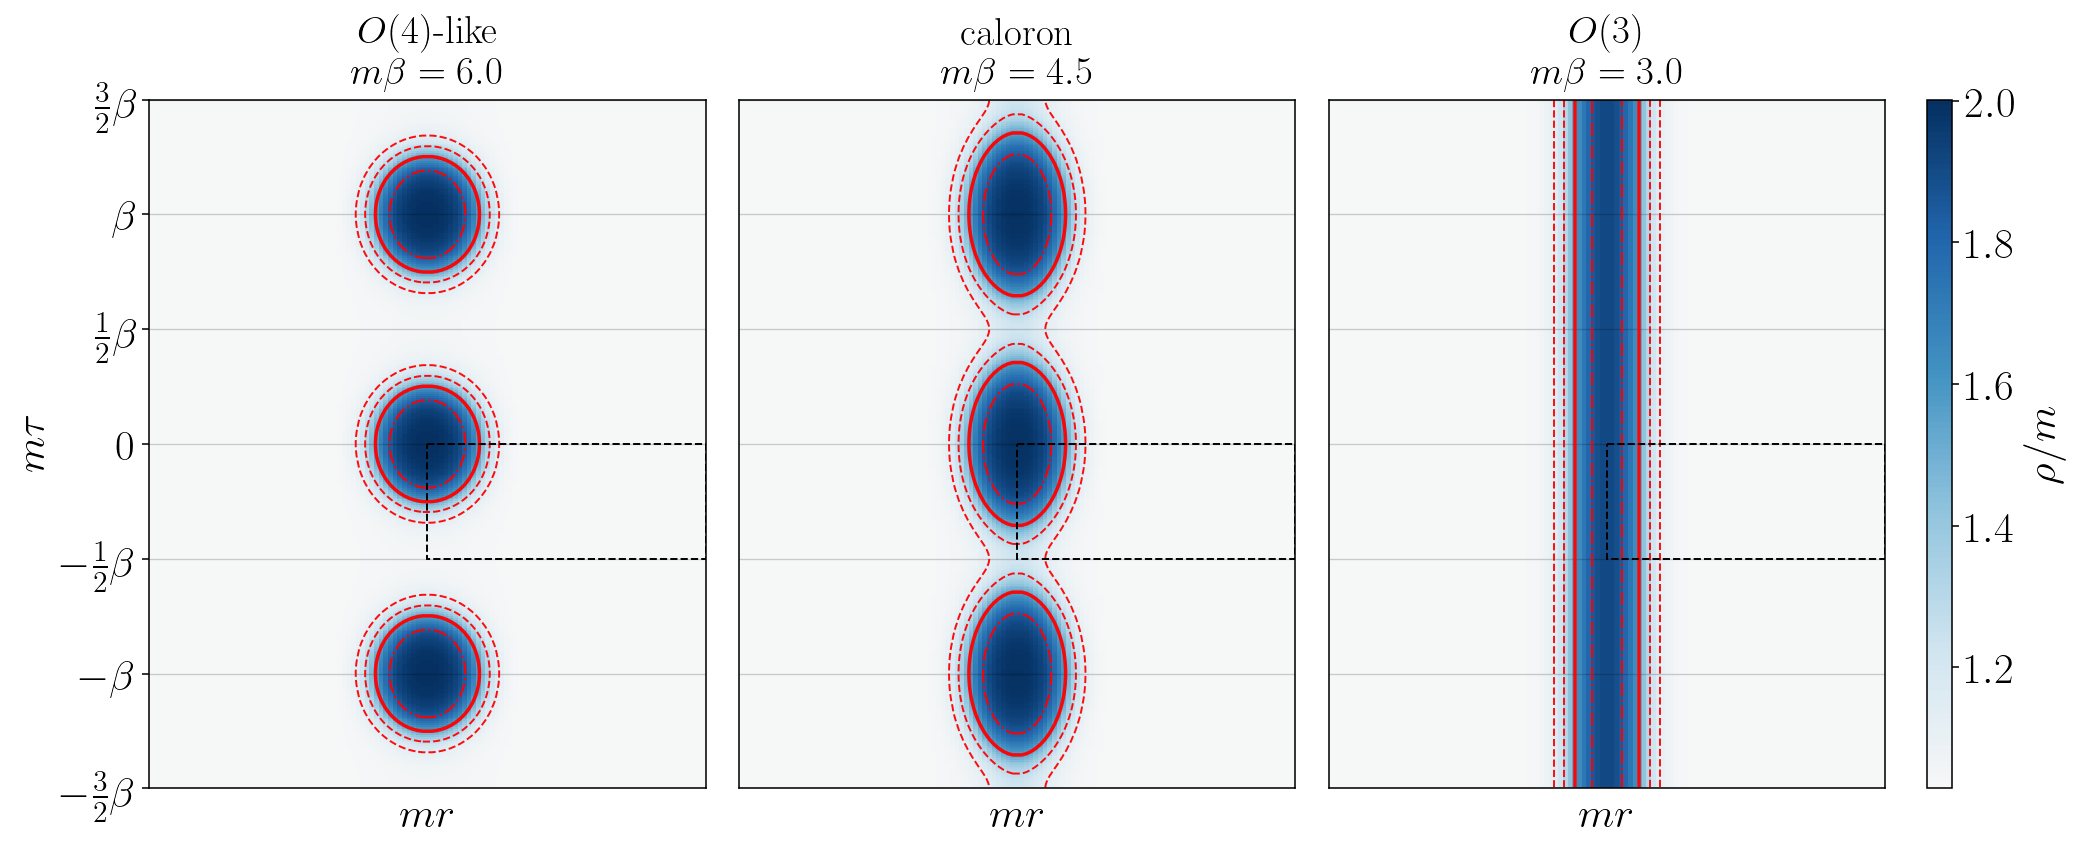

In [43]:
# ============================================================
# Three beta-selected rho maps side by side.
#
# Reflect around tau=0 and copy up to +/- 3 beta/2.
# Optional mirror in r -> -r.
#
# Colormap:
#   use the white -> blue half of RdBu,
#   continuously normalized from rho_all_min to rho_all_max.
#   No under-color, no extend, no discontinuity.
#
# Contours:
#   field contours rho(r,tau)=const.
#   They are not geometrical radius contours.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Rectangle


# ------------------------------------------------------------
# Choose which beta solutions to plot
# ------------------------------------------------------------
BETAS_TO_PLOT = [6.0, 4.5, 3.0]

# Plot layout / symmetries
REFLECT_R_ABOUT_ZERO = True

PANEL_WIDTH_IN = 6
PANEL_HEIGHT_IN = 6
PANEL_BOX_ASPECT = None
FIG_WSPACE = 0.06
CBAR_SHRINK = 1.0

XLIM_R_REFLECTED = (-6.0, 6.0)
XLIM_R_POSITIVE = (0.0, 2.0)

# Field contours as fractions between rho_out and rho_in.
# Fractions < 0.5 are outside-wall contours; 0.5 is the wall; > 0.5 is inside.
CONTOUR_FRACTIONS = np.array([0.10, 0.25, 0.50, 0.78], dtype=float)

CONTOUR_COLOR = "red"
CONTOUR_ALPHA = 0.95

_FS = 22


# ------------------------------------------------------------
# Small utilities
# ------------------------------------------------------------
def _as_float_or_none(x):
    try:
        y = float(x)
        if np.isfinite(y):
            return y
    except Exception:
        pass
    return None


def _centers_to_edges(x):
    """
    Convert strictly increasing cell centers to edges.
    This removes the pcolormesh warning and avoids fake jumps.
    """
    x = np.asarray(x, dtype=float)

    if x.ndim != 1:
        raise RuntimeError("Expected a 1D coordinate array.")

    if x.size == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5], dtype=float)

    dx = np.diff(x)

    if not np.all(dx > 0):
        raise RuntimeError(
            "Coordinate array is not strictly increasing. "
            f"min(diff)={np.min(dx):.6e}, max(diff)={np.max(dx):.6e}"
        )

    edges = np.empty(x.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * dx[0]
    edges[-1] = x[-1] + 0.5 * dx[-1]

    return edges


def _unique_sorted_columns(tau_raw, rho_raw, *, tol=1e-12):
    """
    Sort tau and remove duplicated columns.
    Duplicates may appear when copying periods.
    """
    tau_raw = np.asarray(tau_raw, dtype=float)
    rho_raw = np.asarray(rho_raw, dtype=float)

    order = np.argsort(tau_raw)
    tau = tau_raw[order]
    rho = rho_raw[:, order]

    if tau.size <= 1:
        return tau, rho

    scale = max(1.0, float(np.nanmax(np.abs(tau))))
    atol = tol * scale

    keep = np.ones(tau.size, dtype=bool)
    keep[1:] = np.abs(np.diff(tau)) > atol

    return tau[keep], rho[:, keep]


def _get_beta_from_record(slv, rec, tau_half):
    """
    Prefer beta stored in the record / solver settings.
    Only infer beta from tau if needed.
    """
    beta = _as_float_or_none(rec.get("beta", None))
    if beta is not None:
        return beta

    for attr in ["settings", "cfg", "config"]:
        obj = getattr(slv, attr, None)
        if obj is None:
            continue

        if hasattr(obj, "beta"):
            beta = _as_float_or_none(getattr(obj, "beta"))
            if beta is not None:
                return beta

        if isinstance(obj, dict) and "beta" in obj:
            beta = _as_float_or_none(obj["beta"])
            if beta is not None:
                return beta

    tau_half = np.asarray(tau_half, dtype=float)
    tau_half = np.sort(tau_half)

    if tau_half.size >= 2:
        dt = float(np.median(np.diff(tau_half)))

        # Cell-centered half-grid: [-beta/2,0), so tau_max is around -dt/2.
        if tau_half[-1] < 0.0:
            return 2.0 * tau_half.size * dt

        # Endpoint grid: [-beta/2,0].
        return 2.0 * (tau_half[-1] - tau_half[0])

    raise RuntimeError("Could not infer beta from the record or tau grid.")


# ------------------------------------------------------------
# Build reflected / copied rho map
# ------------------------------------------------------------
def _rho_reflected_three_periods(slv, sol, rec, *, reflect_r=False):
    rho_mesh = np.asarray(slv.rho_map(sol.y, sol.ybar), dtype=float)

    r = np.asarray(slv.grid.r, dtype=float)
    tau_half = np.asarray(slv.grid.tau, dtype=float)

    if rho_mesh.shape != (r.size, tau_half.size):
        raise RuntimeError(
            f"Unexpected rho shape: rho_mesh.shape={rho_mesh.shape}, "
            f"expected {(r.size, tau_half.size)}"
        )

    order = np.argsort(tau_half)
    tau_half = tau_half[order]
    rho_half = rho_mesh[:, order]

    beta = float(_get_beta_from_record(slv, rec, tau_half))

    tau_end = float(tau_half[-1])
    tau_scale = max(1.0, beta)
    tau_has_zero = np.isclose(tau_end, 0.0, rtol=0.0, atol=1e-10 * tau_scale)

    if tau_has_zero:
        # Endpoint grid: avoid duplicating tau=0.
        tau_base = np.concatenate([tau_half, -tau_half[-2::-1]])
        rho_base = np.concatenate([rho_half, rho_half[:, -2::-1]], axis=1)
    else:
        # Cell-centered grid: reflect all centers.
        tau_base = np.concatenate([tau_half, -tau_half[::-1]])
        rho_base = np.concatenate([rho_half, rho_half[:, ::-1]], axis=1)

    tau_blocks = []
    rho_blocks = []

    for k in [-1, 0, 1]:
        tau_blocks.append(tau_base + k * beta)
        rho_blocks.append(rho_base)

    tau_ext_raw = np.concatenate(tau_blocks)
    rho_ext_raw = np.concatenate(rho_blocks, axis=1)

    tau_ext, rho_ext = _unique_sorted_columns(tau_ext_raw, rho_ext_raw)

    if reflect_r:
        r_pos = np.asarray(r, dtype=float)
        rho_pos = np.asarray(rho_ext, dtype=float)

        if r_pos.size >= 2:
            # Exclude r=0 from the mirrored copy.
            if np.isclose(r_pos[0], 0.0, rtol=0.0, atol=1e-14):
                r_neg = -r_pos[:0:-1]
                rho_neg = rho_pos[:0:-1, :]
            else:
                r_neg = -r_pos[::-1]
                rho_neg = rho_pos[::-1, :]

            r = np.concatenate([r_neg, r_pos])
            rho_ext = np.concatenate([rho_neg, rho_pos], axis=0)
        else:
            print("Warning: reflect_r skipped because Nr < 2.")

    if not np.all(np.diff(r) > 0):
        raise RuntimeError(
            "Reflected r grid is not strictly increasing. "
            f"min(diff r)={np.min(np.diff(r)):.6e}"
        )

    if not np.all(np.diff(tau_ext) > 0):
        raise RuntimeError(
            "Extended tau grid is not strictly increasing. "
            f"min(diff tau)={np.min(np.diff(tau_ext)):.6e}"
        )

    return r, tau_ext, rho_ext, beta


# ------------------------------------------------------------
# Collect successful records
# ------------------------------------------------------------
if "o4_beta_selected_by_beta" not in globals():
    raise RuntimeError("o4_beta_selected_by_beta not found. Run the beta ladder first.")

records = []
betas_missing = []


def _beta_record(by_beta, beta_target):
    b = float(beta_target)

    if b in by_beta:
        return by_beta[b]

    for k, rec in by_beta.items():
        if abs(float(k) - b) < 1e-9:
            return rec

    return None


for b in BETAS_TO_PLOT:
    rec = _beta_record(o4_beta_selected_by_beta, b)

    if rec is None:
        betas_missing.append(float(b))
        continue

    if rec.get("status", "ok") != "ok" or rec.get("solution", None) is None:
        print(f"Skipping beta={float(b):g}: status={rec.get('status')}")
        continue

    records.append(rec)

if betas_missing:
    print(f"Missing beta entries: {betas_missing}")

if len(records) == 0:
    raise RuntimeError("No valid beta-selected solutions found to plot.")


# ------------------------------------------------------------
# Build all maps first
# ------------------------------------------------------------
plot_data = []

for rec in records:
    slv = rec["solver"]
    sol = rec["solution"]

    r, tau_ext, rho_ext, beta_from_grid = _rho_reflected_three_periods(
        slv,
        sol,
        rec,
        reflect_r=REFLECT_R_ABOUT_ZERO,
    )

    plot_data.append(
        {
            "beta": float(rec.get("beta", beta_from_grid)),
            "beta_grid": float(beta_from_grid),
            "eta0": float(rec.get("eta0", np.nan)),
            "r": r,
            "tau_ext": tau_ext,
            "rho_ext": rho_ext,
            "Q_ratio": float(rec.get("Q_ratio", np.nan)),
        }
    )

rho_all_min = min(float(np.nanmin(d["rho_ext"])) for d in plot_data)
rho_all_max = max(float(np.nanmax(d["rho_ext"])) for d in plot_data)
rho_all_span = max(rho_all_max - rho_all_min, 1e-12)


# ------------------------------------------------------------
# Robust rho_in / rho_out
# ------------------------------------------------------------
def _estimate_plateaux_from_maps(plot_data):
    """
    Fallback estimate:
      rho_out = median at large |r|,
      rho_in  = high percentile of rho.
    This is only for plotting contours.
    """
    outer_vals = []
    all_vals = []

    for d in plot_data:
        r = np.asarray(d["r"], dtype=float)
        rho = np.asarray(d["rho_ext"], dtype=float)

        rr = np.abs(r)
        rmax = float(np.nanmax(rr))
        mask_outer = rr > 0.85 * rmax

        if np.any(mask_outer):
            outer_vals.append(rho[mask_outer, :].ravel())

        all_vals.append(rho.ravel())

    all_vals = np.concatenate(all_vals)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(outer_vals) > 0:
        outer_vals = np.concatenate(outer_vals)
        outer_vals = outer_vals[np.isfinite(outer_vals)]
        rho_out = float(np.nanmedian(outer_vals))
    else:
        rho_out = float(np.nanpercentile(all_vals, 1.0))

    rho_in = float(np.nanpercentile(all_vals, 99.5))

    if rho_in < rho_out:
        rho_in, rho_out = rho_out, rho_in

    return rho_in, rho_out, "fallback from plotted maps: high percentile / large-|r| plateau"


def _candidate_is_usable(rho_in, rho_out, *, zmin, zmax):
    rho_in = _as_float_or_none(rho_in)
    rho_out = _as_float_or_none(rho_out)

    if rho_in is None or rho_out is None:
        return False

    if rho_in < rho_out:
        rho_in, rho_out = rho_out, rho_in

    margin = 0.15 * max(zmax - zmin, 1e-12)

    return (
        rho_out >= zmin - margin
        and rho_out <= zmax + margin
        and rho_in >= zmin - margin
        and rho_in <= zmax + margin
    )


def _get_rho_in_out_robust(plot_data):
    """
    Try notebook/global definitions, but reject candidates incompatible
    with the actual plotted rho range. This avoids phi/rho convention mistakes.
    """
    candidates = []

    if "rho_in" in globals() and "rho_out" in globals():
        candidates.append(
            (
                float(globals()["rho_in"]),
                float(globals()["rho_out"]),
                "globals: rho_in, rho_out",
            )
        )

    if "rho_true" in globals() and "rho_false" in globals():
        candidates.append(
            (
                float(globals()["rho_true"]),
                float(globals()["rho_false"]),
                "globals: rho_true, rho_false",
            )
        )

    if "phi_true_2d" in globals() and "phi_false_2d" in globals():
        candidates.append(
            (
                abs(float(phi_true_2d)),
                abs(float(phi_false_2d)),
                "2D vacua direct: |phi_true_2d|, |phi_false_2d|",
            )
        )

        candidates.append(
            (
                float(np.sqrt(2.0) * abs(float(phi_true_2d))),
                float(np.sqrt(2.0) * abs(float(phi_false_2d))),
                "2D vacua sqrt(2)*|phi|",
            )
        )

    if "CFG_2D" in globals():
        for kin, kout in [
            ("rho_in", "rho_out"),
            ("rho_true", "rho_false"),
            ("rho0_true", "rho0_false"),
        ]:
            if kin in CFG_2D and kout in CFG_2D:
                candidates.append(
                    (
                        float(CFG_2D[kin]),
                        float(CFG_2D[kout]),
                        f"CFG_2D: {kin}, {kout}",
                    )
                )

    for rin, rout, source in candidates:
        if _candidate_is_usable(rin, rout, zmin=rho_all_min, zmax=rho_all_max):
            rin = float(rin)
            rout = float(rout)

            if rin < rout:
                rin, rout = rout, rin

            return rin, rout, source

        print(
            f"[rho plateaux] rejected {source}: "
            f"rho_in={rin:.6g}, rho_out={rout:.6g}, "
            f"map range=[{rho_all_min:.6g}, {rho_all_max:.6g}]"
        )

    return _estimate_plateaux_from_maps(plot_data)


rho_in_val, rho_out_val, rho_source = _get_rho_in_out_robust(plot_data)

if rho_in_val < rho_out_val:
    rho_in_val, rho_out_val = rho_out_val, rho_in_val

rho_width = max(rho_in_val - rho_out_val, 1e-12)

contour_levels_requested = rho_out_val + CONTOUR_FRACTIONS * rho_width

print(f"[rho plateaux] rho_in={rho_in_val:.8e}, rho_out={rho_out_val:.8e}  ({rho_source})")
print(f"[rho plateaux] rho map global range=[{rho_all_min:.8e}, {rho_all_max:.8e}]")
print(f"[rho contours] fractions={CONTOUR_FRACTIONS}")
print(f"[rho contours] requested levels={contour_levels_requested}")


# ------------------------------------------------------------
# RdBu colormap: continuous from the true minimum to the maximum
# ------------------------------------------------------------
base_cmap = plt.get_cmap("RdBu")

# White -> blue half of RdBu.
# 0.5 is the white center of RdBu, 1.0 is the blue end.
cmap_rho = LinearSegmentedColormap.from_list(
    "continuous_white_blue_from_RdBu",
    base_cmap(np.linspace(0.5, 1.0, 256)),
)

# Important:
#   vmin is the actual global minimum of the plotted data,
#   not rho_out_val. Therefore no value is mapped to an under-color.
#   This avoids the sharp white/colored discontinuity.
COLOR_VMIN = rho_all_min
COLOR_VMAX = rho_all_max

norm = Normalize(
    vmin=COLOR_VMIN,
    vmax=COLOR_VMAX,
    clip=True,
)

print(
    f"[rho colormap] continuous RdBu half-map: "
    f"rho_min={COLOR_VMIN:.8e}, rho_max={COLOR_VMAX:.8e}"
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
ncols = len(plot_data)

fig, axes = plt.subplots(
    1,
    ncols,
    figsize=(PANEL_WIDTH_IN * ncols, PANEL_HEIGHT_IN),
)

if ncols == 1:
    axes = [axes]

fig.subplots_adjust(
    wspace=FIG_WSPACE,
    left=0.07,
    right=0.90,
    top=0.92,
    bottom=0.10,
)

last_im = None
xlim_r = XLIM_R_REFLECTED if REFLECT_R_ABOUT_ZERO else XLIM_R_POSITIVE

BETA_REF_FOR_LINES = float(BETAS_TO_PLOT[0])  # here: 6.0

yticks_ref = 0.5 * BETA_REF_FOR_LINES * np.arange(-3, 4)
yticklabels_ref = [
    r"$-\frac{3}{2}\beta$",
    r"$-\beta$",
    r"$-\frac{1}{2}\beta$",
    r"$0$",
    r"$\frac{1}{2}\beta$",
    r"$\beta$",
    r"$\frac{3}{2}\beta$",
]

for i_ax, (ax, d) in enumerate(zip(axes, plot_data)):
    beta = float(d["beta_grid"])
    r = np.asarray(d["r"], dtype=float)
    tau_ext = np.asarray(d["tau_ext"], dtype=float)
    rho_ext = np.asarray(d["rho_ext"], dtype=float)

    r_edges = _centers_to_edges(r)
    tau_edges = _centers_to_edges(tau_ext)

    last_im = ax.pcolormesh(
        r_edges,
        tau_edges,
        rho_ext.T,
        shading="auto",
        cmap=cmap_rho,
        norm=norm,
        rasterized=True,
    )

    # Filter contour levels panel by panel.
    zmin = float(np.nanmin(rho_ext))
    zmax = float(np.nanmax(rho_ext))
    eps = 1e-8 * max(abs(zmax - zmin), 1.0)

    levels_here = np.array(
        [
            float(lv)
            for lv in contour_levels_requested
            if zmin + eps < float(lv) < zmax - eps
        ],
        dtype=float,
    )

    if levels_here.size > 0:
        wall_level = rho_out_val + 0.50 * rho_width
        i_wall = int(np.argmin(np.abs(levels_here - wall_level)))

        lws = []
        lss = []

        for j, lv in enumerate(levels_here):
            frac = (float(lv) - rho_out_val) / rho_width

            if j == i_wall:
                lws.append(1.8)
                lss.append("-")
            elif frac < 0.5:
                lws.append(1.0)
                lss.append("--")
            else:
                lws.append(1.1)
                lss.append("-.")

        ax.contour(
            r,
            tau_ext,
            rho_ext.T,
            levels=levels_here,
            colors=CONTOUR_COLOR,
            linewidths=lws,
            linestyles=lss,
            alpha=CONTOUR_ALPHA,
        )

        # --------------------------------------------------------
        # Thin dashed rectangle: corners (0,0) and (r_max, beta/2)
        # --------------------------------------------------------
        if REFLECT_R_ABOUT_ZERO:
           r_max_rect = float(np.max(r[r >= 0.0]))
        else:
            r_max_rect = float(np.max(r))

        rect = Rectangle(
            (0.0, 0.0),              # lower-left corner
            r_max_rect,              # width
            -0.5 * beta,              # height
            fill=False,
            edgecolor="black",
            linewidth=1.0,
            linestyle="--",
            zorder=10,
        )
        ax.add_patch(rect)
    else:
        print(
            f"[rho contours] m beta={d['beta']:.3g}: no requested contour level "
            f"inside rho range [{zmin:.6g}, {zmax:.6g}]"
        )

    ax.set_xlabel(r"$mr$", fontsize=_FS)
    ax.set_xlim(*xlim_r)
    ax.set_ylim(-1.5 * beta, 1.5 * beta)

    phase_titles = [
        r"$O(4)$-like",
        r"caloron",
        r"$O(3)$",
    ]

    beta_titles = [
        fr"$m\beta={d['beta']:.1f}$",
        fr"$m\beta={d['beta']:.1f}$",
        fr"$m\beta={d['beta']:.1f}$",
    ]

    ax.set_title(
        phase_titles[i_ax] + "\n" + beta_titles[i_ax],
        fontsize=20,
        pad=8,
    )

    # --------------------------------------------------------
    # Horizontal guide lines at the local beta fractions.
    # This keeps the same visual alignment as before:
    # each panel has lines at -3β/2, -β, -β/2, 0, β/2, β, 3β/2
    # using its own beta.
    # --------------------------------------------------------
    yticks = 0.5 * beta * np.arange(-3, 4)

    yticklabels = [
        r"$-\frac{3}{2}\beta$",
        r"$-\beta$",
        r"$-\frac{1}{2}\beta$",
        r"$0$",
        r"$\frac{1}{2}\beta$",
        r"$\beta$",
        r"$\frac{3}{2}\beta$",
    ]

    ax.set_yticks(yticks)

    # Draw the same horizontal guide lines in all panels.
    # Do not remove yticks in the other panels, otherwise the grid disappears.
    ax.grid(
        axis="y",
        color="black",
        alpha=0.18,
        linewidth=0.7,
        linestyle="-",
        zorder=3,
    )

    if i_ax == 0:
        ax.set_ylabel(r"$m\tau$", fontsize=_FS)
        ax.set_yticklabels(yticklabels)
        ax.tick_params(axis="y", labelsize=_FS)
        ax.set_xticks([])
        ax.set_xticklabels([])
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.tick_params(axis="y", left=False, labelleft=False)


# Important: no extend="min".
# The colorbar is continuous down to rho_all_min.
cbar = fig.colorbar(
    last_im,
    ax=axes,
    pad=0.02,
    shrink=CBAR_SHRINK,
    aspect=28,
)

cbar.set_label(r"$\rho/m$", fontsize=_FS)
cbar.ax.tick_params(labelsize=_FS)

if "CFG" in globals() and CFG.get("save_figures"):
    fig.savefig(
        CFG["figures_dir"] / "calorons.pdf",
        bbox_inches="tight",
    )

plt.show()

## 13. Energy decomposition and static-barrier comparisons

This section rewrites the energy of the final O(4)-based 2D solution directly in terms of the physical modulus $\rho_{\mathrm{phys}}(r,\tau)$ and the hyperbolic phase variable $\beta(r,\tau)$ in the code (called $\alpha$ in the paper, to avoid confusion with inverse temperature $\beta=1/T$).

We plot the Minkowski-energy decomposition, compare the charged static barrier with the neutral Coleman $O(4)$ reference, and scan several $\omega$ values for the Bitar–Chang static barrier.

### 13.1 Comparison with the neutral $Q=0$ case

This cell computes the neutral Coleman $O(4)$ reference barrier at $Q=0$ and compares it with the charged bounce. For the neutral case, the $O(4)$ profile is reconstructed as
$$
\rho_C(r,\tau)=\rho_C(R), \qquad R=\sqrt{r^2+\tau^2}.
$$
On each Euclidean-time slice, we compute the static energy
$$
\Delta E_{\rm static}^{Q=0}(\tau)
=
4\pi\int dr\, r^2
\left[
\frac12(\partial_r\rho_C)^2
+
U(\rho_C)-U(\rho_f)
\right].
$$
The charged curve uses the static-energy contribution extracted from the finite-$Q$ saddle.

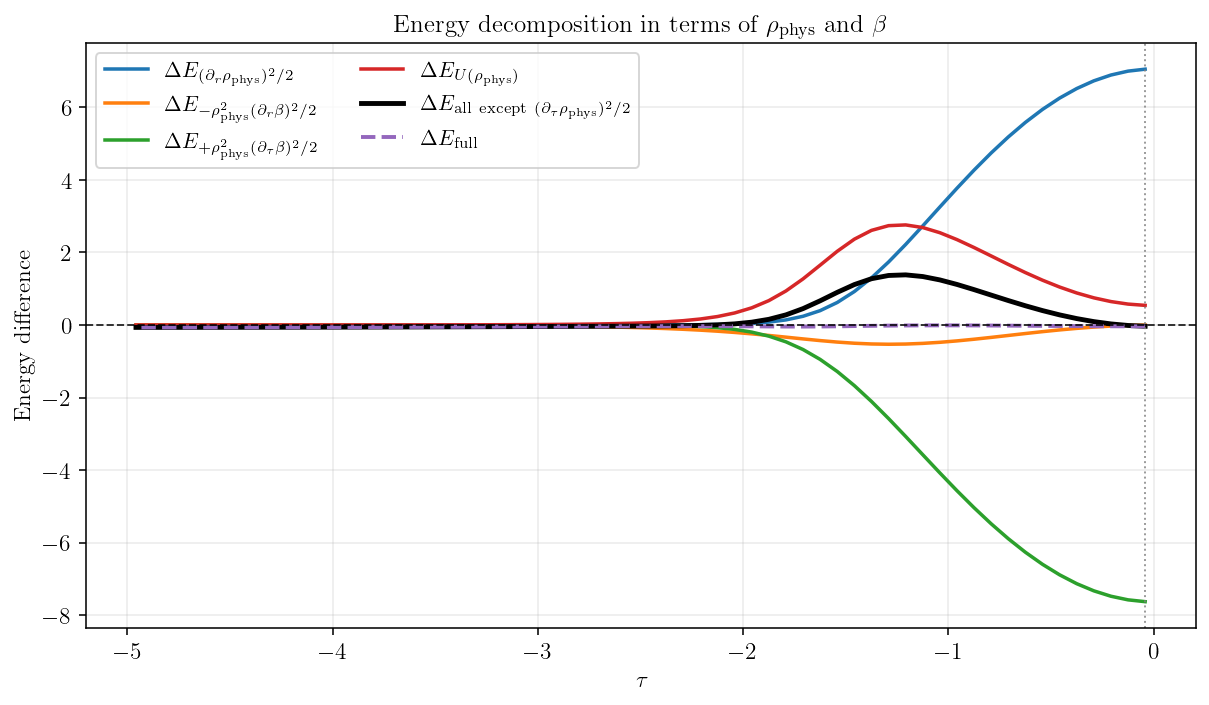

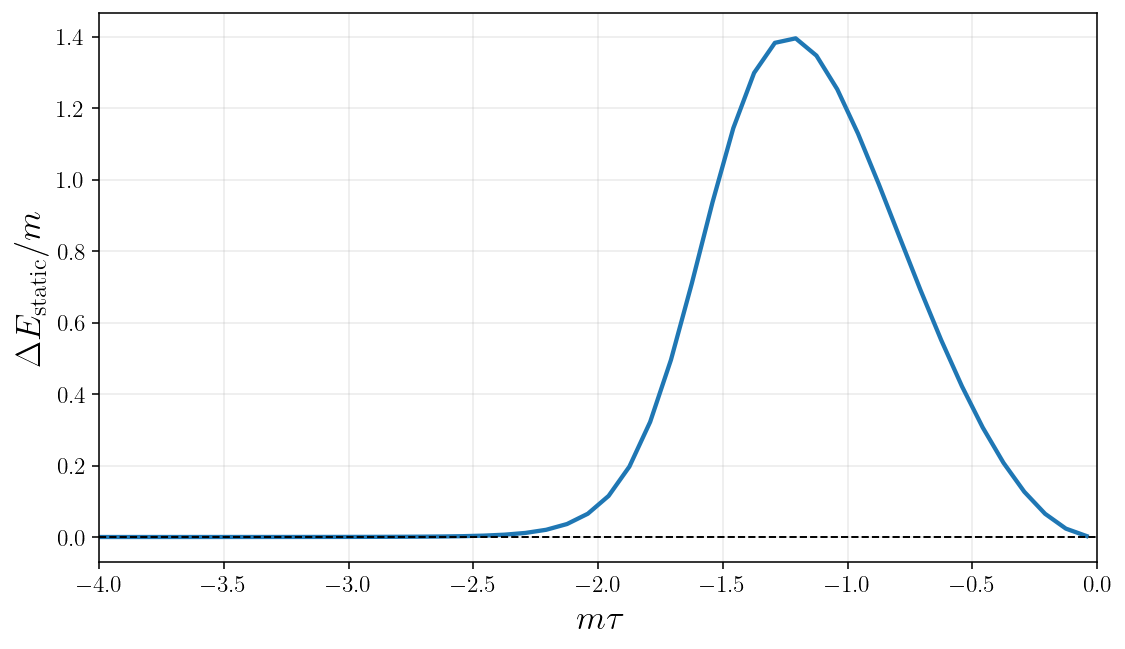

=== Energy decomposition in terms of rho_phys and beta ===
rho_hom_phys                      = 1.0312018013e+00
E_no_rho_tau_hom                  = -3.7190081667e+00
E_full_hom                        = -3.7190081667e+00

max |E_full_direct - E_full_polar| = 1.0713374628e-03

tau(min-grid)                     = -4.9583333333e+00
tau(0-grid)                       = -4.1666666667e-02

Delta E_no_rho_tau(tau_min)       = -6.6040897775e-02
Delta E_no_rho_tau(tau=0)         = -3.4625824554e-02
Delta E_full(tau_min)             = -6.6040917523e-02
Delta E_full(tau=0)               = -3.7240567480e-02
Delta E_rho_tau(tau_min)          = 1.9856354279e-08
Delta E_rho_tau(tau=0)            = 2.6273313798e-03


In [44]:
# ============================================================
# Energy decomposition in terms of rho_phys and beta:
# plot the sum of ALL Minkowski-energy components EXCEPT
# the temporal-modulus piece (1/2) * (d_tau rho_phys)^2.
#
# Definitions:
#   phi    = (rho_phys / sqrt(2)) * exp(+beta)
#   phibar = (rho_phys / sqrt(2)) * exp(-beta)
#
# Then
#   (d_r phi)(d_r phibar)      = 1/2 (d_r rho_phys)^2 - 1/2 rho_phys^2 (d_r beta)^2
#   -(d_tau phi)(d_tau phibar) = -1/2 (d_tau rho_phys)^2 + 1/2 rho_phys^2 (d_tau beta)^2
#
# So the quantity we want is
#
#   E_no_rho_tau(tau)
#     = 4*pi \int dr r^2 [
#           1/2 (d_r rho_phys)^2
#         - 1/2 rho_phys^2 (d_r beta)^2
#         + 1/2 rho_phys^2 (d_tau beta)^2
#         + U(rho_phys)
#       ]
#
# which is the full Minkowski energy with the piece
#   + 1/2 (d_tau rho_phys)^2
# removed.
# ============================================================

import numpy as np
from scipy.integrate import simpson

tau_grid = np.asarray(solver_o4.grid.tau, dtype=float)
r_grid   = np.asarray(solver_o4.grid.r, dtype=float)

y    = np.asarray(sol_o4.y)
ybar = np.asarray(sol_o4.ybar)

Nr, Nt = y.shape
dt = float(getattr(solver_o4, "dt", getattr(solver_o4.grid, "dtau")))
omega = float(solver_o4.omega)
rho0_phi_units = float(solver_o4.rho0)
rho_eps = float(getattr(solver_o4.settings, "rho_eps", 1e-30))

# ------------------------------------------------------------
# Reconstruct phi, phibar
# ------------------------------------------------------------
phi, phibar = solver_o4.phi(y, ybar)

# ------------------------------------------------------------
# BC-aware tau derivatives of phi, phibar
# ------------------------------------------------------------
phi_tau    = np.zeros_like(phi, dtype=np.complex128)
phibar_tau = np.zeros_like(phibar, dtype=np.complex128)

r = r_grid
inv_r = np.zeros_like(r, dtype=float)
inv_r[r != 0.0] = 1.0 / r[r != 0.0]

tau_increases = (tau_grid[1] > tau_grid[0]) if len(tau_grid) >= 2 else True

for i in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver_o4._tau_neighbors(y, ybar, i)

    if tau_increases:
        y_t  = (y_ip1  - y_im1)  / (2.0 * dt)
        yb_t = (yb_ip1 - yb_im1) / (2.0 * dt)
    else:
        y_t  = (y_im1  - y_ip1)  / (2.0 * dt)
        yb_t = (yb_im1 - yb_ip1) / (2.0 * dt)

    y_tot  = y[:, i]    + r * rho0_phi_units
    yb_tot = ybar[:, i] + r * rho0_phi_units

    exp_p = np.exp(+omega * tau_grid[i]) * inv_r
    exp_m = np.exp(-omega * tau_grid[i]) * inv_r

    phi_tau[:, i]    = exp_p * (y_t  + omega * y_tot)
    phibar_tau[:, i] = exp_m * (yb_t - omega * yb_tot)

# ------------------------------------------------------------
# Radial derivatives of phi, phibar
# ------------------------------------------------------------
phi_r    = np.zeros_like(phi, dtype=np.complex128)
phibar_r = np.zeros_like(phibar, dtype=np.complex128)

for i in range(Nt):
    dphi_dr = np.gradient(phi[:, i], r_grid, edge_order=2)
    dphibar_dr = np.gradient(phibar[:, i], r_grid, edge_order=2)
    dphi_dr[0] = 0.0
    dphibar_dr[0] = 0.0
    phi_r[:, i] = dphi_dr
    phibar_r[:, i] = dphibar_dr

# ------------------------------------------------------------
# rho_phys from solver conventions:
#   u = Re(phi phibar) = |phi|^2 in solver units
#   rho_phys = sqrt(2 u)
# ------------------------------------------------------------
u = np.maximum((phi * phibar).real, 0.0)
u_safe = np.maximum(u, 1e-30)

rho_phys = np.sqrt(2.0 * u + rho_eps)
rho_phys_safe = np.maximum(rho_phys, 1e-30)

# ------------------------------------------------------------
# Build beta_r and beta_tau directly from phi, phibar
#
# Since
#   phibar * d_mu phi - phi * d_mu phibar = 2 u * d_mu beta
# and rho_phys^2 = 2u,
# we have equivalently
#   d_mu beta = (phibar*d_mu phi - phi*d_mu phibar) / rho_phys^2
# ------------------------------------------------------------
b_r   = (phibar * phi_r   - phi * phibar_r).real
b_tau = (phibar * phi_tau - phi * phibar_tau).real

beta_r   = b_r   / np.maximum(rho_phys**2, 1e-30)
beta_tau = b_tau / np.maximum(rho_phys**2, 1e-30)

# ------------------------------------------------------------
# Derivatives of rho_phys
# ------------------------------------------------------------
rho_r = np.zeros_like(rho_phys, dtype=float)
for i in range(Nt):
    drho_dr = np.gradient(rho_phys[:, i], r_grid, edge_order=2)
    drho_dr[0] = 0.0
    rho_r[:, i] = drho_dr

rho_tau = np.zeros_like(rho_phys, dtype=float)
for j in range(Nr):
    rho_tau[j, :] = np.gradient(rho_phys[j, :], tau_grid, edge_order=2)

# ------------------------------------------------------------
# Potential term
# ------------------------------------------------------------
U_vals = np.asarray(solver_o4.U(rho_phys), dtype=float)

# ------------------------------------------------------------
# Energy-density pieces in (rho_phys, beta)
# ------------------------------------------------------------
e_rho_r    = 0.5 * rho_r**2
e_beta_r   = -0.5 * rho_phys**2 * beta_r**2
e_beta_tau = +0.5 * rho_phys**2 * beta_tau**2
e_rho_tau  = +0.5 * rho_tau**2
e_pot      = U_vals

# Check:
# full Minkowski density should be
#   e_full = e_rho_r + e_beta_r + e_beta_tau - e_rho_tau + e_pot
# because -(d_tau phi d_tau phibar) = -1/2 rho_tau^2 + 1/2 rho^2 beta_tau^2
e_full_from_polar = e_rho_r + e_beta_r + e_beta_tau - e_rho_tau + e_pot

# Quantity requested:
# sum of all components EXCEPT the temporal-modulus term
e_no_rho_tau = e_rho_r + e_beta_r + e_beta_tau + e_pot

# Direct density from phi, phibar for cross-check
e_direct = -(phi_tau * phibar_tau).real + (phi_r * phibar_r).real + U_vals

# ------------------------------------------------------------
# Integrate over r
# ------------------------------------------------------------
def spherical_integral_over_r(density_2d):
    return np.array(
        [4.0 * np.pi * simpson(r_grid**2 * density_2d[:, i], x=r_grid) for i in range(Nt)],
        dtype=float,
    )

E_rho_r_tau    = spherical_integral_over_r(e_rho_r)
E_beta_r_tau   = spherical_integral_over_r(e_beta_r)
E_beta_tau_tau = spherical_integral_over_r(e_beta_tau)
E_rho_tau_tau  = spherical_integral_over_r(e_rho_tau)
E_pot_tau      = spherical_integral_over_r(e_pot)

E_no_rho_tau_tau    = spherical_integral_over_r(e_no_rho_tau)
E_full_direct_tau   = spherical_integral_over_r(e_direct)
E_full_polar_tau    = spherical_integral_over_r(e_full_from_polar)

# ------------------------------------------------------------
# Homogeneous reference
# In the homogeneous background:
#   rho_phys,h = sqrt(2) rho0
#   beta_r = 0
#   rho_r = 0
#   rho_tau = 0
#   beta_tau = omega
# ------------------------------------------------------------
rho_hom_phys = np.sqrt(2.0) * rho0_phi_units
U_hom = float(np.asarray(solver_o4.U(np.array([rho_hom_phys], dtype=float))).flat[0])

V_space = float((4.0 / 3.0) * np.pi * (r_grid[-1]**3))

E_rho_r_hom    = 0.0
E_beta_r_hom   = 0.0
E_beta_tau_hom = 0.5 * rho_hom_phys**2 * omega**2 * V_space   # = omega^2 rho0^2 V
E_rho_tau_hom  = 0.0
E_pot_hom      = U_hom * V_space

E_no_rho_tau_hom = E_rho_r_hom + E_beta_r_hom + E_beta_tau_hom + E_pot_hom
E_full_hom       = E_no_rho_tau_hom - E_rho_tau_hom

# ------------------------------------------------------------
# Differences w.r.t. homogeneous
# ------------------------------------------------------------
delta_E_rho_r    = E_rho_r_tau    - E_rho_r_hom
delta_E_beta_r   = E_beta_r_tau   - E_beta_r_hom
delta_E_beta_tau = E_beta_tau_tau - E_beta_tau_hom
delta_E_rho_tau  = E_rho_tau_tau  - E_rho_tau_hom
delta_E_pot      = E_pot_tau      - E_pot_hom

delta_E_no_rho_tau = E_no_rho_tau_tau - E_no_rho_tau_hom
delta_E_full       = E_full_direct_tau - E_full_hom

# ------------------------------------------------------------
# Diagnostics indices
# ------------------------------------------------------------
i_tau0 = int(np.argmin(np.abs(tau_grid - 0.0)))
i_taumin = 0 if tau_grid[0] < tau_grid[-1] else Nt - 1

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.8, 5.2))

ax.plot(tau_grid, delta_E_rho_r,    lw=1.8, label=r"$\Delta E_{(\partial_r \rho_{\rm phys})^2/2}$")
ax.plot(tau_grid, delta_E_beta_r,   lw=1.8, label=r"$\Delta E_{-\rho_{\rm phys}^2(\partial_r\beta)^2/2}$")
ax.plot(tau_grid, delta_E_beta_tau, lw=1.8, label=r"$\Delta E_{+\rho_{\rm phys}^2(\partial_\tau\beta)^2/2}$")
ax.plot(tau_grid, delta_E_pot,      lw=1.8, label=r"$\Delta E_{U(\rho_{\rm phys})}$")

ax.plot(
    tau_grid,
    delta_E_no_rho_tau,
    color="k",
    lw=2.5,
    label=r"$\Delta E_{\rm all\ except\ (\partial_\tau \rho_{\rm phys})^2/2}$"
)

ax.plot(
    tau_grid,
    delta_E_full,
    "--",
    lw=2.0,
    label=r"$\Delta E_{\rm full}$"
)

ax.axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.8)
ax.axvline(tau_grid[i_tau0], color="gray", ls=":", lw=1.0, alpha=0.8)

ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"Energy difference")
ax.set_title(r"Energy decomposition in terms of $\rho_{\rm phys}$ and $\beta$")
ax.legend(loc="best", ncol=2)
fig.tight_layout()

if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_energy_decomposition_rho_phys_beta_except_rho_tau.pdf",
        bbox_inches="tight",
    )

plt.show()

# ------------------------------------------------------------
# Cross-check plot: missing piece should be exactly delta_E_rho_tau
# since E_full = E_no_rho_tau - E_rho_tau
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(
    tau_grid,
    delta_E_no_rho_tau - delta_E_full,
    lw=2.2,
    #label=r"$\Delta E_{static}$"
)
# ax.plot(
#     tau_grid,
#     delta_E_rho_tau,
#     "--",
#     lw=2.0,
#     label=r"$\Delta E_{(\partial_\tau \rho_{\rm phys})^2/2}$"
# )
ax.axhline(0.0, color="k", ls="--", lw=1.0)
ax.set_xlabel(r"$m\tau$", fontsize=18)
ax.set_ylabel(r"$\Delta E_{\rm static}/m$", fontsize=18)
ax.set_xlim(-4, 0)
#ax.set_title(r"Cross-check of the omitted temporal-modulus contribution")
#ax.legend(loc="best")
fig.tight_layout()

if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_energy_static.pdf",
        bbox_inches="tight",
    )

plt.show()

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
max_full_err = np.max(np.abs(E_full_direct_tau - E_full_polar_tau))

print("=== Energy decomposition in terms of rho_phys and beta ===")
print(f"rho_hom_phys                      = {rho_hom_phys:.10e}")
print(f"E_no_rho_tau_hom                  = {E_no_rho_tau_hom:.10e}")
print(f"E_full_hom                        = {E_full_hom:.10e}")
print()
print(f"max |E_full_direct - E_full_polar| = {max_full_err:.10e}")
print()
print(f"tau(min-grid)                     = {tau_grid[i_taumin]:.10e}")
print(f"tau(0-grid)                       = {tau_grid[i_tau0]:.10e}")
print()
print(f"Delta E_no_rho_tau(tau_min)       = {delta_E_no_rho_tau[i_taumin]:.10e}")
print(f"Delta E_no_rho_tau(tau=0)         = {delta_E_no_rho_tau[i_tau0]:.10e}")
print(f"Delta E_full(tau_min)             = {delta_E_full[i_taumin]:.10e}")
print(f"Delta E_full(tau=0)               = {delta_E_full[i_tau0]:.10e}")
print(f"Delta E_rho_tau(tau_min)          = {delta_E_rho_tau[i_taumin]:.10e}")
print(f"Delta E_rho_tau(tau=0)            = {delta_E_rho_tau[i_tau0]:.10e}")

### 13.2 Charged Bitar–Chang barrier

Build the static charged barrier $U_{\rm BC}=\Delta K_\alpha+\Delta G_\rho+\Delta V$ from the energy-decomposition arrays and compare its half-domain integral with the fixed-$Q$ exponent $F_Q$.


Reference fixed-Q exponent
S_bounce_full                         = -8.683037859653e+03
S_hom                                 = -8.721482554254e+03
Sdiff_rate = S_bounce_full - S_hom     = 3.844469460071e+01
eta0 Q                                = -3.024256212525e+01
F_rate = Sdiff_rate + eta0 Q           = 8.202132475457e+00

Inferred sign convention
sK for temporal phase piece            = +1
sG for spatial phase piece             = +1
max |E_candidate - delta_E_full|        = 1.071337462822e-03
max |L_tilde_BC - L_tilde|              = 4.440892098501e-16

Charged Bitar-Chang check
2 int_half L_tilde                     = 7.853587878623e+00
2 int_half L_tilde_BC                  = 7.853587878623e+00
4 int_half U_BC                        = 7.453910316083e+00
4 int_half left_out_BC                 = 8.253265441162e+00
F_rate                                 = 8.202132475457e+00

(2 int_half L_tilde) / F_rate          = 9.575056123664e-01
(4 int_half U_BC) / F_rate             = 9.087771

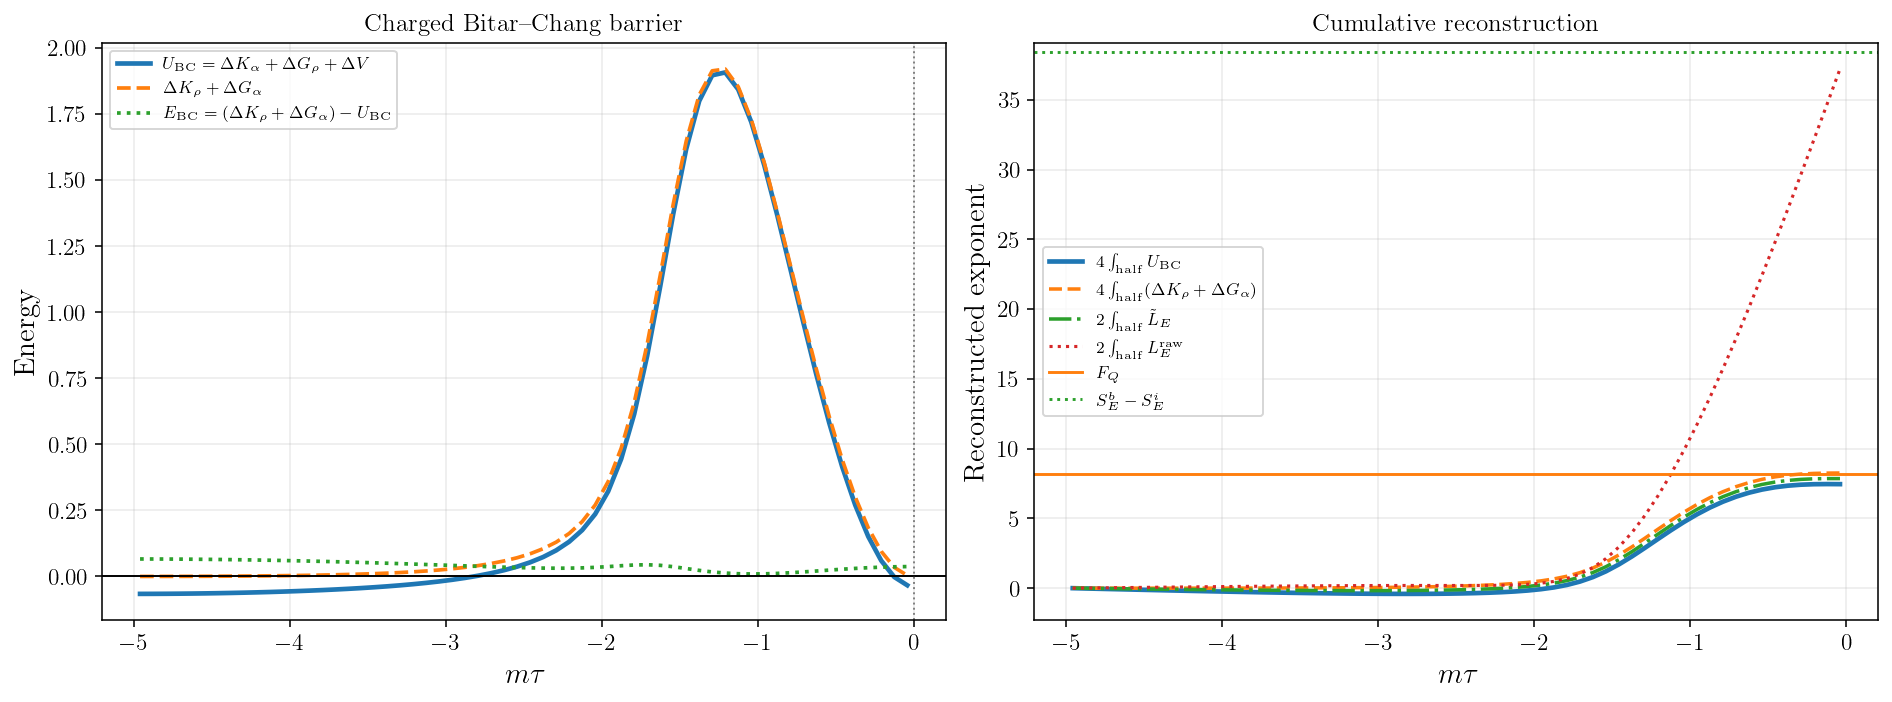

In [45]:
# ============================================================
# Minimal fixed-Q Bitar-Chang check: charged barrier
#
# Goal:
#   Check whether the fixed-charge exponent F_Q is reconstructed by the
#   charged Bitar-Chang barrier.
#
# Key point:
#   After adding eta0 Q, the phase-derivative terms have the positive signs
#   in the fixed-Q Euclidean functional.
#
# Define positive pieces:
#
#   Delta K_rho     = temporal modulus kinetic
#   Delta K_alpha   = temporal phase kinetic
#   Delta G_rho     = spatial modulus gradient
#   Delta G_alpha   = spatial phase gradient
#   Delta V         = potential
#
# Fixed-Q sign-flipped Lagrangian:
#
#   Delta L_tilde
#     = Delta K_rho + Delta K_alpha
#     + Delta G_rho + Delta G_alpha
#     + Delta V
#
# Charged Bitar-Chang barrier:
#
#   U_BC
#     = Delta K_alpha + Delta G_rho + Delta V
#
# Left-out terms:
#
#   L_out
#     = Delta K_rho + Delta G_alpha
#
# Energy constraint along the saddle:
#
#   L_out - U_BC = 0
#
# Hence:
#
#   Delta L_tilde = 2 U_BC
#
# and on the half-domain:
#
#   F_Q ?= 2 int_half Delta L_tilde
#   F_Q ?= 4 int_half U_BC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson, cumulative_trapezoid

from Bubble_finder.rate_exponent import (
    make_V_of_s_from_U,
    compute_euclidean_action_full,
    compute_homogeneous_action,
    compute_suppression_exponent_bubble,
    volume_from_grid,
)

# ------------------------------------------------------------
# Reference fixed-Q exponent
# ------------------------------------------------------------
slv = solver_o4
sol = sol_o4

try:
    V_of_s_for_rate
except NameError:
    V_of_s_for_rate = make_V_of_s_from_U(U)

S_bounce_full = float(
    compute_euclidean_action_full(
        sol.y,
        sol.ybar,
        slv.grid,
        omega=float(slv.omega),
        eta0=float(slv.eta0),
        rho0=float(slv.rho0),
        V_of_s=V_of_s_for_rate,
    )
)

S_hom = float(
    compute_homogeneous_action(
        beta=float(slv.settings.beta),
        V_ball=float(volume_from_grid(slv.grid)),
        omega=float(slv.omega),
        rho0=float(slv.rho0),
        V_of_s=V_of_s_for_rate,
    )
)

Q_sol = float(
    compute_charge_tau0_ghost_2d(
        slv,
        sol.y,
        sol.ybar,
        subtract_background=False,
    )
)

eta0 = float(slv.eta0)
eta0Q = eta0 * Q_sol

Sdiff_rate = S_bounce_full - S_hom
F_rate = float(
    compute_suppression_exponent_bubble(
        S_bounce_full=S_bounce_full,
        S_hom=S_hom,
        eta0=eta0,
        Q=Q_sol,
    )
)

# ------------------------------------------------------------
# Input arrays from the energy/action decomposition
# ------------------------------------------------------------
tau_arr = np.asarray(tau_grid, dtype=float)

dK_rho = np.asarray(delta_E_rho_tau, dtype=float)
dK_phase_stored = np.asarray(delta_E_beta_tau, dtype=float)

dG_rho = np.asarray(delta_E_rho_r, dtype=float)
dG_phase_stored = np.asarray(delta_E_beta_r, dtype=float)

dV = np.asarray(delta_E_pot, dtype=float)
dE_full_stored = np.asarray(delta_E_full, dtype=float)

# ------------------------------------------------------------
# Infer sign convention for stored phase pieces
#
# Physical hyperbolic Euclidean energy:
#
#   Delta E_full
#     = -Delta K_rho + Delta K_alpha
#       + Delta G_rho - Delta G_alpha + Delta V
#
# Stored phase arrays may already carry signs. Infer them by matching
# delta_E_full.
# ------------------------------------------------------------
best = None

for sK in (+1.0, -1.0):
    for sG in (+1.0, -1.0):
        E_candidate = (
            -dK_rho
            + sK * dK_phase_stored
            + dG_rho
            + sG * dG_phase_stored
            + dV
        )

        score = np.nanmax(np.abs(E_candidate - dE_full_stored))

        if best is None or score < best["score"]:
            best = {
                "sK": sK,
                "sG": sG,
                "score": score,
                "E_candidate": E_candidate,
            }

sK = best["sK"]
sG = best["sG"]

# Positive physical phase energies
K_alpha = sK * dK_phase_stored
G_alpha = -sG * dG_phase_stored

# ------------------------------------------------------------
# Raw and fixed-Q sign-flipped Lagrangians
# ------------------------------------------------------------

# Raw hyperbolic Euclidean Lagrangian before adding eta0 Q:
L_raw = dK_rho - K_alpha + dG_rho - G_alpha + dV

# Fixed-Q sign-flipped Euclidean Lagrangian:
L_tilde = dK_rho + K_alpha + dG_rho + G_alpha + dV

# ------------------------------------------------------------
# Charged Bitar-Chang barrier
# ------------------------------------------------------------

# Static charged barrier:
# temporal phase + spatial modulus + potential
U_BC = K_alpha + dG_rho + dV

# Terms left out of the BC barrier:
# temporal modulus + spatial phase
left_out_BC = dK_rho + G_alpha

# Energy-constraint diagnostic:
# should vanish on the saddle if the BC split is correct
E_BC = left_out_BC - U_BC

# Equivalent reconstruction:
L_tilde_BC = left_out_BC + U_BC

# Consistency check:
L_tilde_mismatch = L_tilde_BC - L_tilde

# ------------------------------------------------------------
# Sort in tau and integrate on the half-domain
# ------------------------------------------------------------
order = np.argsort(tau_arr)

tau_sorted = tau_arr[order]

U_BC_sorted = U_BC[order]
left_out_sorted = left_out_BC[order]
E_BC_sorted = E_BC[order]

L_tilde_sorted = L_tilde[order]
L_tilde_BC_sorted = L_tilde_BC[order]
L_raw_sorted = L_raw[order]

Efull_sorted = dE_full_stored[order]
E_candidate_sorted = best["E_candidate"][order]

I_U_BC_half = float(simpson(U_BC_sorted, x=tau_sorted))
I_left_out_half = float(simpson(left_out_sorted, x=tau_sorted))
I_E_BC_half = float(simpson(E_BC_sorted, x=tau_sorted))

I_Ltilde_half = float(simpson(L_tilde_sorted, x=tau_sorted))
I_Ltilde_BC_half = float(simpson(L_tilde_BC_sorted, x=tau_sorted))
I_Lraw_half = float(simpson(L_raw_sorted, x=tau_sorted))

# Full-domain reconstructions from half-domain arrays
F_from_tilde_direct = 2.0 * I_Ltilde_half
F_from_BC_direct = 2.0 * I_Ltilde_BC_half
F_from_BC_barrier = 4.0 * I_U_BC_half
F_from_BC_left_out = 4.0 * I_left_out_half

Sdiff_from_raw = 2.0 * I_Lraw_half

# ------------------------------------------------------------
# Useful tau=0 diagnostics
# ------------------------------------------------------------
idx0 = int(np.argmin(np.abs(tau_sorted)))

tau0_val = tau_sorted[idx0]
U_BC_tau0 = U_BC_sorted[idx0]
left_out_tau0 = left_out_sorted[idx0]
E_BC_tau0 = E_BC_sorted[idx0]

dK_rho_sorted = dK_rho[order]
K_alpha_sorted = K_alpha[order]
dG_rho_sorted = dG_rho[order]
G_alpha_sorted = G_alpha[order]
dV_sorted = dV[order]

# ------------------------------------------------------------
# Safe ratios
# ------------------------------------------------------------
def _safe_ratio(a, b):
    return np.nan if abs(b) < 1e-30 else a / b

# ------------------------------------------------------------
# Print diagnostics
# ------------------------------------------------------------
print("=" * 96)
print("Reference fixed-Q exponent")
print("=" * 96)
print(f"S_bounce_full                         = {S_bounce_full:.12e}")
print(f"S_hom                                 = {S_hom:.12e}")
print(f"Sdiff_rate = S_bounce_full - S_hom     = {Sdiff_rate:.12e}")
print(f"eta0 Q                                = {eta0Q:.12e}")
print(f"F_rate = Sdiff_rate + eta0 Q           = {F_rate:.12e}")
print()

print("=" * 96)
print("Inferred sign convention")
print("=" * 96)
print(f"sK for temporal phase piece            = {sK:+.0f}")
print(f"sG for spatial phase piece             = {sG:+.0f}")
print(f"max |E_candidate - delta_E_full|        = {best['score']:.12e}")
print(f"max |L_tilde_BC - L_tilde|              = {np.nanmax(np.abs(L_tilde_mismatch)):.12e}")
print()

print("=" * 96)
print("Charged Bitar-Chang check")
print("=" * 96)
print(f"2 int_half L_tilde                     = {F_from_tilde_direct:.12e}")
print(f"2 int_half L_tilde_BC                  = {F_from_BC_direct:.12e}")
print(f"4 int_half U_BC                        = {F_from_BC_barrier:.12e}")
print(f"4 int_half left_out_BC                 = {F_from_BC_left_out:.12e}")
print(f"F_rate                                 = {F_rate:.12e}")
print()
print(f"(2 int_half L_tilde) / F_rate          = {_safe_ratio(F_from_tilde_direct, F_rate):.12e}")
print(f"(4 int_half U_BC) / F_rate             = {_safe_ratio(F_from_BC_barrier, F_rate):.12e}")
print(f"(4 int_half left_out_BC) / F_rate      = {_safe_ratio(F_from_BC_left_out, F_rate):.12e}")
print()
print(f"2 int_half L_tilde - F_rate            = {F_from_tilde_direct - F_rate:.12e}")
print(f"4 int_half U_BC - F_rate               = {F_from_BC_barrier - F_rate:.12e}")
print(f"4 int_half left_out_BC - F_rate        = {F_from_BC_left_out - F_rate:.12e}")
print()

print("=" * 96)
print("BC energy-constraint diagnostics")
print("=" * 96)
print(f"max |E_BC| = max |left_out_BC-U_BC|     = {np.nanmax(np.abs(E_BC)):.12e}")
print(f"int_half E_BC                          = {I_E_BC_half:.12e}")
print(f"max |left_out_BC-U_BC|/max|U_BC|        = {_safe_ratio(np.nanmax(np.abs(E_BC)), np.nanmax(np.abs(U_BC))):.12e}")
print()

print("=" * 96)
print("tau = 0 diagnostics")
print("=" * 96)
print(f"tau closest to zero                     = {tau0_val:.12e}")
print(f"U_BC(tau=0)                             = {U_BC_tau0:.12e}")
print(f"left_out_BC(tau=0)                      = {left_out_tau0:.12e}")
print(f"E_BC(tau=0)                             = {E_BC_tau0:.12e}")
print(f"Delta K_rho(tau=0)                      = {dK_rho_sorted[idx0]:.12e}")
print(f"Delta G_alpha(tau=0)                    = {G_alpha_sorted[idx0]:.12e}")
print(f"Delta K_alpha(tau=0)                    = {K_alpha_sorted[idx0]:.12e}")
print(f"Delta G_rho(tau=0)                      = {dG_rho_sorted[idx0]:.12e}")
print(f"Delta V(tau=0)                          = {dV_sorted[idx0]:.12e}")
print()

print("=" * 96)
print("Raw action comparison before eta0 Q")
print("=" * 96)
print(f"2 int_half L_raw                       = {Sdiff_from_raw:.12e}")
print(f"Sdiff_rate                             = {Sdiff_rate:.12e}")
print(f"2 int_half L_raw - Sdiff_rate          = {Sdiff_from_raw - Sdiff_rate:.12e}")

# ------------------------------------------------------------
# Cumulative reconstructions
# ------------------------------------------------------------
cum_F_from_BC = 4.0 * cumulative_trapezoid(U_BC_sorted, tau_sorted, initial=0.0)
cum_F_from_left_out = 4.0 * cumulative_trapezoid(left_out_sorted, tau_sorted, initial=0.0)
cum_F_from_tilde = 2.0 * cumulative_trapezoid(L_tilde_sorted, tau_sorted, initial=0.0)
cum_Sdiff_from_raw = 2.0 * cumulative_trapezoid(L_raw_sorted, tau_sorted, initial=0.0)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9), constrained_layout=True)

ax = axes[0]
ax.plot(
    tau_sorted,
    U_BC_sorted,
    lw=2.4,
    label=r"$U_{\rm BC}=\Delta K_\alpha+\Delta G_\rho+\Delta V$",
)
ax.plot(
    tau_sorted,
    left_out_sorted,
    "--",
    lw=1.9,
    label=r"$\Delta K_\rho+\Delta G_\alpha$",
)
ax.plot(
    tau_sorted,
    E_BC_sorted,
    ":",
    lw=1.9,
    label=r"$E_{\rm BC}=(\Delta K_\rho+\Delta G_\alpha)-U_{\rm BC}$",
)
ax.axhline(0.0, color="k", lw=1.0)
ax.axvline(0.0, color="0.5", ls=":", lw=1.0)
ax.set_xlabel(r"$m\tau$", fontsize=15)
ax.set_ylabel(r"Energy", fontsize=15)
ax.set_title(r"Charged Bitar--Chang barrier")
ax.legend(loc="best", fontsize=8.5)
ax.grid(True, alpha=0.25)

ax = axes[1]
ax.plot(
    tau_sorted,
    cum_F_from_BC,
    lw=2.4,
    label=r"$4\int_{\rm half} U_{\rm BC}$",
)
ax.plot(
    tau_sorted,
    cum_F_from_left_out,
    "--",
    lw=1.8,
    label=r"$4\int_{\rm half}(\Delta K_\rho+\Delta G_\alpha)$",
)
ax.plot(
    tau_sorted,
    cum_F_from_tilde,
    "-.",
    lw=1.8,
    label=r"$2\int_{\rm half}\tilde L_E$",
)
ax.plot(
    tau_sorted,
    cum_Sdiff_from_raw,
    ":",
    lw=1.6,
    label=r"$2\int_{\rm half}L_E^{\rm raw}$",
)
ax.axhline(F_rate, color="C1", ls="-", lw=1.5, label=r"$F_Q$")
ax.axhline(Sdiff_rate, color="C2", ls=":", lw=1.5, label=r"$S_E^b-S_E^i$")
ax.set_xlabel(r"$m\tau$", fontsize=15)
ax.set_ylabel(r"Reconstructed exponent", fontsize=15)
ax.set_title(r"Cumulative reconstruction")
ax.legend(loc="best", fontsize=8.5)
ax.grid(True, alpha=0.25)

if "CFG" in globals() and CFG.get("save_figures", False):
    fig.savefig(
        CFG["figures_dir"] / "o4_charged_bitar_chang_barrier.pdf",
        bbox_inches="tight",
    )

plt.show()

### 13.3 Static-barrier comparison plots

Compare $U_{\rm BC}$, the neutral Coleman $O(4)$ reference, and multi-$\omega$ static barriers.


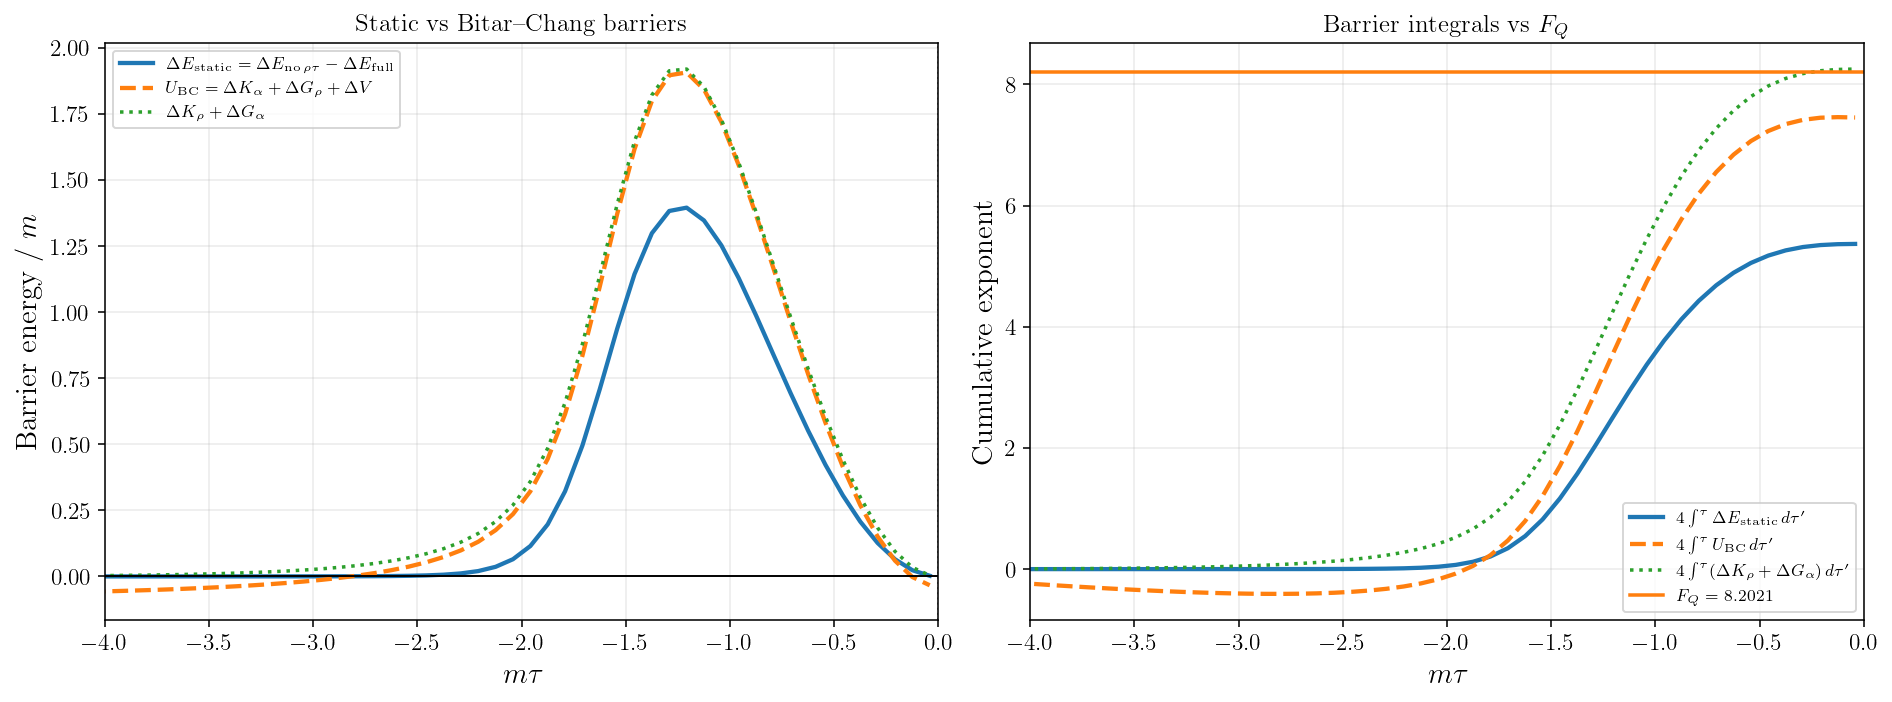

Barrier half-domain integrals vs F_Q
int_half Delta E_static d(tau)           = 1.341813791303e+00
int_half U_BC d(tau)                     = 1.863477579021e+00
int_half (Delta K_rho + Delta G_alpha)   = 2.063316360291e+00

4 * int_half Delta E_static              = 5.367255165211e+00
4 * int_half U_BC                        = 7.453910316083e+00
4 * int_half (Delta K_rho + Delta G_alpha) = 8.253265441162e+00
F_Q (F_rate)                             = 8.202132475457e+00

(4 int Delta E_static) / F_Q             = 6.543731378725e-01
(4 int U_BC) / F_Q                       = 9.087771184369e-01
(4 int left_out_BC) / F_Q                = 1.006234106296e+00

4 int Delta E_static - F_Q               = -2.834877310246e+00
4 int U_BC - F_Q                         = -7.482221593738e-01
4 int left_out_BC - F_Q                  = 5.113296570503e-02


In [46]:
# Compare static barrier (Delta E_static) vs charged Bitar-Chang barrier U_BC
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson, cumulative_trapezoid

required = [
    "tau_grid",
    "delta_E_no_rho_tau",
    "delta_E_full",
    "U_BC",
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(
        "Missing variables. Run the energy-decomposition cell and the "
        f"Bitar-Chang cell first. Missing: {missing}"
    )

if "F_rate" not in globals():
    raise RuntimeError("Missing F_rate. Run the Bitar-Chang cell first.")

tau_arr = np.asarray(tau_grid, dtype=float)
order = np.argsort(tau_arr)
tau_sorted = tau_arr[order]

# Static / temporal-modulus barrier from the second decomposition plot
B_static = np.asarray(delta_E_no_rho_tau - delta_E_full, dtype=float)[order]

# Charged Bitar-Chang barrier from the BC cell
U_BC_sorted = np.asarray(U_BC, dtype=float)[order]

if "left_out_BC" in globals():
    left_out_sorted = np.asarray(left_out_BC, dtype=float)[order]
else:
    left_out_sorted = None

F_Q = float(F_rate)

# Half-domain integrals (same convention as the BC check cell)
I_static_half = float(simpson(B_static, x=tau_sorted))
I_BC_half = float(simpson(U_BC_sorted, x=tau_sorted))

F_from_static_x4 = 4.0 * I_static_half
F_from_BC_x4 = 4.0 * I_BC_half

if left_out_sorted is not None:
    I_left_out_half = float(simpson(left_out_sorted, x=tau_sorted))
    F_from_left_out_x4 = 4.0 * I_left_out_half
else:
    I_left_out_half = np.nan
    F_from_left_out_x4 = np.nan

# ------------------------------------------------------------
# Plot: both barriers vs tau
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9), constrained_layout=True)

ax = axes[0]
ax.plot(
    tau_sorted,
    B_static,
    lw=2.2,
    label=r"$\Delta E_{\rm static}=\Delta E_{\rm no\,\rho\tau}-\Delta E_{\rm full}$",
)
ax.plot(
    tau_sorted,
    U_BC_sorted,
    lw=2.2,
    ls="--",
    label=r"$U_{\rm BC}=\Delta K_\alpha+\Delta G_\rho+\Delta V$",
)
if left_out_sorted is not None:
    ax.plot(
        tau_sorted,
        left_out_sorted,
        lw=1.8,
        ls=":",
        label=r"$\Delta K_\rho+\Delta G_\alpha$",
    )
ax.axhline(0.0, color="k", lw=1.0)
ax.axvline(0.0, color="0.5", ls=":", lw=1.0)
ax.set_xlim(-4.0, 0.0)
ax.set_xlabel(r"$m\tau$", fontsize=15)
ax.set_ylabel(r"Barrier energy / $m$", fontsize=15)
ax.set_title(r"Static vs Bitar--Chang barriers")
ax.legend(loc="best", fontsize=8.5)
ax.grid(True, alpha=0.25)

# Cumulative integrals vs F_Q
ax = axes[1]
cum_static_x4 = 4.0 * cumulative_trapezoid(B_static, tau_sorted, initial=0.0)
cum_BC_x4 = 4.0 * cumulative_trapezoid(U_BC_sorted, tau_sorted, initial=0.0)
ax.plot(tau_sorted, cum_static_x4, lw=2.2, label=r"$4\int^\tau \Delta E_{\rm static}\,d\tau'$")
ax.plot(tau_sorted, cum_BC_x4, lw=2.2, ls="--", label=r"$4\int^\tau U_{\rm BC}\,d\tau'$")
if left_out_sorted is not None:
    cum_left_x4 = 4.0 * cumulative_trapezoid(left_out_sorted, tau_sorted, initial=0.0)
    ax.plot(
        tau_sorted,
        cum_left_x4,
        lw=1.8,
        ls=":",
        label=r"$4\int^\tau(\Delta K_\rho+\Delta G_\alpha)\,d\tau'$",
    )
ax.axhline(F_Q, color="C1", lw=1.8, label=rf"$F_Q={F_Q:.4f}$")
ax.set_xlim(-4.0, 0.0)
ax.set_xlabel(r"$m\tau$", fontsize=15)
ax.set_ylabel(r"Cumulative exponent", fontsize=15)
ax.set_title(r"Barrier integrals vs $F_Q$")
ax.legend(loc="best", fontsize=8.5)
ax.grid(True, alpha=0.25)

if "CFG" in globals() and CFG.get("save_figures", False):
    fig.savefig(
        CFG["figures_dir"] / "o4_static_vs_BC_barrier_integral.pdf",
        bbox_inches="tight",
    )

plt.show()

# ------------------------------------------------------------
# Print integral comparison with F_Q
# ------------------------------------------------------------
def _ratio(a, b):
    return np.nan if abs(b) < 1e-30 else a / b

print("=" * 72)
print("Barrier half-domain integrals vs F_Q")
print("=" * 72)
print(f"int_half Delta E_static d(tau)           = {I_static_half:.12e}")
print(f"int_half U_BC d(tau)                     = {I_BC_half:.12e}")
if np.isfinite(I_left_out_half):
    print(f"int_half (Delta K_rho + Delta G_alpha)   = {I_left_out_half:.12e}")
print()
print(f"4 * int_half Delta E_static              = {F_from_static_x4:.12e}")
print(f"4 * int_half U_BC                        = {F_from_BC_x4:.12e}")
if np.isfinite(F_from_left_out_x4):
    print(f"4 * int_half (Delta K_rho + Delta G_alpha) = {F_from_left_out_x4:.12e}")
print(f"F_Q (F_rate)                             = {F_Q:.12e}")
print()
print(f"(4 int Delta E_static) / F_Q             = {_ratio(F_from_static_x4, F_Q):.12e}")
print(f"(4 int U_BC) / F_Q                       = {_ratio(F_from_BC_x4, F_Q):.12e}")
if np.isfinite(F_from_left_out_x4):
    print(f"(4 int left_out_BC) / F_Q                = {_ratio(F_from_left_out_x4, F_Q):.12e}")
print()
print(f"4 int Delta E_static - F_Q               = {F_from_static_x4 - F_Q:.12e}")
print(f"4 int U_BC - F_Q                         = {F_from_BC_x4 - F_Q:.12e}")
if np.isfinite(F_from_left_out_x4):
    print(f"4 int left_out_BC - F_Q                  = {F_from_left_out_x4 - F_Q:.12e}")


In [47]:
# ============================================================
# Coleman O(4) static energy at Q = 0
#
# We take the genuine neutral Coleman profile:
#   rho_C = rho_C(R),  R = sqrt(r^2 + tau^2),
#
# where rho_C(R) is the 1D O(4) bounce at omega = 0.
#
# On each tau slice we compute the static 3D energy:
#
#   Delta E_static_Coleman(tau)
#     = 4*pi int dr r^2 [
#           1/2 (partial_r rho_C)^2
#         + U(rho_C) - U(rho_false,Q=0)
#       ].
#
# This is the direct Q=0 Coleman reference barrier.
# ============================================================

import numpy as np
from scipy.integrate import simpson

# ------------------------------------------------------------
# Get / build the neutral O(4) Coleman bounce
# ------------------------------------------------------------
if "bounces_fixed" in globals() and "omega_zero" in bounces_fixed and 4 in bounces_fixed["omega_zero"]:
    bounce_Coleman_Q0 = bounces_fixed["omega_zero"][4]
else:
    bounce_Coleman_Q0 = solve_or_load_bounce_1d(
        None,
        MODEL,
        omega=0.0,
        d=4,
        rmax=260.0,
        n_grid_points=1300,
        max_iter=180,
        verbose=False,
    )

R_C = np.asarray(bounce_Coleman_Q0["r"], dtype=float)
rho_C = np.asarray(bounce_Coleman_Q0["phi"], dtype=float)

rho_false_Q0 = float(bounce_Coleman_Q0["phi_false"])

# ------------------------------------------------------------
# Derivative d rho_C / dR on the 1D O(4) profile
# ------------------------------------------------------------
drhoC_dR = np.gradient(rho_C, R_C, edge_order=2)
drhoC_dR[0] = 0.0

# ------------------------------------------------------------
# Use the same r and tau grid as the finite-Q 2D solution
# ------------------------------------------------------------
tau_Coleman_Q0 = np.asarray(tau_grid, dtype=float)
r_Coleman_Q0 = np.asarray(r_grid, dtype=float)

R_map = np.sqrt(
    r_Coleman_Q0[:, None]**2
    +
    tau_Coleman_Q0[None, :]**2
)

# Interpolate rho_C(R) and rho_C'(R) onto R = sqrt(r^2 + tau^2)
rho_C_map = np.interp(
    R_map,
    R_C,
    rho_C,
    left=rho_C[0],
    right=rho_false_Q0,
)

drhoC_dR_map = np.interp(
    R_map,
    R_C,
    drhoC_dR,
    left=0.0,
    right=0.0,
)

# ------------------------------------------------------------
# Spatial and Euclidean-time derivatives induced by O(4)
#
# partial_r rho_C   = rho_C'(R) * r / R
# partial_tau rho_C = rho_C'(R) * tau / R
# ------------------------------------------------------------
safe_R_map = np.maximum(R_map, 1e-30)

rho_C_r = drhoC_dR_map * r_Coleman_Q0[:, None] / safe_R_map
rho_C_tau = drhoC_dR_map * tau_Coleman_Q0[None, :] / safe_R_map

rho_C_r[R_map < 1e-14] = 0.0
rho_C_tau[R_map < 1e-14] = 0.0

# ------------------------------------------------------------
# Potential subtraction relative to the neutral false vacuum
# ------------------------------------------------------------
U_C_map = np.asarray(solver_o4.U(rho_C_map), dtype=float)
U_false_Q0 = float(np.asarray(solver_o4.U(np.array([rho_false_Q0], dtype=float))).flat[0])

e_static_Coleman_Q0 = 0.5 * rho_C_r**2 + (U_C_map - U_false_Q0)
e_tau_Coleman_Q0 = 0.5 * rho_C_tau**2

E_static_Coleman_Q0_tau = np.array(
    [
        4.0 * np.pi * simpson(
            r_Coleman_Q0**2 * e_static_Coleman_Q0[:, i],
            x=r_Coleman_Q0,
        )
        for i in range(len(tau_Coleman_Q0))
    ],
    dtype=float,
)

E_tau_Coleman_Q0_tau = np.array(
    [
        4.0 * np.pi * simpson(
            r_Coleman_Q0**2 * e_tau_Coleman_Q0[:, i],
            x=r_Coleman_Q0,
        )
        for i in range(len(tau_Coleman_Q0))
    ],
    dtype=float,
)

# Coleman consistency check:
# the full Minkowski energy on a tau slice should be close to zero,
# up to finite box and interpolation effects:
#
#   Delta E_full = E_static - E_tau
#
E_full_Coleman_Q0_tau = E_static_Coleman_Q0_tau - E_tau_Coleman_Q0_tau

print("=== Coleman O(4), Q = 0 static-energy reference ===")
print(f"rho_false_Q0                      = {rho_false_Q0:.10e}")
print(f"U_false_Q0                        = {U_false_Q0:.10e}")
print(f"max Delta E_static_Coleman_Q0     = {np.nanmax(E_static_Coleman_Q0_tau):.10e}")
print(f"tau at max                        = {tau_Coleman_Q0[np.nanargmax(E_static_Coleman_Q0_tau)]:.10e}")
print(f"max |E_static - E_tau| Coleman    = {np.nanmax(np.abs(E_full_Coleman_Q0_tau)):.10e}")
print(f"E_static_Coleman_Q0(tau=0)        = {E_static_Coleman_Q0_tau[i_tau0]:.10e}")

=== Coleman O(4), Q = 0 static-energy reference ===
rho_false_Q0                      = 1.0000000184e+00
U_false_Q0                        = -5.0000000000e-01
max Delta E_static_Coleman_Q0     = 1.4110987509e+01
tau at max                        = -2.1250000000e+00
max |E_static - E_tau| Coleman    = 1.2317950764e-02
E_static_Coleman_Q0(tau=0)        = 1.2007641593e-02


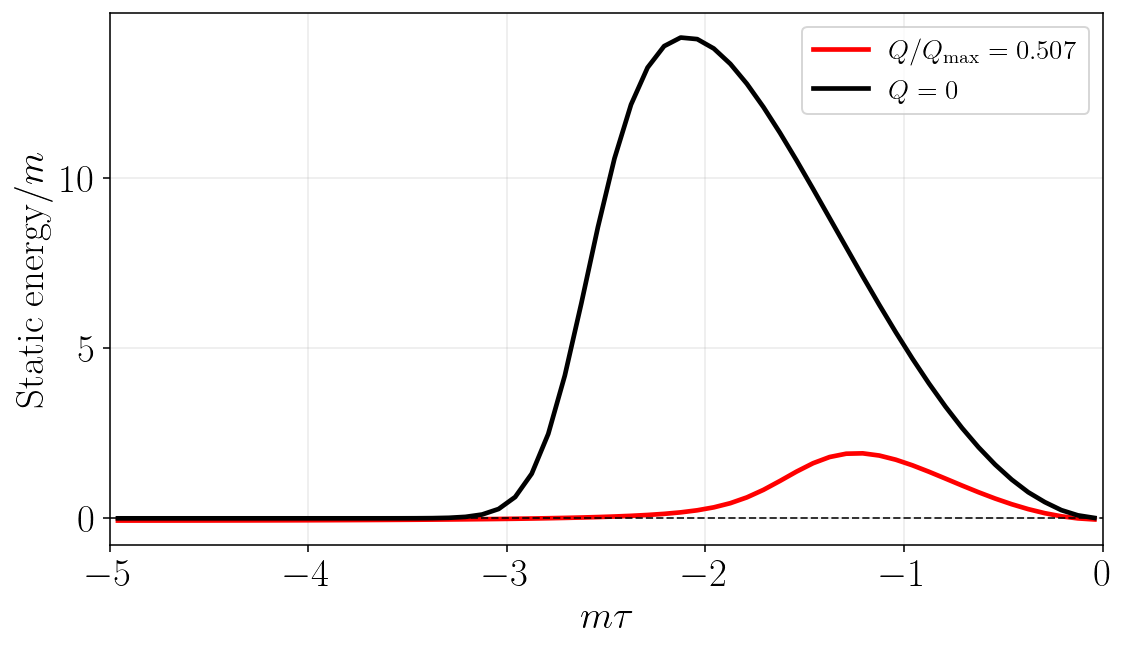

=== Static energy (U_BC) comparison ===
Qmax reference                    = 1.8038432768e+03
Qmax source                       = 2D target at omega=0.999*OMEGA_MAX=1.340081
Q(omega_ref) / Qmax               = 5.0670183727e-01
max U_BC (Q != 0)                 = 1.9075020247e+00
tau at max, Q != 0                = -1.2083333333e+00

max Coleman static (Q = 0)        = 1.4110987509e+01
tau at max, Q = 0                 = -2.1250000000e+00

ratio max(Q != 0) / max(Q = 0)    = 1.3517849290e-01
relative lowering                 = 8.6482150710e-01


In [48]:
# ============================================================
# Compare finite-Q Bitar-Chang static barrier with neutral Coleman O(4)
#
# Finite-Q curve: U_BC from the charged Bitar-Chang cell.
# Q = 0 reference: Coleman static energy E_static_Coleman_Q0_tau.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

if "U_BC" not in globals():
    raise RuntimeError("Run the charged Bitar-Chang barrier cell first (defines U_BC).")

static_energy_Qneq0 = np.asarray(U_BC, dtype=float)
static_energy_Q0_Coleman = np.asarray(E_static_Coleman_Q0_tau, dtype=float)


def _infer_static_qmax_ref():
    """Infer Qmax from the OMEGA_MAX cell, using the same 2D target-charge convention."""
    if "OMEGA_MAX" not in globals():
        return np.nan, "missing OMEGA_MAX"

    omega_for_qmax = float(0.999 * OMEGA_MAX)
    try:
        phi_false_qmax, _ = vacua_of_Omega(
            MODEL.phi0,
            MODEL.v1,
            MODEL.v2,
            omega_for_qmax,
            verbose=False,
        )
        settings_qmax = Bubble2DSettings(
            Nr=CFG_2D["Nr"],
            Ntau=CFG_2D["Ntau"],
            Lr=CFG_2D["Lr"],
            beta=float(CFG_2D["beta"]),
            omega_ref=omega_for_qmax,
            eta0=0.0,
            rho0=float(phi_false_qmax / np.sqrt(2.0)),
            newton_tol=CFG_2D["newton_tol"],
            newton_max_iter=CFG_2D["newton_max_iter"],
            damping=CFG_2D["damping"],
            max_backtracks=CFG_2D["max_backtracks"],
            rho0_bracket=CFG_2D["rho0_bracket"],
            complex_saddle=CFG_2D["complex_saddle"],
            verbose=False,
            tau_bc="twisted",
            r_bc="neumann",
            allow_debug_bcs=False,
        )
        solver_qmax = Bubble2DSolver(settings_qmax, U, dU, d2U)
        targets_qmax = compute_targets_tau0_ghost(solver_qmax, subtract_background_charge=False)
        return float(targets_qmax["Q"]), f"2D target at omega=0.999*OMEGA_MAX={omega_for_qmax:.6f}"
    except Exception as exc:
        print(f"[static Qmax] WARNING: failed to infer Qmax from OMEGA_MAX: {type(exc).__name__}: {exc}")

    if "scan_summary" in globals() and 4 in scan_summary and len(scan_summary[4]) > 0:
        q_vals = np.asarray([r.get("Q", np.nan) for r in scan_summary[4]], dtype=float)
        q_vals = q_vals[np.isfinite(q_vals)]
        if q_vals.size > 0:
            return float(np.nanmax(q_vals)), "scan_summary[4] fallback"

    return np.nan, "unavailable"


Q_MAX_STATIC_REF, Q_MAX_STATIC_REF_SOURCE = _infer_static_qmax_ref()
Q_static_omega_ref = np.nan
if "solver_o4" in globals() and "sol_o4" in globals():
    Q_static_omega_ref = float(
        compute_charge_tau0_ghost_2d(
            solver_o4,
            sol_o4.y,
            sol_o4.ybar,
            subtract_background=False,
        )
    )


Q_static_ratio_omega_ref = (
    float(Q_static_omega_ref / Q_MAX_STATIC_REF)
    if np.isfinite(Q_static_omega_ref) and np.isfinite(Q_MAX_STATIC_REF) and abs(Q_MAX_STATIC_REF) > 1e-30
    else np.nan
)

fig, ax = plt.subplots(figsize=(8.2, 4.8))

ax.plot(
    tau_grid,
    static_energy_Qneq0,
    color="red",
    lw=2.4,
    label=rf"$Q/Q_{{\max}}={Q_static_ratio_omega_ref:.3f}$",
)

ax.plot(
    tau_Coleman_Q0,
    static_energy_Q0_Coleman,
    color="k",
    ls="-",
    lw=2.4,
    label=r"$Q=0$",
)

ax.axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.8)

ax.set_xlabel(r"$m\tau$", fontsize=20)
ax.set_ylabel(r"Static energy$/m$", fontsize=20)
ax.set_xlim(-5, 0)
ax.tick_params(axis="both", which="major", labelsize=20)

ax.legend(loc="best", fontsize=14)
fig.tight_layout()

if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_energy_static_Qneq0_vs_Coleman_Q0.pdf",
        bbox_inches="tight",
    )

plt.show()

# ------------------------------------------------------------
# Quantitative comparison
# ------------------------------------------------------------
max_Qneq0 = float(np.nanmax(static_energy_Qneq0))
max_Q0 = float(np.nanmax(static_energy_Q0_Coleman))

tau_max_Qneq0 = float(tau_grid[np.nanargmax(static_energy_Qneq0)])
tau_max_Q0 = float(tau_Coleman_Q0[np.nanargmax(static_energy_Q0_Coleman)])

ratio = max_Qneq0 / max_Q0 if abs(max_Q0) > 1e-30 else np.nan
lowering = 1.0 - ratio if np.isfinite(ratio) else np.nan

print("=== Static energy (U_BC) comparison ===")
print(f"Qmax reference                    = {Q_MAX_STATIC_REF:.10e}")
print(f"Qmax source                       = {Q_MAX_STATIC_REF_SOURCE}")
print(f"Q(omega_ref) / Qmax               = {Q_static_ratio_omega_ref:.10e}")
print(f"max U_BC (Q != 0)                 = {max_Qneq0:.10e}")
print(f"tau at max, Q != 0                = {tau_max_Qneq0:.10e}")
print()
print(f"max Coleman static (Q = 0)        = {max_Q0:.10e}")
print(f"tau at max, Q = 0                 = {tau_max_Q0:.10e}")
print()
print(f"ratio max(Q != 0) / max(Q = 0)    = {ratio:.10e}")
print(f"relative lowering                 = {lowering:.10e}")



[static multi-omega] solving omega=0.950
[static multi-omega] omega=0.950: fresh O(4) seed, initial residual = 9.758589e+00
[Targets] eta0 scan references (total observables):
  Q_target_total = 9.14010702e+02
  E_target_total = 3.71899095e+00
[static multi-omega @ omega=0.95] eta=0.000000  Q_total=9.17679948e+02  E_total=2.85664797e-01  Q_total/Q*= 1.004014  E_total/E*= 0.076812
[static multi-omega @ omega=0.95] eta=-0.050000  Q_total=9.12138540e+02  E_total=5.55600487e+00  Q_total/Q*= 0.997952  E_total/E*= 1.493955
[static multi-omega @ omega=0.95*] eta=-0.033088  Q_total=9.14010702e+02  E_total=3.77847982e+00  Q_total/Q*= 1.000000  E_total/E*= 1.015996

[static multi-omega] solving omega=0.800
[static multi-omega] omega=0.800: continued from omega=0.950, initial residual = 1.339500e+02
[Targets] eta0 scan references (total observables):
  Q_target_total = 7.52883224e+02
  E_target_total = 1.44870159e+02
[static multi-omega @ omega=0.80] eta=0.000000  Q_total=7.58667212e+02  E_total

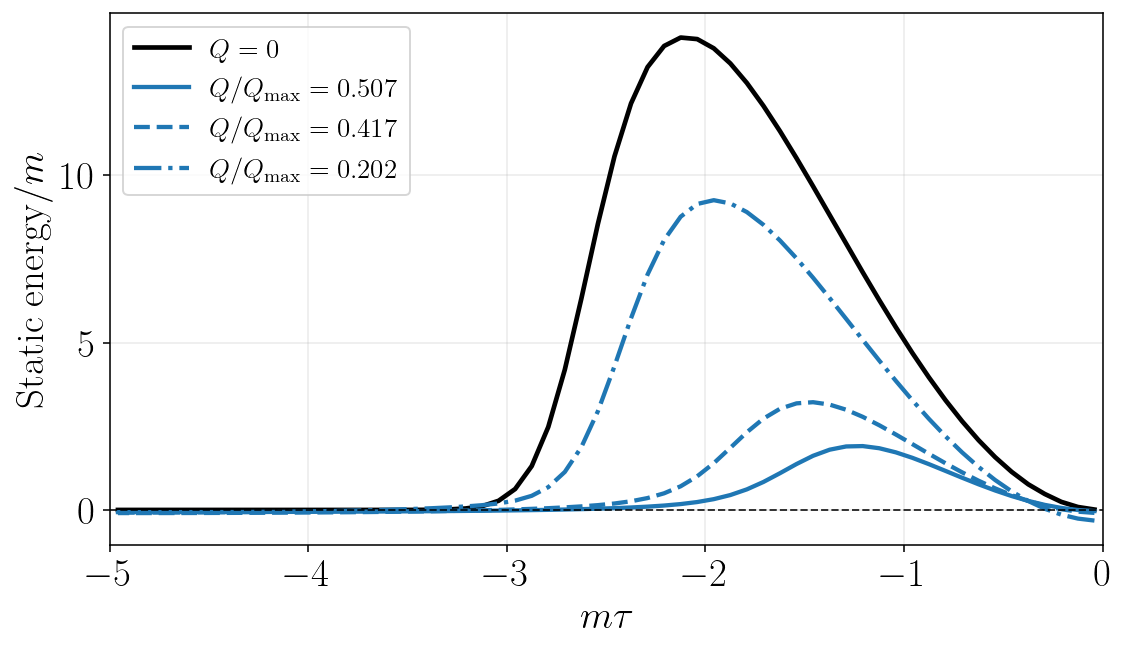

=== Multi-omega static energy (U_BC) comparison ===
Qmax used for labels = 1.8038432768e+03
Qmax source for labels = 2D target at omega=0.999*OMEGA_MAX=1.340081
[plot] omega=0.950  eta0=-0.033088  Q/Qmax=0.506702  max U_BC=1.9075020227e+00
[plot] omega=0.800  eta0=-0.056912  Q/Qmax=0.417377  max U_BC=3.2182746714e+00
[bridge] omega=0.650  eta0=-0.087261  Q/Qmax=0.333868  max U_BC=5.0492928951e+00
[bridge] omega=0.500  eta0=-0.114336  Q/Qmax=0.254046  max U_BC=7.4448628550e+00
[plot] omega=0.400  eta0=-0.121572  Q/Qmax=0.202198  max U_BC=9.2528567415e+00


In [49]:
# ============================================================
# Multi-omega Bitar-Chang static barrier vs neutral Coleman O(4)
#
# First omega uses a fresh O(4) seed; later omegas continue from the previous solution.
# Full chain steps down in omega (with intermediates 0.65, 0.5 before 0.4); plot only 0.85, 0.8, 0.4.
# Plot
#   U_BC = Delta K_alpha + Delta G_rho + Delta V
# (charged Bitar-Chang static barrier), labeled "Static energy".
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson


def _bc_barrier_from_solver_solution(slv, sol):
    """Return tau grid and U_BC (Bitar-Chang static barrier) for one 2D saddle."""
    tau = np.asarray(slv.grid.tau, dtype=float)
    r_grid = np.asarray(slv.grid.r, dtype=float)
    y = np.asarray(sol.y)
    ybar = np.asarray(sol.ybar)

    Nr, Nt = y.shape
    dt = float(getattr(slv, "dt", getattr(slv.grid, "dtau")))
    omega = float(slv.omega)
    rho0_phi_units = float(slv.rho0)
    rho_eps = float(getattr(slv.settings, "rho_eps", 1e-30))

    phi, phibar = slv.phi(y, ybar)

    phi_tau = np.zeros_like(phi, dtype=np.complex128)
    phibar_tau = np.zeros_like(phibar, dtype=np.complex128)

    inv_r = np.zeros_like(r_grid, dtype=float)
    inv_r[r_grid != 0.0] = 1.0 / r_grid[r_grid != 0.0]
    tau_increases = (tau[1] > tau[0]) if len(tau) >= 2 else True

    for i_tau in range(Nt):
        y_im1, y_ip1, yb_im1, yb_ip1 = slv._tau_neighbors(y, ybar, i_tau)
        if tau_increases:
            y_t = (y_ip1 - y_im1) / (2.0 * dt)
            yb_t = (yb_ip1 - yb_im1) / (2.0 * dt)
        else:
            y_t = (y_im1 - y_ip1) / (2.0 * dt)
            yb_t = (yb_im1 - yb_ip1) / (2.0 * dt)

        y_tot = y[:, i_tau] + r_grid * rho0_phi_units
        yb_tot = ybar[:, i_tau] + r_grid * rho0_phi_units

        exp_p = np.exp(+omega * tau[i_tau]) * inv_r
        exp_m = np.exp(-omega * tau[i_tau]) * inv_r

        phi_tau[:, i_tau] = exp_p * (y_t + omega * y_tot)
        phibar_tau[:, i_tau] = exp_m * (yb_t - omega * yb_tot)

    phi_r = np.zeros_like(phi, dtype=np.complex128)
    phibar_r = np.zeros_like(phibar, dtype=np.complex128)
    for i_tau in range(Nt):
        dphi_dr = np.gradient(phi[:, i_tau], r_grid, edge_order=2)
        dphibar_dr = np.gradient(phibar[:, i_tau], r_grid, edge_order=2)
        dphi_dr[0] = 0.0
        dphibar_dr[0] = 0.0
        phi_r[:, i_tau] = dphi_dr
        phibar_r[:, i_tau] = dphibar_dr

    u = np.maximum((phi * phibar).real, 0.0)
    rho_phys = np.sqrt(2.0 * u + rho_eps)

    b_r = (phibar * phi_r - phi * phibar_r).real
    b_tau = (phibar * phi_tau - phi * phibar_tau).real
    beta_r = b_r / np.maximum(rho_phys**2, 1e-30)
    beta_tau = b_tau / np.maximum(rho_phys**2, 1e-30)

    rho_r = np.zeros_like(rho_phys, dtype=float)
    for i_tau in range(Nt):
        drho_dr = np.gradient(rho_phys[:, i_tau], r_grid, edge_order=2)
        drho_dr[0] = 0.0
        rho_r[:, i_tau] = drho_dr

    U_vals = np.asarray(slv.U(rho_phys), dtype=float)

    e_rho_r = 0.5 * rho_r**2
    e_beta_r = -0.5 * rho_phys**2 * beta_r**2
    e_beta_tau = +0.5 * rho_phys**2 * beta_tau**2
    e_pot = U_vals

    rho_tau = np.zeros_like(rho_phys, dtype=float)
    for j in range(Nr):
        rho_tau[j, :] = np.gradient(rho_phys[j, :], tau, edge_order=2)

    e_rho_tau = 0.5 * rho_tau**2
    e_no_rho_tau = e_rho_r + e_beta_r + e_beta_tau + e_pot
    e_direct = -(phi_tau * phibar_tau).real + (phi_r * phibar_r).real + U_vals

    def spherical_integral_over_r(density_2d):
        return np.asarray(
            [4.0 * np.pi * simpson(r_grid**2 * density_2d[:, i], x=r_grid) for i in range(Nt)],
            dtype=float,
        )

    E_no_rho_tau_tau = spherical_integral_over_r(e_no_rho_tau)
    E_full_direct_tau = spherical_integral_over_r(e_direct)
    E_beta_tau_tau = spherical_integral_over_r(e_beta_tau)
    E_beta_r_tau = spherical_integral_over_r(e_beta_r)
    E_rho_r_tau = spherical_integral_over_r(e_rho_r)
    E_rho_tau_tau = spherical_integral_over_r(e_rho_tau)
    E_pot_tau = spherical_integral_over_r(e_pot)

    rho_hom_phys = np.sqrt(2.0) * rho0_phi_units
    U_hom = float(np.asarray(slv.U(np.array([rho_hom_phys], dtype=float))).flat[0])
    V_space = float((4.0 / 3.0) * np.pi * (r_grid[-1] ** 3))
    E_no_rho_tau_hom = 0.5 * rho_hom_phys**2 * omega**2 * V_space + U_hom * V_space
    E_full_hom = E_no_rho_tau_hom
    E_beta_tau_hom = 0.5 * rho_hom_phys**2 * omega**2 * V_space
    E_pot_hom = U_hom * V_space

    delta_E_no_rho_tau = E_no_rho_tau_tau - E_no_rho_tau_hom
    delta_E_full = E_full_direct_tau - E_full_hom
    delta_E_rho_tau = E_rho_tau_tau
    delta_E_beta_tau = E_beta_tau_tau - E_beta_tau_hom
    delta_E_rho_r = E_rho_r_tau
    delta_E_beta_r = E_beta_r_tau
    delta_E_pot = E_pot_tau - E_pot_hom

    dK_rho = delta_E_rho_tau
    dK_phase = delta_E_beta_tau
    dG_rho = delta_E_rho_r
    dG_phase = delta_E_beta_r
    dV = delta_E_pot
    dE_full = delta_E_full

    best = None
    for sK in (+1.0, -1.0):
        for sG in (+1.0, -1.0):
            E_candidate = -dK_rho + sK * dK_phase + dG_rho + sG * dG_phase + dV
            score = float(np.nanmax(np.abs(E_candidate - dE_full)))
            if best is None or score < best["score"]:
                best = {"sK": sK, "sG": sG, "score": score}

    U_BC = best["sK"] * dK_phase + dG_rho + dV
    return tau, np.asarray(U_BC, dtype=float)


def _solve_o4_at_omega(omega_now, prev_solver=None, prev_sol=None):
    """Solve at one omega: O(4) seed only for the first point, else continue from previous solution."""
    if "_prepare_seed_for_solver_grid" not in globals():
        raise RuntimeError(
            "Missing _prepare_seed_for_solver_grid. Run the eta-scan helper cell first."
        )

    phi_false_now, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, float(omega_now), verbose=False)
    rho0_now = float(phi_false_now / np.sqrt(2.0))

    settings_now = Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=float(CFG_2D["beta"]),
        omega_ref=float(omega_now),
        eta0=0.0,
        rho0=rho0_now,
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=True,
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    )
    solver_now = Bubble2DSolver(settings_now, U, dU, d2U)

    targets_now = compute_targets_tau0_ghost(solver_now, subtract_background_charge=False)
    Q_target_now = float(targets_now["Q"])

    if prev_solver is None or prev_sol is None:
        bounce_o4_now = solve_or_load_bounce_1d(
            None,
            MODEL,
            omega=float(omega_now),
            d=4,
            rmax=260.0,
            n_grid_points=1000,
            max_iter=180,
            verbose=False,
        )
        x_seed_now, _ = build_seed(solver_now, "O4_seed", {"O4": bounce_o4_now})
        seed_tag = "fresh O(4) seed"
    else:
        x_seed_now = _prepare_seed_for_solver_grid(
            solver_now,
            np.asarray(prev_sol.x, dtype=float),
            solver_source=prev_solver,
            label=f"omega={omega_now:.3f} continuation",
        )
        seed_tag = f"continued from omega={float(prev_solver.omega):.3f}"

    seed_res_now = float(np.linalg.norm(solver_now.residual(np.asarray(x_seed_now, dtype=float))))
    print(
        f"[static multi-omega] omega={omega_now:.3f}: {seed_tag}, "
        f"initial residual = {seed_res_now:.6e}"
    )

    sol_now, meta_now = _eta_scan_match_charge_local(
        solver_now,
        x_seed_now,
        Q_target_here=Q_target_now,
        eta_start=0.0,
        d_eta=0.05,
        max_steps=100,
        tol_q=1e-6,
        scan_label=f"static multi-omega @ omega={omega_now:.2f}",
    )

    eta_star_now = float(meta_now.get("eta0", np.nan))
    solver_now.settings.eta0 = eta_star_now
    solver_now.eta0 = eta_star_now

    Q_now = float(
        compute_charge_tau0_ghost_2d(
            solver_now, sol_now.y, sol_now.ybar, subtract_background=False
        )
    )
    return solver_now, sol_now, Q_now, Q_target_now, eta_star_now


omega_solve_static = [0.95, 0.8, 0.65, 0.5, 0.4]
omega_plot_static = [0.95, 0.8, 0.4]
plot_style_static = {
    0.95: {"color": "C0", "ls": "-"},
    0.8: {"color": "C0", "ls": "--"},
    0.4: {"color": "C0", "ls": "-."},
}

multi_static_all = []
prev_solver = None
prev_sol = None

for omega_now in omega_solve_static:
    print("\n" + "=" * 88)
    plot_flag = omega_now in omega_plot_static
    print(
        f"[static multi-omega] solving omega={omega_now:.3f}"
        + ("" if plot_flag else " (continuation bridge, not plotted)")
    )
    slv_now, sol_now, Q_now, Q_target_now, eta_now = _solve_o4_at_omega(
        omega_now,
        prev_solver=prev_solver,
        prev_sol=prev_sol,
    )
    tau_now, U_BC_now = _bc_barrier_from_solver_solution(slv_now, sol_now)
    multi_static_all.append(
        {
            "omega": float(omega_now),
            "solver": slv_now,
            "solution": sol_now,
            "Q": float(Q_now),
            "Q_target": float(Q_target_now),
            "eta0": float(eta_now),
            "tau": tau_now,
            "U_BC": U_BC_now,
            "plot": bool(plot_flag),
        }
    )
    prev_solver = slv_now
    prev_sol = sol_now

multi_static_solutions = [
    rec for rec in multi_static_all if rec["omega"] in omega_plot_static
]
multi_static_solutions.sort(key=lambda rec: omega_plot_static.index(rec["omega"]))

if "Q_MAX_STATIC_REF" not in globals() or not np.isfinite(Q_MAX_STATIC_REF):
    Q_MAX_STATIC_REF, Q_MAX_STATIC_REF_SOURCE = _infer_static_qmax_ref()
Q_max_static_ref = float(Q_MAX_STATIC_REF) if np.isfinite(Q_MAX_STATIC_REF) else np.nan

fig, ax = plt.subplots(figsize=(8.2, 4.8))

ax.plot(
    tau_Coleman_Q0,
    np.asarray(E_static_Coleman_Q0_tau, dtype=float),
    color="k",
    lw=2.4,
    label=r"$Q=0$",
)

for rec in multi_static_solutions:
    style = plot_style_static[rec["omega"]]
    q_ratio = float(rec["Q"] / Q_max_static_ref) if np.isfinite(Q_max_static_ref) and abs(Q_max_static_ref) > 1e-30 else np.nan
    ax.plot(
        rec["tau"],
        rec["U_BC"],
        color=style["color"],
        ls=style["ls"],
        lw=2.2,
        label=rf"$Q/Q_{{\max}}={q_ratio:.3f}$",
    )
    rec["Q_ratio"] = q_ratio

ax.axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.8)
ax.set_xlabel(r"$m\tau$", fontsize=20)
ax.set_ylabel(r"Static energy$/m$", fontsize=20)
ax.set_xlim(-5, 0)
ax.tick_params(axis="both", which="major", labelsize=20)
ax.legend(loc="best", fontsize=14)
ax.grid(True, alpha=0.25)
fig.tight_layout()

if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_energy_static_multi_omega_vs_Coleman_Q0.pdf",
        bbox_inches="tight",
    )

plt.show()

print("=== Multi-omega static energy (U_BC) comparison ===")
print(f"Qmax used for labels = {Q_max_static_ref:.10e}")
if "Q_MAX_STATIC_REF_SOURCE" in globals():
    print(f"Qmax source for labels = {Q_MAX_STATIC_REF_SOURCE}")
for rec in multi_static_all:
    q_ratio = (
        float(rec["Q"] / Q_max_static_ref)
        if np.isfinite(Q_max_static_ref) and abs(Q_max_static_ref) > 1e-30
        else np.nan
    )
    tag = "plot" if rec.get("plot", False) else "bridge"
    print(
        f"[{tag}] omega={rec['omega']:.3f}  eta0={rec['eta0']:+.6f}  "
        f"Q/Qmax={q_ratio:.6f}  max U_BC={np.nanmax(rec['U_BC']):.10e}"
    )


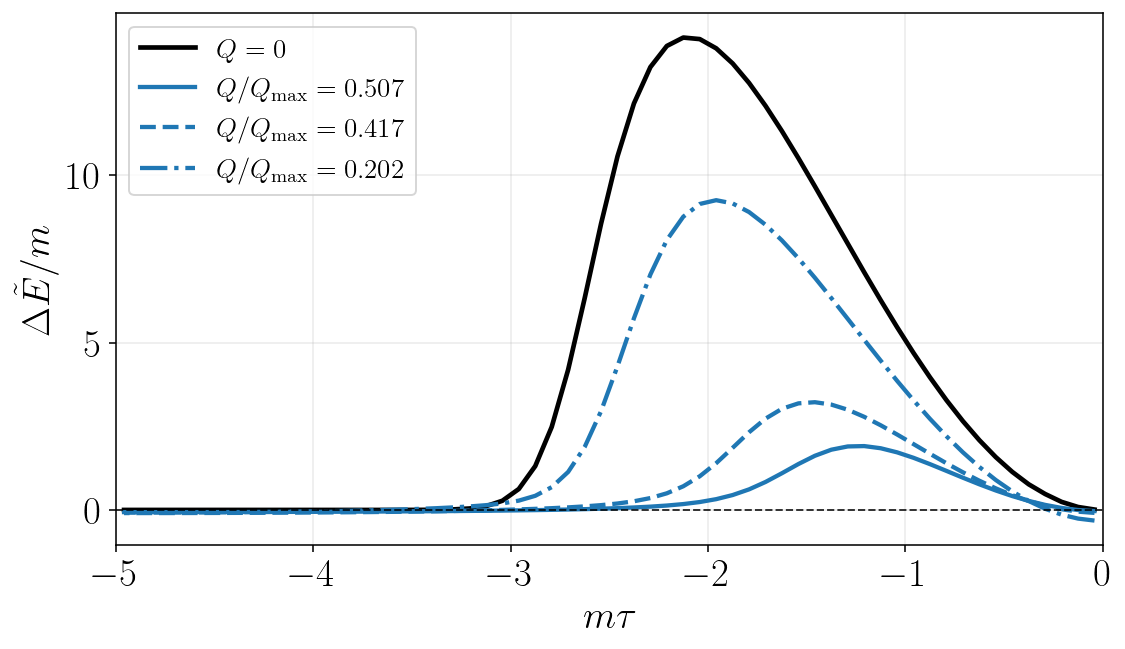

In [50]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))

ax.plot(
    tau_Coleman_Q0,
    np.asarray(E_static_Coleman_Q0_tau, dtype=float),
    color="k",
    lw=2.4,
    label=r"$Q=0$",
)

for rec in multi_static_solutions:
    style = plot_style_static[rec["omega"]]
    q_ratio = float(rec["Q"] / Q_max_static_ref) if np.isfinite(Q_max_static_ref) and abs(Q_max_static_ref) > 1e-30 else np.nan
    ax.plot(
        rec["tau"],
        rec["U_BC"],
        color=style["color"],
        ls=style["ls"],
        lw=2.2,
        label=rf"$Q/Q_{{\max}}={q_ratio:.3f}$",
    )
    rec["Q_ratio"] = q_ratio

ax.axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.8)
ax.set_xlabel(r"$m\tau$", fontsize=20)
ax.set_ylabel(r"$\Delta \tilde E/m$", fontsize=20)
ax.set_xlim(-5, 0)
ax.tick_params(axis="both", which="major", labelsize=20)
ax.legend(loc="best", fontsize=14)
ax.grid(True, alpha=0.25)
fig.tight_layout()

if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_energy_static_multi_omega_vs_Coleman_Q0.pdf",
        bbox_inches="tight",
    )

plt.show()

## 14. Parallel 2D analyses for O(3), O(1), and homogeneous seeds

We now repeat the same full 2D workflow for the remaining seed families:

- build seed,
- visualize seed,
- run Newton + $\eta_0$ scan,
- print diagnostics,
- visualize final 2D solution,
- compare slices to 1D profiles,
- plot $E_{\mathrm{static}}-E_{\mathrm{hom}}$ vs $\tau$.

All cases are processed with the same code path for transparent side-by-side comparison.

In [51]:
def compare_solution_with_1d(r2d: np.ndarray, tau2d: np.ndarray, rho2d: np.ndarray, title: str):
    fig, ax = plt.subplots(1, 3, figsize=(18.0, 4.2))

    im = ax[0].pcolormesh(r2d, tau2d, rho2d.T, shading="auto", cmap="viridis", rasterized=True)
    ax[0].set_xlabel(r"$mr$", fontsize=16)
    ax[0].set_ylabel(r"$m\tau$", fontsize=16)
    ax[0].set_title(fr"$\rho(r,\tau)=\sqrt{{2 \phi \bar\phi}}$", fontsize=15)
    ax[0].invert_yaxis()  # tau-origin at the top
    ax[0].set_box_aspect(1)  # square panel
    ax[0].set_xlim(0, 3)
    ax[0].set_ylim(-3, 0)
    cbar0 = fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
    #cbar0.set_label(r"$\rho/m$", fontsize=15)
    cbar0.ax.tick_params(labelsize=12)

    ax[1].plot(tau2d, rho2d[0, :], color="k", label=r"2D at $r=0$")
    ax[2].plot(r2d, rho2d[:, 0], color="k", label=r"2D at $\tau=0$")
    for d, style in zip((4, 3, 1), ("--", ":", "-.")):
        b = bounces_fixed["omega_ref"][d]
        ax[1].plot(tau2d, np.interp(np.abs(tau2d), b["r"], b["phi"]), style, label=rf"1D $O({d})$")
        ax[2].plot(r2d, np.interp(r2d, b["r"], b["phi"]), style, label=rf"1D $O({d})$")

    ax[1].set_xlabel(r"$m\tau$", fontsize=16)
    ax[1].set_ylabel(r"$\rho/m$", fontsize=16)
    ax[1].set_xlim(-4, 0)
    ax[1].set_title(rf"{title}: Slice at $mr=0$", fontsize=15)
    ax[1].legend(fontsize=11)

    ax[2].set_xlabel(r"$mr$", fontsize=16)
    ax[2].set_ylabel(r"$\rho/m$", fontsize=16)
    ax[2].set_xlim(0, 4)
    ax[2].set_title(rf"{title}: Slice at $m\tau=0$", fontsize=15)
    ax[2].legend(fontsize=11)

    for axi in ax:
        axi.tick_params(axis="both", labelsize=12)

    fig.tight_layout()
    return fig


def run_seed_case(seed_type: str, label: str):
    solver = make_solver(eta0=0.0, verbose=True)
    x0, rho_seed = build_seed(solver, seed_type, profiles_for_seeds)
    r = np.asarray(solver.grid.r, dtype=float)
    tau = np.asarray(solver.grid.tau, dtype=float)

    fig_seed, _ = plot_seed_maps(r, tau, rho_seed, title_prefix=label)
    if CFG["save_figures"]:
        fig_seed.savefig(CFG["figures_dir"] / f"seed_{seed_type}.pdf", bbox_inches="tight")
    plt.show()

    sol, meta = _eta_scan_match_charge_local(
        solver,
        x0,
        Q_TARGET_2D,
        eta_start=0.0,
        d_eta=0.5,
        max_steps=80,
        tol_q=1e-6,
    )

    summary = summarize_solution(sol)
    print(f"\n[{label}] final diagnostics:")
    for k, v in summary.items():
        print(f"  {k}: {v}")
    print(f"  eta0*: {meta.get('eta0', np.nan)}")

    rho_final = solver.rho_map(sol.y, sol.ybar)
    fig_cmp = compare_solution_with_1d(r, tau, rho_final, title=label)
    if CFG["save_figures"]:
        fig_cmp.savefig(CFG["figures_dir"] / f"comparison_{seed_type}.pdf", bbox_inches="tight")
        fig_cmp.savefig(CFG["figures_dir"] / f"solution_{seed_type}.pdf", bbox_inches="tight")
    plt.show()

    static = compute_static_energy_minus_hom_vs_tau(solver, sol.y, sol.ybar)
    fig_st, ax = plt.subplots(figsize=(7.0, 4.2))
    ax.plot(static["tau"], static["delta_E_static"], marker="o", ms=4)
    ax.axhline(0.0, color="k", ls="--", lw=1.2)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$E_{\mathrm{static}}-E_{\mathrm{hom}}$")
    ax.set_title(rf"{label}: static energy diagnostic")
    fig_st.tight_layout()
    if CFG["save_figures"]:
        fig_st.savefig(CFG["figures_dir"] / f"static_energy_{seed_type}.pdf", bbox_inches="tight")
    plt.show()

    return {
        "solver": solver,
        "seed": rho_seed,
        "solution": sol,
        "meta": meta,
        "summary": summary,
        "rho_final": rho_final,
        "static": static,
    }


results_other_seeds = {}


### 14.1 O(3) static seed

This seed embeds the 1D $O(3)$ radial profile in $r$ and keeps it constant in $\tau$. It tests whether a spatially symmetric, time-static initialization converges to the same 2D saddle branch as the O(4)-inspired seed.

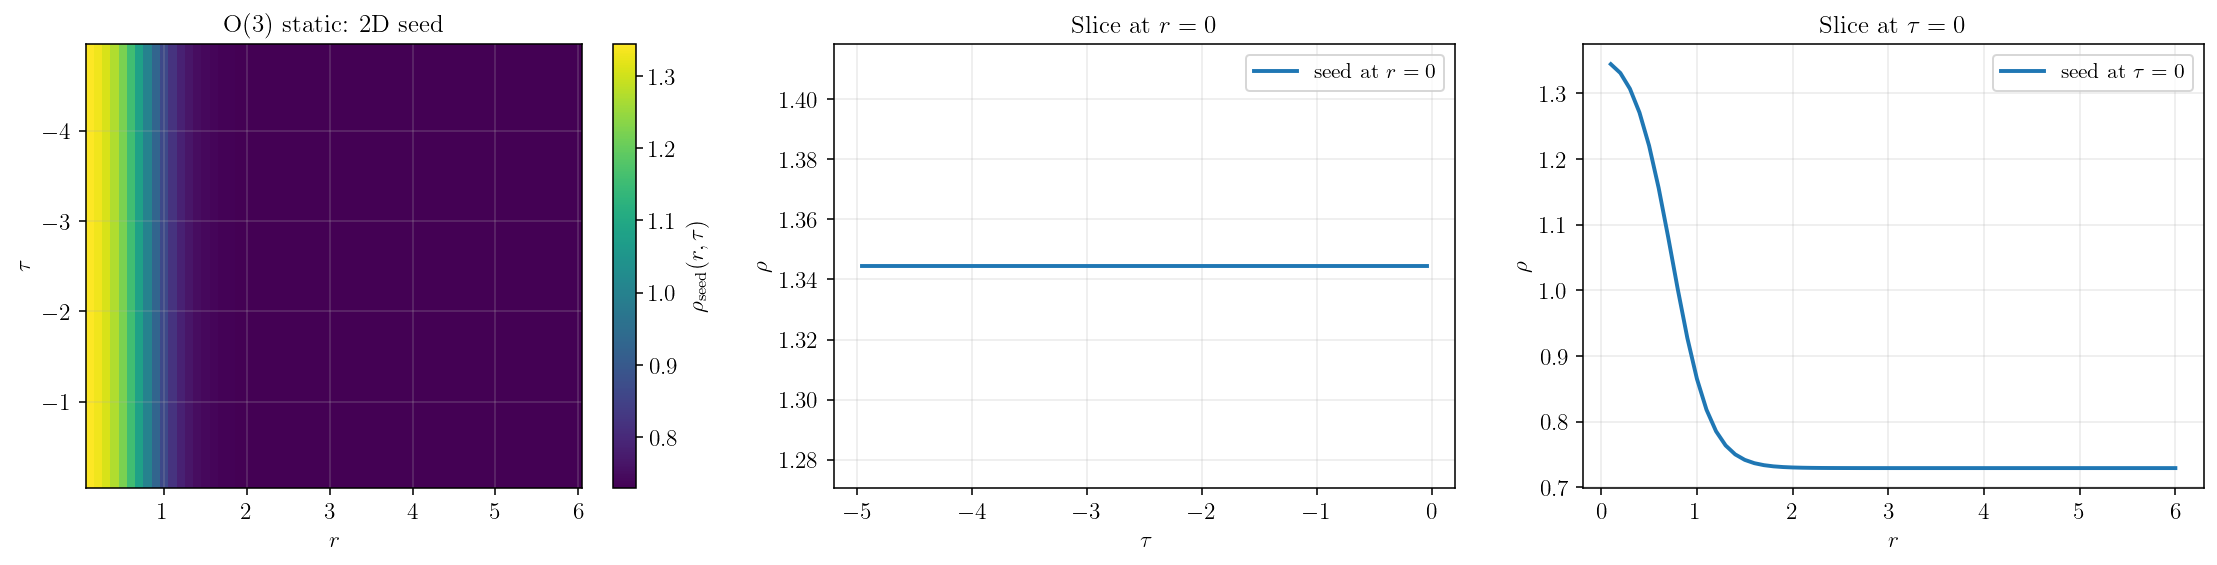

[Targets] eta0 scan references (total observables):
  Q_target_total = 9.14010702e+02
  E_target_total = 3.71899095e+00
[eta-scan] eta=0.000000  Q_total=9.19983466e+02  E_total=-3.65531392e+00  Q_total/Q*= 1.006535  E_total/E*= -0.982878
[eta-scan] eta=-0.500000  Q_total=8.65427228e+02  E_total=4.68223150e+01  Q_total/Q*= 0.946846  E_total/E*= 12.590059
[eta-scan*] eta=-0.053925  Q_total=9.14010702e+02  E_total=2.00325724e+00  Q_total/Q*= 1.000000  E_total/E*= 0.538656

[O(3) static] final diagnostics:
  success: 1.0
  iterations: 2.0
  residual_norm: 7.039298757570014e-13
  Q_tau0: 914.0107024737883
  E_tau0: 2.0032572360695124
  rho0: 0.7291697864840424
  E_hom: 3.7190081666790507
  energy_ratio: 0.5386536265281595
  eta0*: -0.0539245615726776


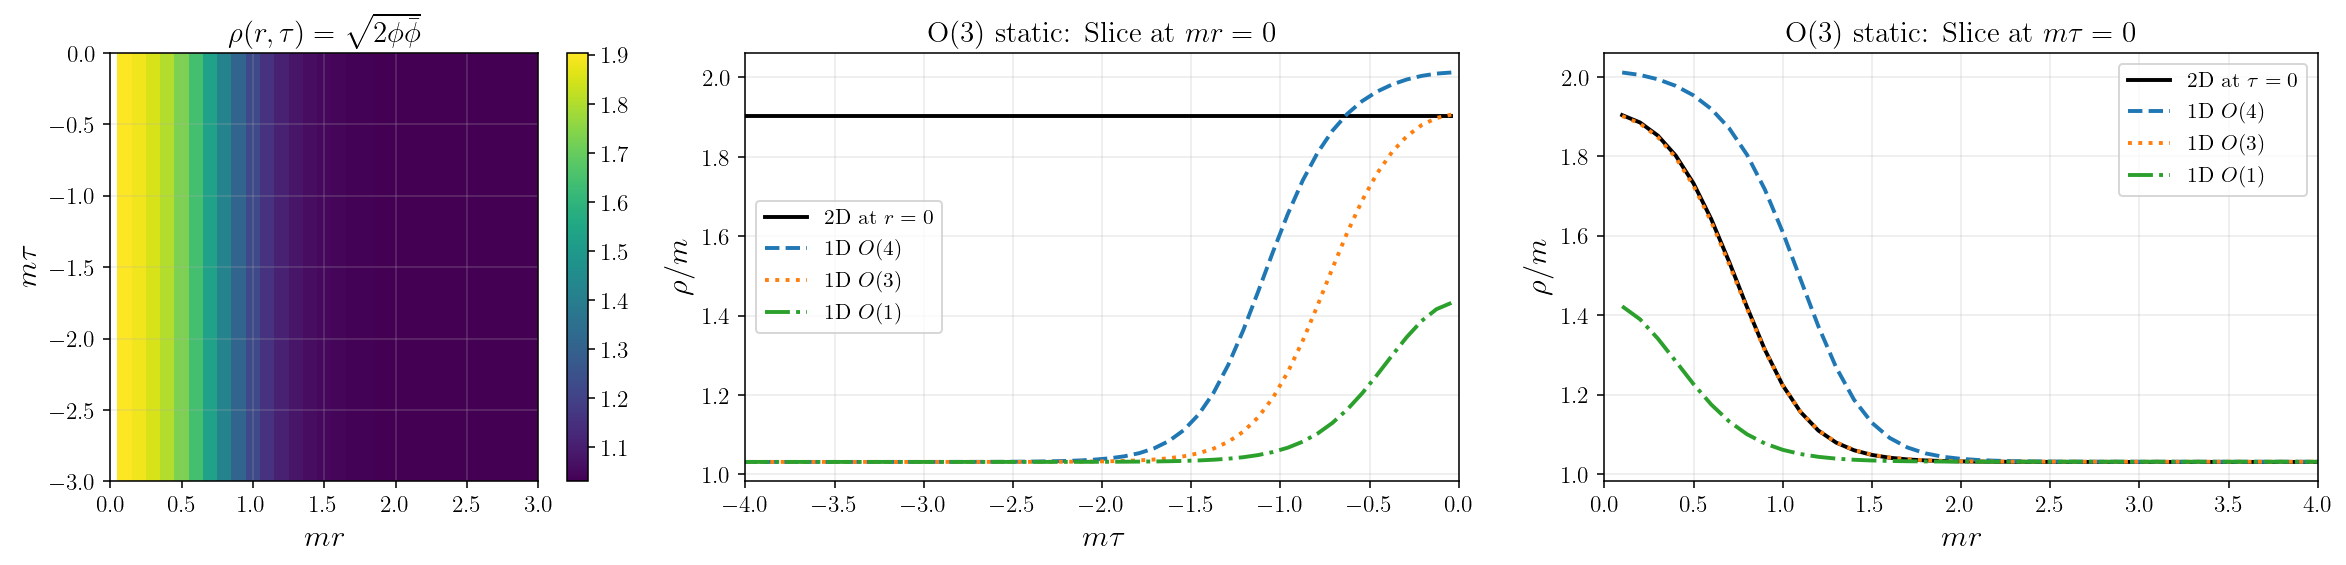

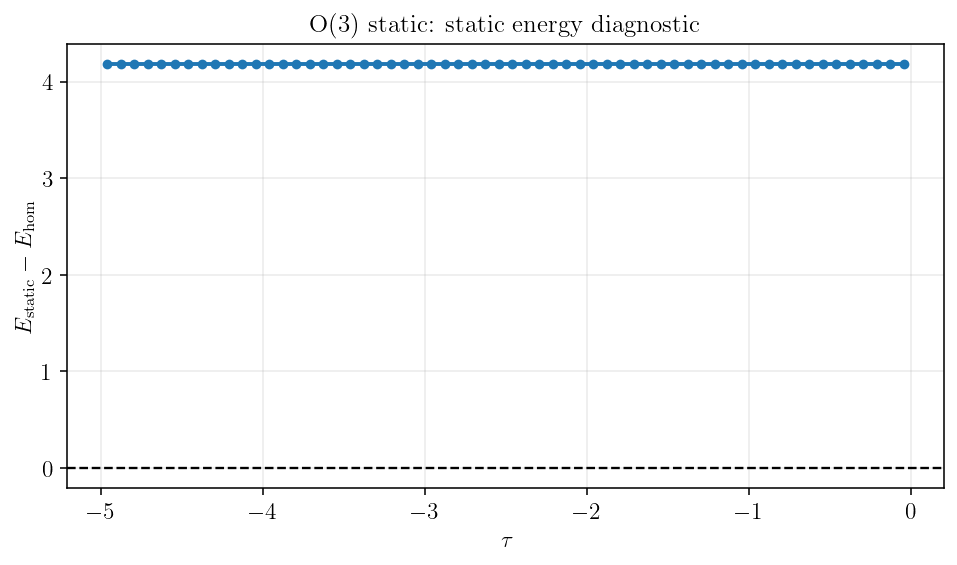

In [52]:
results_other_seeds["O3_static_seed"] = run_seed_case("O3_static_seed", "O(3) static")

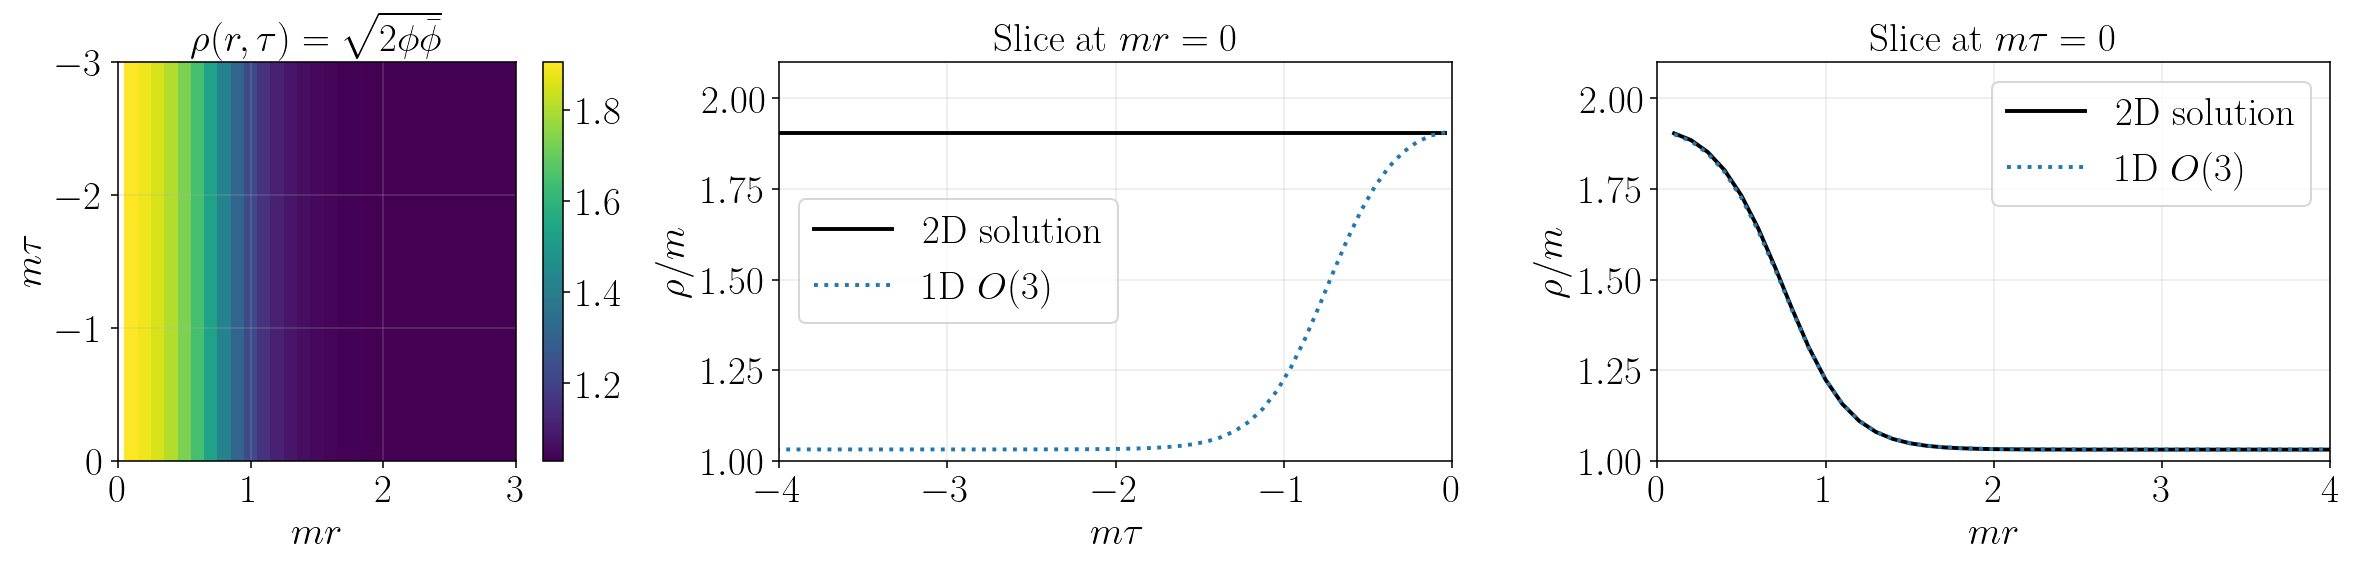

In [53]:
res_o3 = results_other_seeds["O3_static_seed"]
solver_o3 = res_o3["solver"]
sol_o3 = res_o3["solution"]
rho_o3_final = solver_o3.rho_map(sol_o3.y, sol_o3.ybar)
r2d = np.asarray(solver_o3.grid.r, dtype=float)
tau2d = np.asarray(solver_o3.grid.tau, dtype=float)

_FS = 20  # labels, legend, ticks (minimum 14)

fig, ax = plt.subplots(1, 3, figsize=(18.0, 4.2))

im = ax[0].pcolormesh(r2d, tau2d, rho_o3_final.T, shading="auto", cmap="viridis", rasterized=True)
ax[0].set_xlabel(r"$mr$", fontsize=_FS)
ax[0].set_ylabel(r"$m\tau$", fontsize=_FS)
ax[0].set_xlim(0, 3.0)
ax[0].set_ylim(-3.0, 0)
ax[0].set_title(fr"$\rho(r,\tau)=\sqrt{{2 \phi \bar\phi}}$", fontsize=_FS)
ax[0].invert_yaxis()  # tau-origin at the top
ax[0].set_box_aspect(1)  # square panel
cbar0 = fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.ax.tick_params(labelsize=_FS)

# r=0 comparison (1D O(3) seed only; no O(4), O(1))
ax[1].plot(tau2d, rho_o3_final[0, :], color="k", label=r"2D solution")
b3 = bounces_fixed["omega_ref"][3]
ax[1].plot(tau2d, np.interp(np.abs(tau2d), b3["r"], b3["phi"]), ":", label=r"1D $O(3)$")
ax[1].set_xlabel(r"$m\tau$", fontsize=_FS)
ax[1].set_ylabel(r"$\rho/m$", fontsize=_FS)
ax[1].set_xlim(-4.0, 0)
ax[1].set_ylim(1, 2.1)
ax[1].set_title(r"Slice at $mr=0$", fontsize=_FS)
ax[1].legend(loc="center left",fontsize=_FS)

# tau=0 comparison (1D O(3) seed only; no O(4), O(1))
ax[2].plot(r2d, rho_o3_final[:, 0], color="k", label=r"2D solution")
ax[2].plot(r2d, np.interp(r2d, b3["r"], b3["phi"]), ":", label=r"1D $O(3)$")
ax[2].set_xlabel(r"$mr$", fontsize=_FS)
ax[2].set_ylabel(r"$\rho/m$", fontsize=_FS)
ax[2].set_xlim(0, 4.0)
ax[2].set_ylim(1, 2.1)
ax[2].set_title(r"Slice at $m\tau=0$", fontsize=_FS)
ax[2].legend(loc="best", fontsize=_FS)
for axi in ax:
    axi.tick_params(axis="both", labelsize=_FS)

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "o3_static_vs_1d_o3_only_profiles.pdf", bbox_inches="tight")
plt.show()


### 14.2 O(1) tau seed

This seed embeds a 1D profile along $|\tau|$ (constant in $r$), probing a strongly time-structured initialization. The same Newton + $\eta_0$ matching workflow is applied for direct comparison.

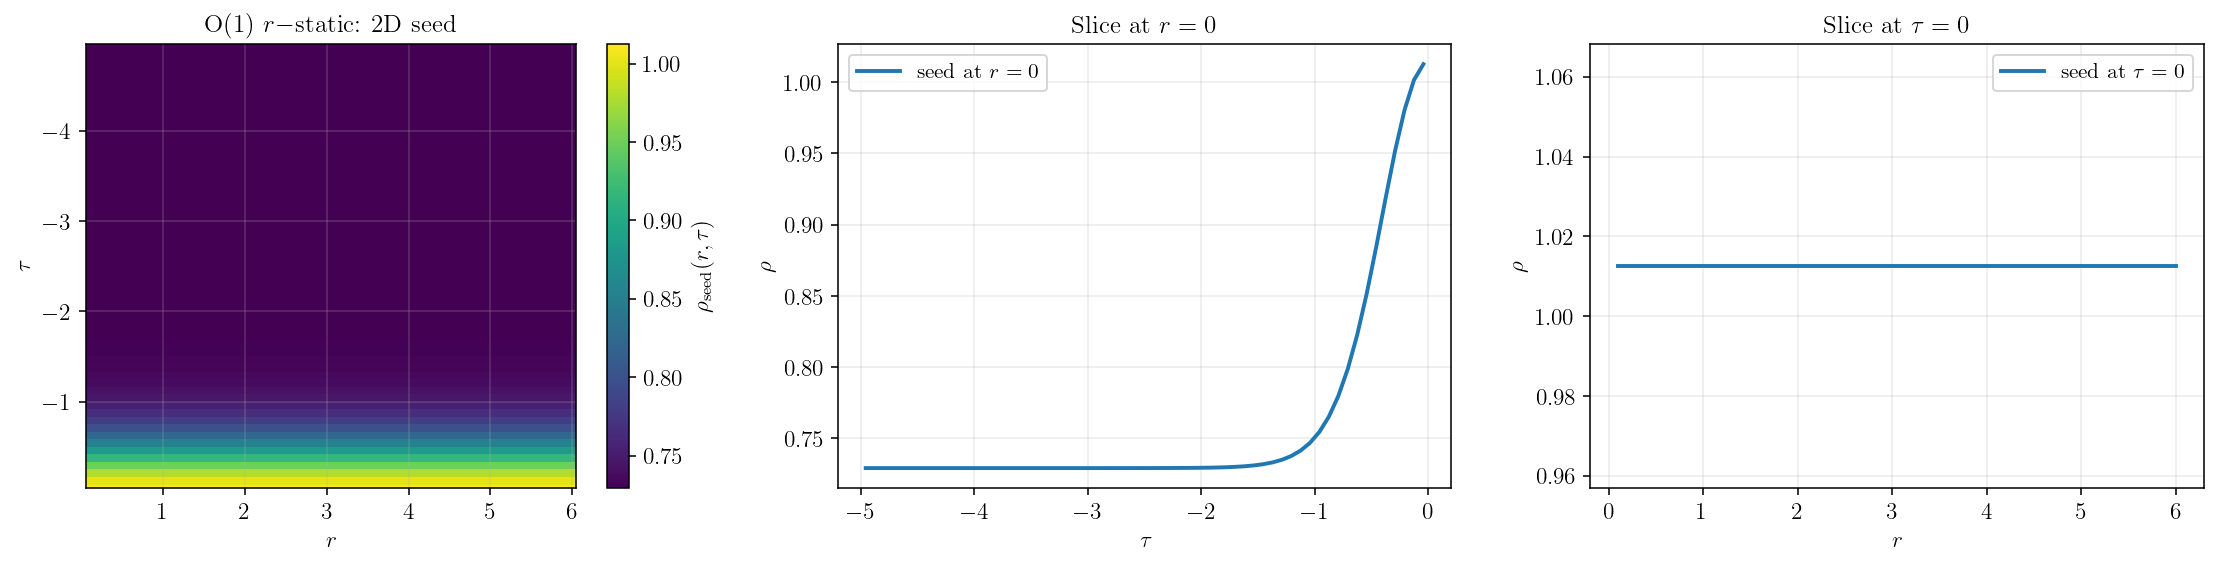

[Targets] eta0 scan references (total observables):
  Q_target_total = 9.14010702e+02
  E_target_total = 3.71899095e+00
[eta-scan] eta=0.000000  Q_total=9.92023816e+02  E_total=-7.61621635e+01  Q_total/Q*= 1.085353  E_total/E*= -20.479255
[eta-scan] eta=-0.500000  Q_total=9.31326889e+02  E_total=-1.61618526e+01  Q_total/Q*= 1.018945  E_total/E*= -4.345763
[eta-scan] eta=-1.000000  Q_total=8.72559064e+02  E_total=3.88846150e+01  Q_total/Q*= 0.954649  E_total/E*= 10.455690
[eta-scan*] eta=-0.645768  Q_total=9.14010702e+02  E_total=3.74400984e-01  Q_total/Q*= 1.000000  E_total/E*= 0.100673

[O(1) $r-$static] final diagnostics:
  success: 1.0
  iterations: 2.0
  residual_norm: 2.6927039667776558e-12
  Q_tau0: 914.0107024736741
  E_tau0: 0.3744009835196824
  rho0: 0.7291697864840424
  E_hom: 3.7190081666790507
  energy_ratio: 0.10067226710448712
  eta0*: -0.6457679131681705


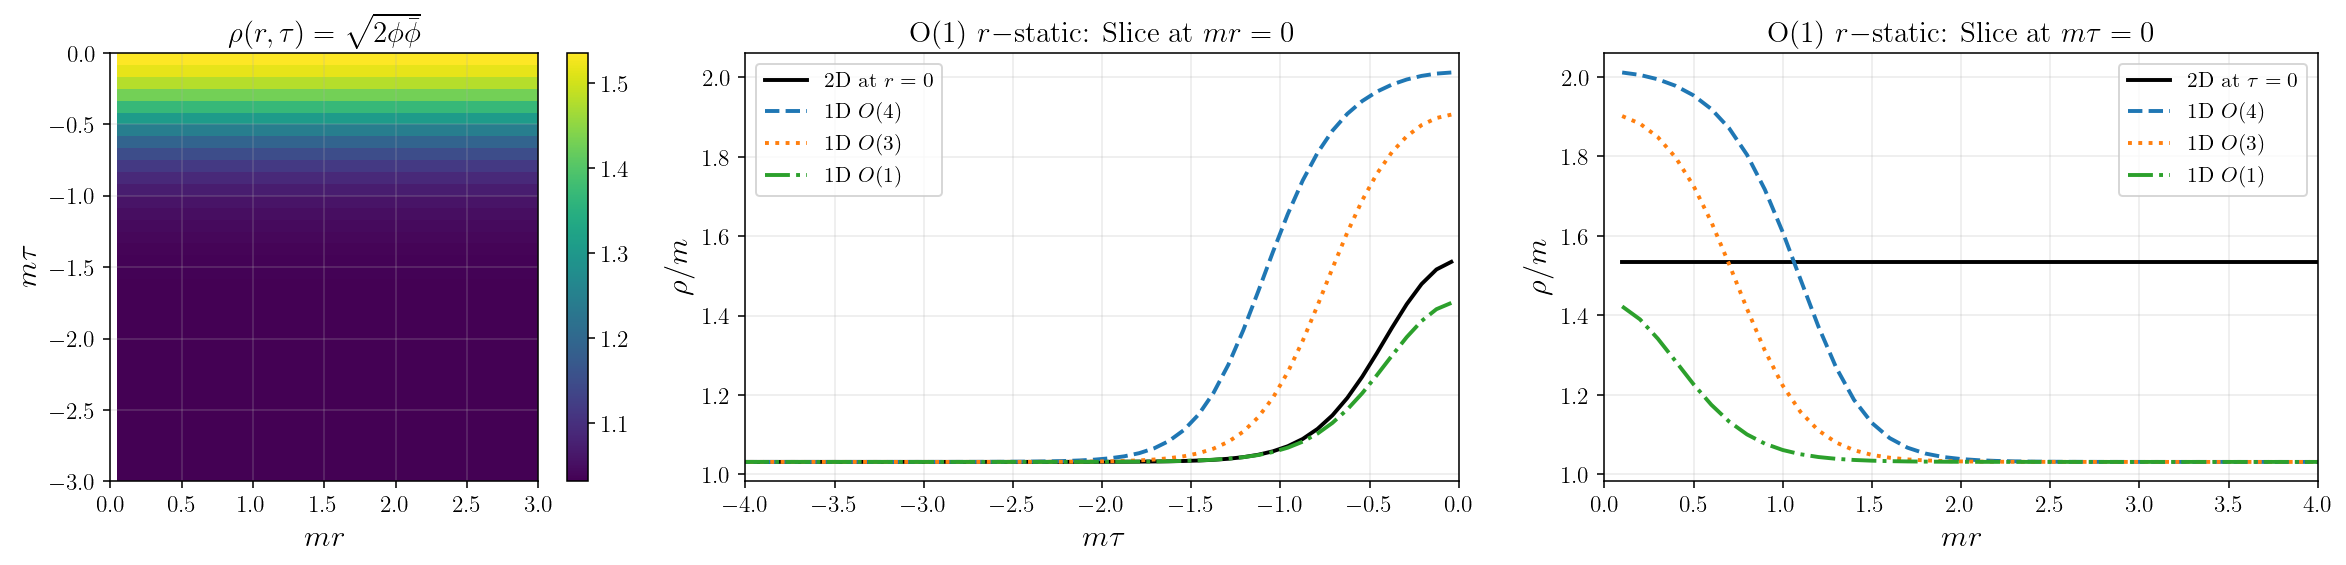

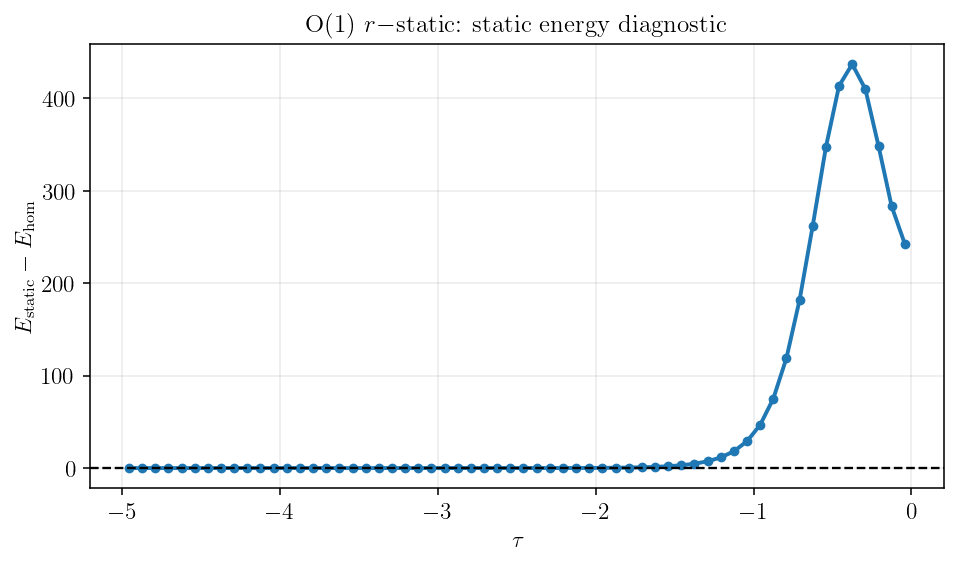

In [54]:
results_other_seeds["O1_tau_seed"] = run_seed_case("O1_tau_seed", r"O(1) $r-$static")

### 14.3 Homogeneous seed

This is the trivial false-vacuum seed. Running the same pipeline clarifies whether Newton remains in the homogeneous basin or reaches a nontrivial branch when combined with $\eta_0$ matching.

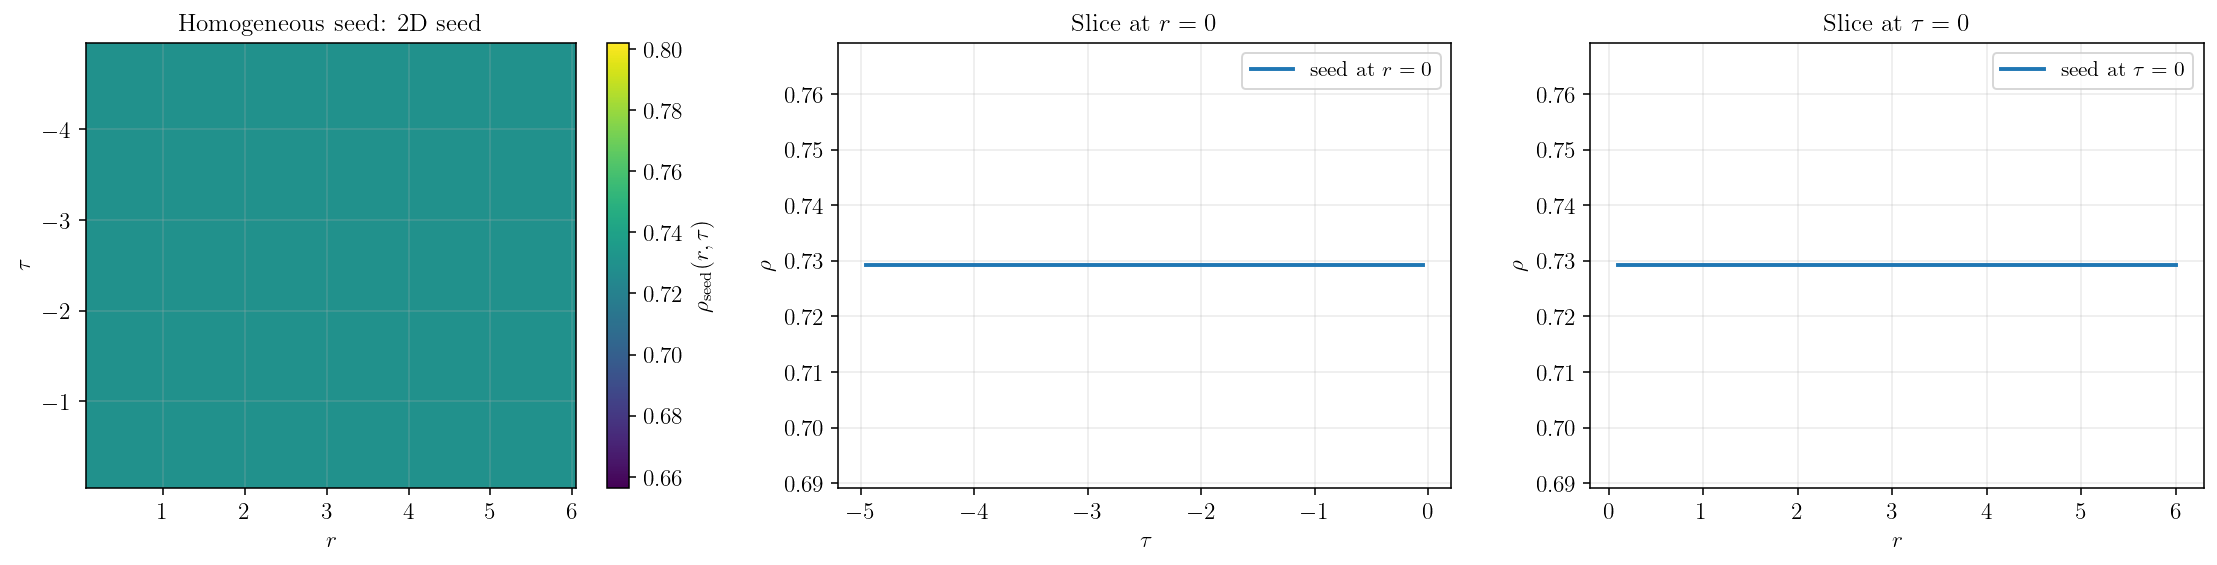

[Targets] eta0 scan references (total observables):
  Q_target_total = 9.14010702e+02
  E_target_total = 3.71899095e+00
[eta-scan] eta=0.000000  Q_total=9.14010702e+02  E_total=3.71899095e+00  Q_total/Q*= 1.000000  E_total/E*= 1.000000

[Homogeneous seed] final diagnostics:
  success: 1.0
  iterations: 1.0
  residual_norm: 3.3416960573310335e-13
  Q_tau0: 914.0107024737799
  E_tau0: 3.7189909486403803
  rho0: 0.7291697864840424
  E_hom: 3.7190081666790507
  energy_ratio: 0.9999953702605914
  eta0*: 0.0


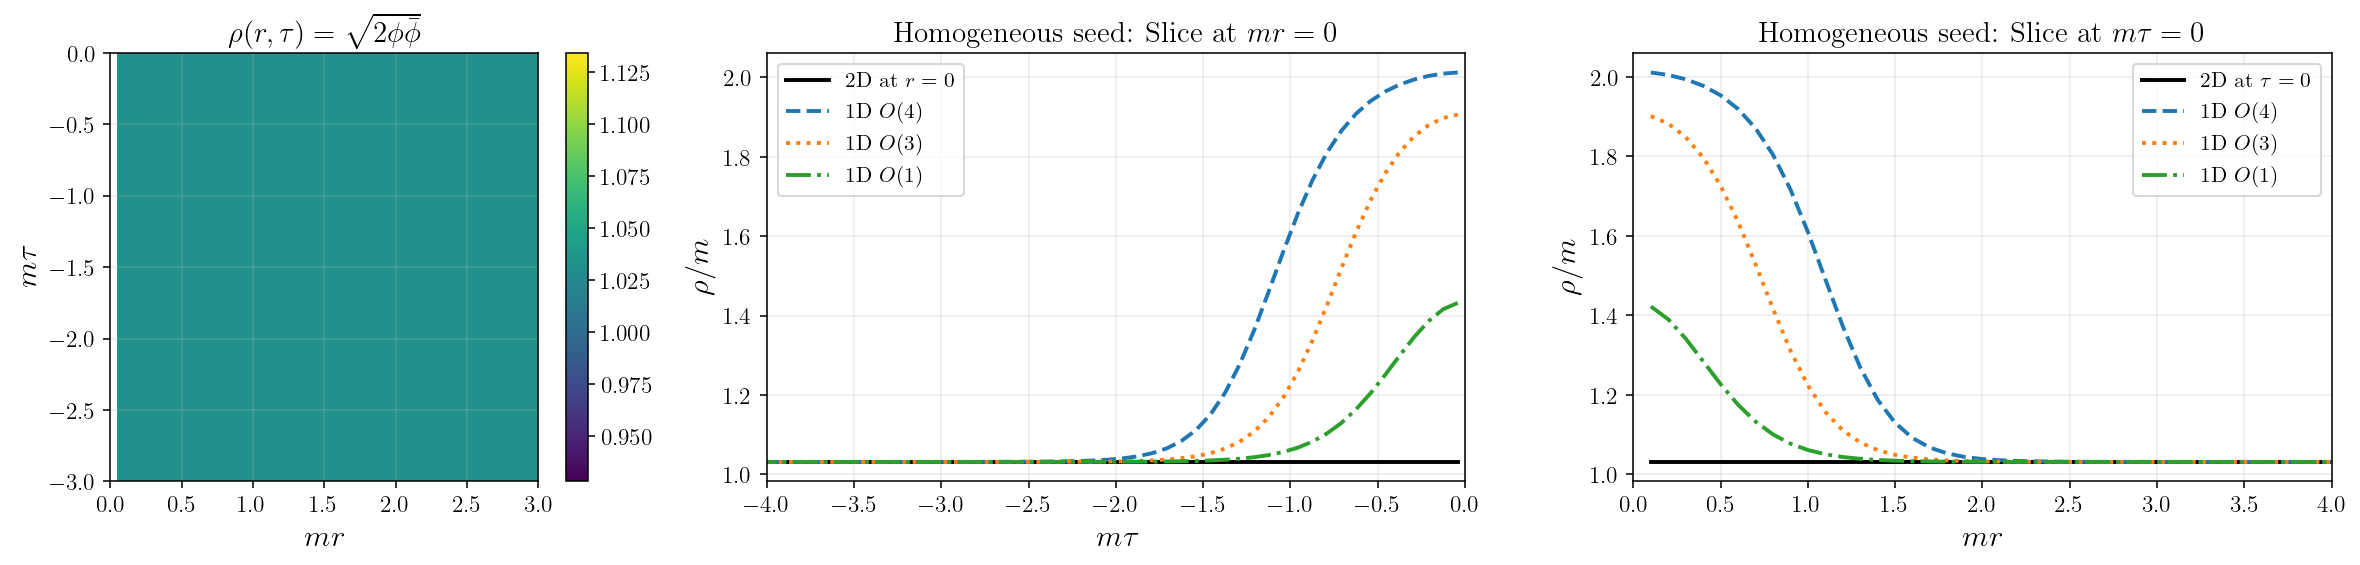

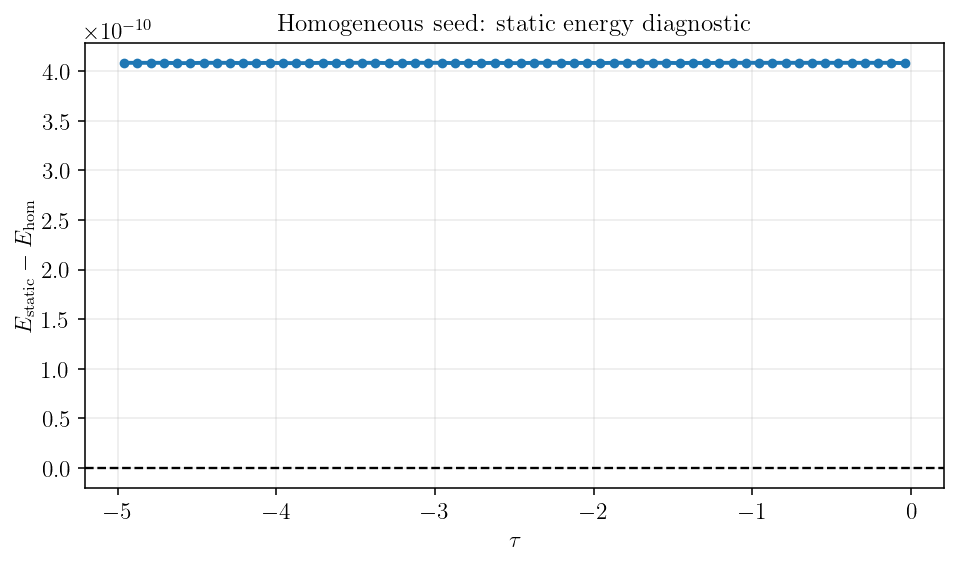

In [55]:
results_other_seeds["homogeneous_seed"] = run_seed_case("homogeneous_seed", "Homogeneous seed")

## 15. Interface contours, charge flow, and dielectric comparison

Using the converged O(4)-seed solution(s), we build symmetry-extended visualizations, study a reduced-$\omega$ contour configuration, and compare the full numerical interface/charge-flow pattern with the sharp thin-wall dielectric ansatz.

### 15.1 Symmetry-extended O(4) map

Even reflection in $r$ and $\tau$ builds the full rectangle $(r,\tau)\in[-r_{\max},r_{\max}]\times[-\beta/2,\beta/2]$.

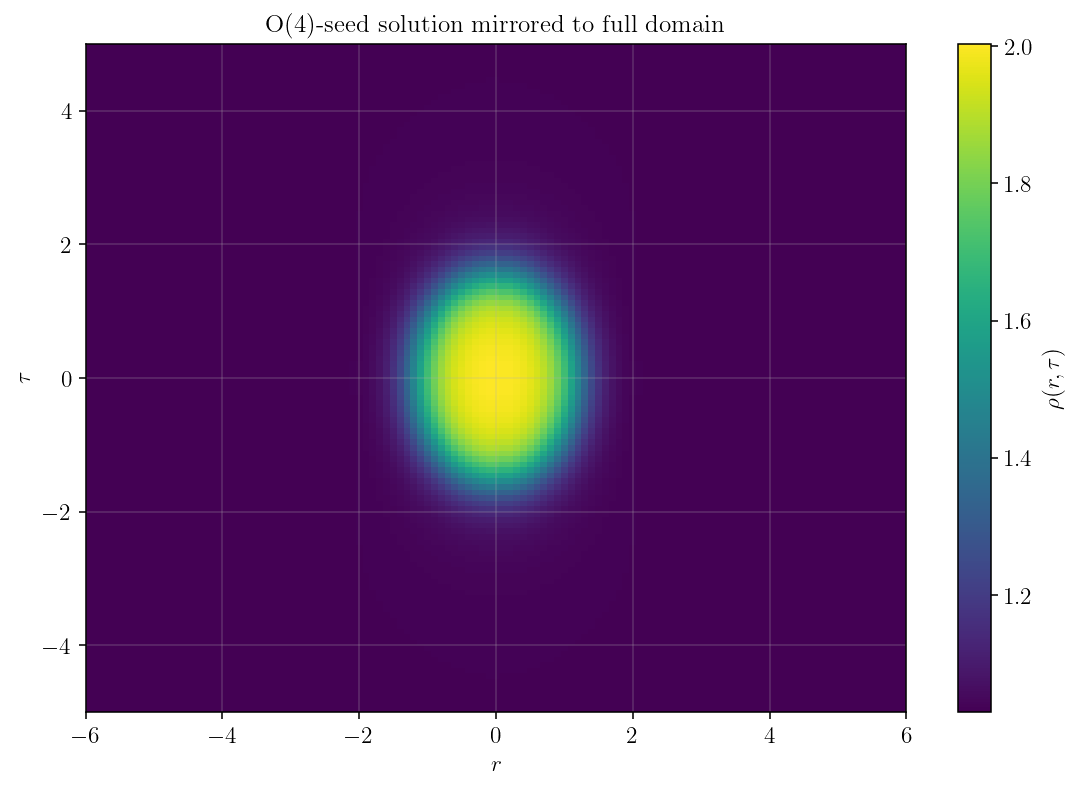

In [56]:
# Symmetry-extended O(4) map on full (r, tau) domain
rho_o4_ref = np.asarray(solver_o4.rho_map(sol_o4.y, sol_o4.ybar), dtype=float)  # (Nr, Ntau_half)
r_half = np.asarray(solver_o4.grid.r, dtype=float).flatten()
tau_half = np.asarray(solver_o4.grid.tau, dtype=float).flatten()

# Build |tau|-ordered half data to apply even reflection in tau
tau_abs = np.abs(tau_half)
ord_tau = np.argsort(tau_abs)
tau_abs_sorted = tau_abs[ord_tau]
rho_tau_sorted = rho_o4_ref[:, ord_tau]

# Full tau in [-beta/2, beta/2], avoiding duplicate tau=0
tau_full = np.concatenate([-tau_abs_sorted[::-1], tau_abs_sorted[1:]])
rho_full_tau = np.concatenate([rho_tau_sorted[:, ::-1], rho_tau_sorted[:, 1:]], axis=1)

# Even reflection in r: r in [-Lr, Lr], avoiding duplicate r=0
r_full = np.concatenate([-r_half[::-1], r_half[1:]])
rho_full = np.concatenate([rho_full_tau[::-1, :], rho_full_tau[1:, :]], axis=0)

R_full, T_full = np.meshgrid(r_full, tau_full, indexing="ij")

fig, ax = plt.subplots(figsize=(8.2, 5.8))
pcm = ax.pcolormesh(R_full, T_full, rho_full, shading="auto", cmap="viridis")
cb = fig.colorbar(pcm, ax=ax)
cb.set_label(r"$\rho(r,\tau)$")

ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\tau$")
ax.set_title(r"O(4)-seed solution mirrored to full domain")
ax.set_xlim(-float(r_half.max()), float(r_half.max()))
ax.set_ylim(-0.5 * float(solver_o4.settings.beta), 0.5 * float(solver_o4.settings.beta))

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "o4_fancy_full_symmetry_map.pdf", bbox_inches="tight")
plt.show()


### 15.2 Reduced-$\omega$ contour study

Newton + $\eta_0$ matching at a lower $\omega$, followed by interface-contour and flow-line plots comparing the final saddle with the direct O(4) seed.

In [57]:
# Newton + eta0 scan at fixed omega=0.2 using the same local workflow:
# seed -> Newton at eta=0 -> step scan (d_eta=0.05) -> brentq refinement.
OMEGA_CONTOUR_RED = 0.25

phi_false_red, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, OMEGA_CONTOUR_RED, verbose=False)
rho0_red = float(phi_false_red / np.sqrt(2.0))

settings_red = Bubble2DSettings(
    Nr=CFG_2D["Nr"],
    Ntau=CFG_2D["Ntau"],
    Lr=CFG_2D["Lr"],
    beta=float(CFG_2D["beta"]),
    omega_ref=float(OMEGA_CONTOUR_RED),
    eta0=0.0,
    rho0=rho0_red,
    newton_tol=CFG_2D["newton_tol"],
    newton_max_iter=CFG_2D["newton_max_iter"],
    damping=CFG_2D["damping"],
    max_backtracks=CFG_2D["max_backtracks"],
    rho0_bracket=CFG_2D["rho0_bracket"],
    complex_saddle=CFG_2D["complex_saddle"],
    verbose=True,
    tau_bc="twisted",
    r_bc="neumann",
    allow_debug_bcs=False,
)
solver_o4_red = Bubble2DSolver(settings_red, U, dU, d2U)

bounce_o4_red = solve_or_load_bounce_1d(
    None,
    MODEL,
    omega=float(OMEGA_CONTOUR_RED),
    d=4,
    rmax=260.0,
    n_grid_points=1000,
    max_iter=180,
    verbose=False,
)
x0_o4_red, _ = build_seed(solver_o4_red, "O4_seed", {"O4": bounce_o4_red})

target_red = compute_targets_tau0_ghost(solver_o4_red, subtract_background_charge=False)
Q_target_red = float(target_red["Q"])

sol_o4_red, meta_o4_red = _eta_scan_match_charge_local(
    solver_o4_red,
    np.asarray(x0_o4_red, dtype=float),
    Q_target_here=Q_target_red,
    eta_start=0.0,
    d_eta=0.05,
    max_steps=120,
    tol_q=1e-6,
    scan_label="omega=0.2",
)

Q_o4_red = float(
    compute_charge_tau0_ghost_2d(
        solver_o4_red,
        sol_o4_red.y,
        sol_o4_red.ybar,
        subtract_background=False,
    )
)

print(f"omega(red)   = {OMEGA_CONTOUR_RED:.3f}")
print(f"eta0*(red)   = {float(meta_o4_red.get('eta0', np.nan)):+.8f}")
print(f"Q(red)       = {Q_o4_red:.10e}")
print(f"Q_target(red)= {Q_target_red:.10e}")


[Targets] eta0 scan references (total observables):
  Q_target_total = 2.26812330e+02
  E_target_total = 4.23995263e+02
[omega=0.2] eta=0.000000  Q_total=2.36486069e+02  E_total=4.21953735e+02  Q_total/Q*= 1.042651  E_total/E*= 0.995185
[omega=0.2] eta=-0.050000  Q_total=2.31808142e+02  E_total=4.23164052e+02  Q_total/Q*= 1.022026  E_total/E*= 0.998040
[omega=0.2] eta=-0.100000  Q_total=2.27127915e+02  E_total=4.24350925e+02  Q_total/Q*= 1.001391  E_total/E*= 1.000839
[omega=0.2] eta=-0.150000  Q_total=2.22445360e+02  E_total=4.25514318e+02  Q_total/Q*= 0.980746  E_total/E*= 1.003583
[omega=0.2*] eta=-0.103371  Q_total=2.26812330e+02  E_total=4.24430090e+02  Q_total/Q*= 1.000000  E_total/E*= 1.001026
omega(red)   = 0.250
eta0*(red)   = -0.10337058
Q(red)       = 2.2681232999e+02
Q_target(red)= 2.2681232999e+02


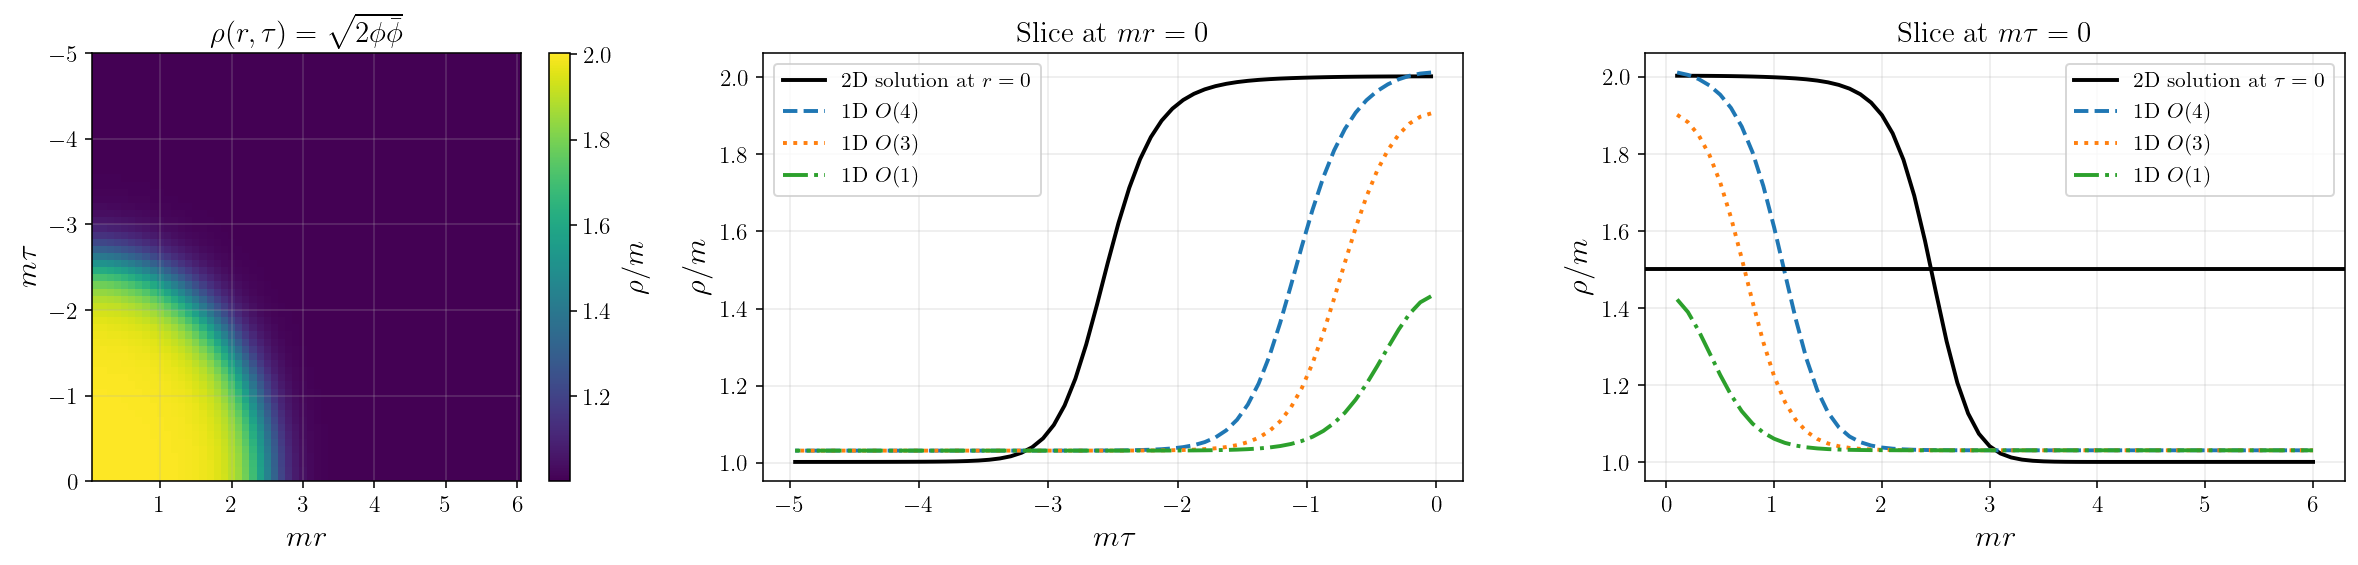

In [58]:
rho_o4_final = solver_o4_red.rho_map(sol_o4_red.y, sol_o4_red.ybar)
r2d = np.asarray(solver_o4_red.grid.r, dtype=float)
tau2d = np.asarray(solver_o4_red.grid.tau, dtype=float)

fig, ax = plt.subplots(1, 3, figsize=(18.0, 4.2))

im = ax[0].pcolormesh(r2d, tau2d, rho_o4_final.T, shading="auto", cmap="viridis", rasterized=True)
ax[0].set_xlabel(r"$mr$", fontsize=16)
ax[0].set_ylabel(r"$m\tau$", fontsize=16)
ax[0].set_title(fr"$\rho(r,\tau)=\sqrt{{2 \phi \bar\phi}}$", fontsize=15)
ax[0].invert_yaxis()  # tau-origin at the top
ax[0].set_box_aspect(1)  # square panel
cbar0 = fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.set_label(r"$\rho/m$", fontsize=15)
cbar0.ax.tick_params(labelsize=12)

# r=0 comparison
ax[1].plot(tau2d, rho_o4_final[0, :], color="k", label=r"2D solution at $r=0$")
for d, style in zip((4, 3, 1), ("--", ":", "-.")):
    b = bounces_fixed["omega_ref"][d]
    ax[1].plot(tau2d, np.interp(np.abs(tau2d), b["r"], b["phi"]), style, label=rf"1D $O({d})$")
ax[1].set_xlabel(r"$m\tau$", fontsize=16)
ax[1].set_ylabel(r"$\rho/m$", fontsize=16)
ax[1].set_title(r"Slice at $mr=0$", fontsize=15)
ax[1].legend(fontsize=11)

# tau=0 comparison
ax[2].plot(r2d, rho_o4_final[:, 0], color="k", label=r"2D solution at $\tau=0$")
for d, style in zip((4, 3, 1), ("--", ":", "-.")):
    b = bounces_fixed["omega_ref"][d]
    ax[2].plot(r2d, np.interp(r2d, b["r"], b["phi"]), style, label=rf"1D $O({d})$")
ax[2].axhline((rho_o4_final[0, 0] + rho_o4_final[-1, 0]) / 2, color="k")
ax[2].set_xlabel(r"$mr$", fontsize=16)
ax[2].set_ylabel(r"$\rho/m$", fontsize=16)
ax[2].set_title(r"Slice at $m\tau=0$", fontsize=15)
ax[2].legend(fontsize=11)
for axi in ax:
    axi.tick_params(axis="both", labelsize=12)

fig.tight_layout()
plt.show()

In [59]:
# Force dashed O(4) seed to be built and bound at omega=0 before contour plotting
phi_false_seed0, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, 0.0, verbose=False)
rho0_seed0 = float(phi_false_seed0 / np.sqrt(2.0))

settings_seed0 = Bubble2DSettings(
    Nr=CFG_2D["Nr"],
    Ntau=CFG_2D["Ntau"],
    Lr=CFG_2D["Lr"],
    beta=float(CFG_2D["beta"]),
    omega_ref=0.0,
    eta0=0.0,
    rho0=rho0_seed0,
    newton_tol=CFG_2D["newton_tol"],
    newton_max_iter=CFG_2D["newton_max_iter"],
    damping=CFG_2D["damping"],
    max_backtracks=CFG_2D["max_backtracks"],
    rho0_bracket=CFG_2D["rho0_bracket"],
    complex_saddle=CFG_2D["complex_saddle"],
    verbose=False,
    tau_bc="twisted",
    r_bc="neumann",
    allow_debug_bcs=False,
)
solver_o4_seed0 = Bubble2DSolver(settings_seed0, U, dU, d2U)

bounce_o4_seed0 = solve_or_load_bounce_1d(
    None,
    MODEL,
    omega=0.0,
    d=4,
    rmax=260.0,
    n_grid_points=1000,
    max_iter=180,
    verbose=False,
)

x0_o4_seed0, _ = build_seed(solver_o4_seed0, "O4_seed", {"O4": bounce_o4_seed0})

# Bind canonical dashed-seed variables used by the next contour cell.
solver_o4_seed = solver_o4_seed0
x0_o4_seed = np.asarray(x0_o4_seed0, dtype=float)

print("Dashed O(4) seed forced to omega=0 and bound to solver_o4_seed/x0_o4_seed")


Dashed O(4) seed forced to omega=0 and bound to solver_o4_seed/x0_o4_seed


Dashed-seed solver omega_ref = 0.000000 (expected 0.0)


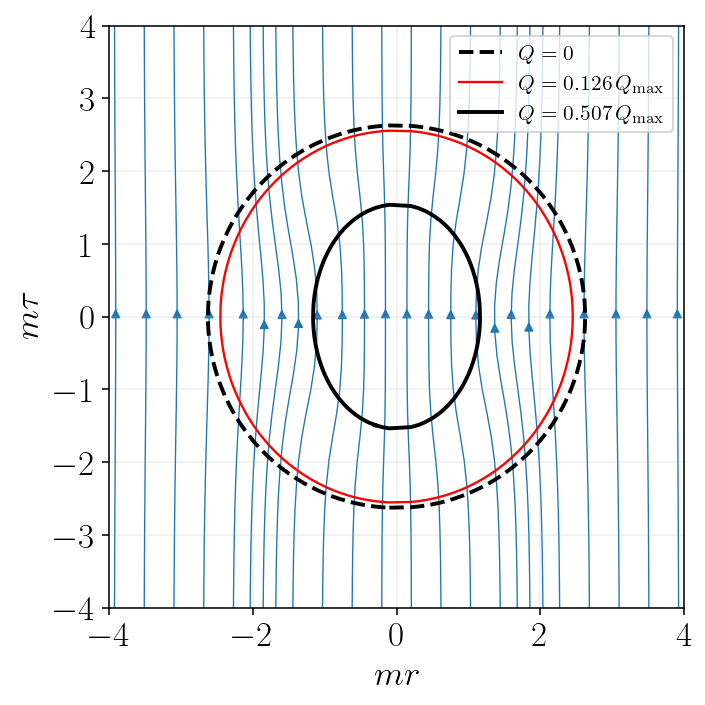

tau slice used for interface = tau[0] = -4.16666667e-02
rho_out_vac(ref)   = 1.03120180e+00
rho_out_vac(red)   = 1.00136672e+00
rho_out_num(sol)   = 1.03076176e+00
rho_out_num(seed)  = 1.00000002e+00
rho_out_num(red)   = 1.00117686e+00
level_sol  = (rho_in_sol + rho_out_num(sol))/2  = 1.51688069e+00
level_seed = (rho_in_seed + rho_out_num(seed))/2 = 1.49949413e+00
level_red  = (rho_in_red + rho_out_num(red))/2   = 1.50185445e+00
level_red_direct_tau0 = 1.501854454083077
Q_black (raw) = 9.140107024737e+02
Q_red   (raw) = 2.268123299868e+02
Q_seed0 (raw) = 0.000000000000e+00
Q_max source  = 2D target at omega=0.999*OMEGA_MAX=1.340081
omega_max for Q_max (1D scan) = 1.340081171548e+00
Q_max from 1D omega_max       = 1.803843276761e+03
Q_max         = 1.803843276761e+03
Q_black/Q_max = 0.50670184
Q_red/Q_max   = 0.12573838
Q_black/Q_red = 4.02981047
Q_red/Q_black = 0.24815063
Q_max from black? False
Q_max from red?   False
idx_qmax in candidates = 0 (n_candidates=3)
max candidate value    

In [60]:
# Interface contour comparison: final O(4) solution vs direct O(4) seed
# Charge-flow lines are plotted from the current components
#   j_tau = Re(phibar * d_tau phi - phi * d_tau phibar)
#   j_r   = Re(phibar * d_r   phi - phi * d_r   phibar)

# --- final O(4) solution map (reference omega) ---
rho_sol_half = np.asarray(solver_o4.rho_map(sol_o4.y, sol_o4.ybar), dtype=float)
r_half = np.asarray(solver_o4.grid.r, dtype=float).flatten()
tau_half = np.asarray(solver_o4.grid.tau, dtype=float).flatten()

# --- direct O(4) seed map rebuilt in physical rho units (omega=0) ---
y_seed_o4, ybar_seed_o4 = solver_o4_seed0.unpack(np.asarray(x0_o4_seed0, dtype=float))
rho_seed_half = np.asarray(solver_o4_seed0.rho_map(y_seed_o4, ybar_seed_o4), dtype=float)
print(f"Dashed-seed solver omega_ref = {float(solver_o4_seed0.omega):.6f} (expected 0.0)")
if not np.isclose(float(solver_o4_seed0.omega), 0.0, atol=1e-14):
    raise RuntimeError("Dashed seed is not at omega=0.0")

# --- additional solved configuration at omega=0.2 (computed in previous cell) ---
rho_red_half = np.asarray(solver_o4_red.rho_map(sol_o4_red.y, sol_o4_red.ybar), dtype=float)

# ============================================================
# Build charge-current components (final O(4) solution only)
# ============================================================
y_sol = np.asarray(sol_o4.y)
ybar_sol = np.asarray(sol_o4.ybar)

phi_sol, phibar_sol = solver_o4.phi(y_sol, ybar_sol)

omega_sol = float(solver_o4.omega)
rho0_sol = float(solver_o4.rho0)
dtau_sol = float(getattr(solver_o4, "dt", getattr(solver_o4.grid, "dtau", None)))

Nr, Nt = y_sol.shape

# --- tau component of the current ---
j_tau_half = np.zeros_like(rho_sol_half, dtype=float)

inv_r = np.zeros_like(r_half, dtype=float)
inv_r[r_half != 0.0] = 1.0 / r_half[r_half != 0.0]

for i_tau in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver_o4._tau_neighbors(y_sol, ybar_sol, i_tau)

    if len(tau_half) >= 2 and (tau_half[1] > tau_half[0]):
        y_t = (y_ip1 - y_im1) / (2.0 * dtau_sol)
        yb_t = (yb_ip1 - yb_im1) / (2.0 * dtau_sol)
    else:
        y_t = (y_im1 - y_ip1) / (2.0 * dtau_sol)
        yb_t = (yb_im1 - yb_ip1) / (2.0 * dtau_sol)

    y_tot = y_sol[:, i_tau] + r_half * rho0_sol
    yb_tot = ybar_sol[:, i_tau] + r_half * rho0_sol

    exp_p = np.exp(+omega_sol * tau_half[i_tau]) * inv_r
    exp_m = np.exp(-omega_sol * tau_half[i_tau]) * inv_r

    phi_tau = exp_p * (y_t + omega_sol * y_tot)
    phibar_tau = exp_m * (yb_t - omega_sol * yb_tot)

    j_tau_half[:, i_tau] = (phibar_sol[:, i_tau] * phi_tau - phi_sol[:, i_tau] * phibar_tau).real

# --- radial component of the current ---
j_r_half = np.zeros_like(rho_sol_half, dtype=float)

for i_tau in range(Nt):
    dphi_dr = np.gradient(phi_sol[:, i_tau], r_half, edge_order=2)
    dphibar_dr = np.gradient(phibar_sol[:, i_tau], r_half, edge_order=2)

    # Regularity at r = 0
    dphi_dr[0] = 0.0
    dphibar_dr[0] = 0.0

    j_r_half[:, i_tau] = (phibar_sol[:, i_tau] * dphi_dr - phi_sol[:, i_tau] * dphibar_dr).real

# ============================================================
# Helpers to mirror scalar maps and current components
# ============================================================
def _mirror_full_domain_scalar(r_vec, tau_vec, field_half):
    tau_abs = np.abs(np.asarray(tau_vec, dtype=float).flatten())
    ord_tau = np.argsort(tau_abs)
    tau_abs_sorted = tau_abs[ord_tau]
    field_tau_sorted = np.asarray(field_half, dtype=float)[:, ord_tau]

    tau_full_loc = np.concatenate([-tau_abs_sorted[::-1], tau_abs_sorted[1:]])
    field_full_tau_loc = np.concatenate([field_tau_sorted[:, ::-1], field_tau_sorted[:, 1:]], axis=1)

    r_loc = np.asarray(r_vec, dtype=float).flatten()
    r_full_loc = np.concatenate([-r_loc[::-1], r_loc[1:]])
    field_full_loc = np.concatenate([field_full_tau_loc[::-1, :], field_full_tau_loc[1:, :]], axis=0)

    return r_full_loc, tau_full_loc, field_full_loc


def _mirror_full_domain_current(r_vec, tau_vec, jr_half, jtau_half):
    """
    Mirror a current field from the half-domain r>=0 onto the full domain.

    Parities used:
      - under r -> -r:     j_r is odd,  j_tau is even
      - under tau -> -tau: j_r is even, j_tau is even

    These are the natural choices for the symmetric bounce visualization.
    """
    tau_abs = np.abs(np.asarray(tau_vec, dtype=float).flatten())
    ord_tau = np.argsort(tau_abs)
    tau_abs_sorted = tau_abs[ord_tau]

    jr_tau_sorted = np.asarray(jr_half, dtype=float)[:, ord_tau]
    jtau_tau_sorted = np.asarray(jtau_half, dtype=float)[:, ord_tau]

    tau_full_loc = np.concatenate([-tau_abs_sorted[::-1], tau_abs_sorted[1:]])

    # even under tau reflection
    jr_full_tau_loc = np.concatenate([jr_tau_sorted[:, ::-1], -jr_tau_sorted[:, 1:]], axis=1)
    jtau_full_tau_loc = np.concatenate([jtau_tau_sorted[:, ::-1], jtau_tau_sorted[:, 1:]], axis=1)
    #jr_full_tau_loc   = np.concatenate([ jr_tau_sorted[:, ::-1], jr_tau_sorted[:, 1:]], axis=1)
    #jtau_full_tau_loc = np.concatenate([-jtau_tau_sorted[:, ::-1], jtau_tau_sorted[:, 1:]], axis=1)

    r_loc = np.asarray(r_vec, dtype=float).flatten()
    r_full_loc = np.concatenate([-r_loc[::-1], r_loc[1:]])

    # j_r odd under r reflection, j_tau even under r reflection
    jr_full_loc = np.concatenate([-jr_full_tau_loc[::-1, :], jr_full_tau_loc[1:, :]], axis=0)
    jtau_full_loc = np.concatenate([jtau_full_tau_loc[::-1, :], jtau_full_tau_loc[1:, :]], axis=0)

    return r_full_loc, tau_full_loc, jr_full_loc, jtau_full_loc


# --- mirrored full-domain maps ---
r_full_sol, tau_full_sol, rho_full_sol = _mirror_full_domain_scalar(r_half, tau_half, rho_sol_half)
r_full_seed, tau_full_seed, rho_full_seed = _mirror_full_domain_scalar(r_half, tau_half, rho_seed_half)
r_full_red, tau_full_red, rho_full_red = _mirror_full_domain_scalar(r_half, tau_half, rho_red_half)
r_full_j, tau_full_j, jr_full_sol, jtau_full_sol = _mirror_full_domain_current(r_half, tau_half, j_r_half, j_tau_half)

# ============================================================
# Mid-level thresholds for the interface
# Same construction for all curves: center value + outer tail at tau~0.
# ============================================================
# Use the same convention as the rest of this notebook: tau=0 is column 0.
idx_tau0 = 0

rho_out_ref_vac, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, OMEGA_REF, verbose=False)
rho_out_red_vac, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, float(OMEGA_CONTOUR_RED), verbose=False)
rho_out_ref_vac = float(rho_out_ref_vac)
rho_out_red_vac = float(rho_out_red_vac)

def _interface_level_from_profile(rho_half_map: np.ndarray) -> tuple[float, float, float]:
    # Same direct construction requested by user:
    # level = (rho(0, tau~0) + rho(r_max, tau~0))/2
    rho_in = float(rho_half_map[0, idx_tau0])
    rho_out = float(rho_half_map[-1, idx_tau0])
    lvl = 0.5 * (rho_in + rho_out)

    # Keep level strictly inside numerical range to avoid edge/corner artifacts.
    vmin = float(np.min(rho_half_map))
    vmax = float(np.max(rho_half_map))
    span = max(vmax - vmin, 1e-14)
    lvl = float(np.clip(lvl, vmin + 1e-6 * span, vmax - 1e-6 * span))
    return rho_in, rho_out, lvl

rho_in_sol, rho_out_sol_num, level_sol = _interface_level_from_profile(rho_sol_half)
rho_in_seed, rho_out_seed_num, level_seed = _interface_level_from_profile(rho_seed_half)
rho_in_red, rho_out_red_num, level_red = _interface_level_from_profile(rho_red_half)

# Q/Q_max labels for legend
Q_black = float(compute_charge_tau0_ghost_2d(solver_o4, sol_o4.y, sol_o4.ybar, subtract_background=False))
Q_red = float(compute_charge_tau0_ghost_2d(solver_o4_red, sol_o4_red.y, sol_o4_red.ybar, subtract_background=False))

# Optional diagnostic charge from the direct O(4) seed map
try:
    Q_seed0 = float(compute_charge_tau0_ghost_2d(solver_o4_seed0, y_seed_o4, ybar_seed_o4, subtract_background=False))
except Exception:
    Q_seed0 = np.nan

# Use the same Q_max normalization as the static-barrier plots above.
# Preferred source: Q_MAX_STATIC_REF, inferred from the OMEGA_MAX cell via _infer_static_qmax_ref().
if "Q_MAX_STATIC_REF" not in globals() or not np.isfinite(Q_MAX_STATIC_REF):
    if "_infer_static_qmax_ref" in globals():
        Q_MAX_STATIC_REF, Q_MAX_STATIC_REF_SOURCE = _infer_static_qmax_ref()
    else:
        Q_MAX_STATIC_REF = np.nan
        Q_MAX_STATIC_REF_SOURCE = "unavailable"

Q_max_from_1d_scan = float(Q_MAX_STATIC_REF) if np.isfinite(Q_MAX_STATIC_REF) else np.nan
omega_max_source = globals().get("Q_MAX_STATIC_REF_SOURCE", "Q_MAX_STATIC_REF")
omega_max_for_qmax = float(0.999 * OMEGA_MAX) if "OMEGA_MAX" in globals() and np.isfinite(float(OMEGA_MAX)) else np.nan

Q_max_candidates = []
if np.isfinite(Q_max_from_1d_scan):
    Q_max_candidates.append(float(Q_max_from_1d_scan))
Q_max_candidates.extend([Q_black, Q_red])

if np.isfinite(Q_max_from_1d_scan):
    Q_max = float(max(Q_max_from_1d_scan, 1e-30))
else:
    Q_max = float(np.nanmax(np.asarray(Q_max_candidates, dtype=float))) if len(Q_max_candidates) else 1.0
    Q_max = max(Q_max, 1e-30)

qratio_black = Q_black / Q_max
qratio_red = Q_red / Q_max

# Extra diagnostics to check when Q_black/Q_max is exactly 1 by construction
Q_candidates_arr = np.asarray(Q_max_candidates, dtype=float)
idx_qmax = int(np.nanargmax(Q_candidates_arr)) if Q_candidates_arr.size else -1
qmax_from_black = bool(np.isclose(Q_max, Q_black, rtol=1e-12, atol=1e-14))
qmax_from_red = bool(np.isclose(Q_max, Q_red, rtol=1e-12, atol=1e-14))
qratio_black_over_red = Q_black / max(abs(Q_red), 1e-30)
qratio_red_over_black = Q_red / max(abs(Q_black), 1e-30)

# ============================================================
# Streamplot requires equally spaced x/y grids:
# interpolate current field to a uniform (r, tau) mesh.
# ============================================================
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter

# Upsample to a finer uniform mesh for smoother streamlines.
upsample_factor = 4
nr_uni = max(140, int(upsample_factor * len(r_full_j)))
nt_uni = max(140, int(upsample_factor * len(tau_full_j)))

r_uni = np.linspace(float(r_full_j.min()), float(r_full_j.max()), nr_uni)
tau_uni = np.linspace(float(tau_full_j.min()), float(tau_full_j.max()), nt_uni)

# Cubic interpolation on (r, tau) and then a light Gaussian smoothing.
jr_spline = RectBivariateSpline(r_full_j, tau_full_j, jr_full_sol, kx=3, ky=3, s=0.0)
jtau_spline = RectBivariateSpline(r_full_j, tau_full_j, jtau_full_sol, kx=3, ky=3, s=0.0)

# RectBivariateSpline returns shape (Nr, Nt); streamplot expects (Nt, Nr).
jr_uni = jr_spline(r_uni, tau_uni).T
jtau_uni = jtau_spline(r_uni, tau_uni).T

sigma_smooth = 0.8
jr_uni = gaussian_filter(jr_uni, sigma=sigma_smooth, mode="nearest")
jtau_uni = gaussian_filter(jtau_uni, sigma=sigma_smooth, mode="nearest")

jmag_uni = np.sqrt(jr_uni**2 + jtau_uni**2)
jmag_max = float(np.max(jmag_uni)) if jmag_uni.size else 0.0

# Avoid huge linewidth contrast while keeping visible fine structures.
if jmag_max > 0.0:
    lw_stream = 0.55 + 1.35 * (jmag_uni / jmag_max) ** 0.7
else:
    lw_stream = 0.9

# ============================================================
# Plot: interfaces + charge-flow lines
# ============================================================
fig, ax = plt.subplots(figsize=(5.2, 5.2))

def _estimate_wall_radius_tau0(r_pos, rho_half_map, level, idx_tau0_here):
    """Estimate bubble-wall radius from tau~0 slice via first outward level crossing."""
    r_pos = np.asarray(r_pos, dtype=float)
    prof = np.asarray(rho_half_map[:, idx_tau0_here], dtype=float)
    f = prof - float(level)
    for j in range(0, max(0, len(r_pos) - 1)):
        if f[j] == 0.0:
            return float(r_pos[j])
        if f[j] * f[j + 1] <= 0.0:
            fj, fj1 = float(f[j]), float(f[j + 1])
            rj, rj1 = float(r_pos[j]), float(r_pos[j + 1])
            if abs(fj1 - fj) < 1e-14:
                return float(0.5 * (rj + rj1))
            return float(rj + (0.0 - fj) * (rj1 - rj) / (fj1 - fj))
    return np.nan


def _plot_inner_interface(ax_obj, r_vec, tau_vec, rho_map_T, level, color, lw, ls, r_wall_expected=np.nan):
    """Plot only the physical interface branch (prefer segment crossing tau=0 near expected wall radius)."""
    cs = ax_obj.contour(
        r_vec,
        tau_vec,
        rho_map_T,
        levels=[float(level)],
        colors=color,
        linewidths=0.01,
        linestyles=ls,
        alpha=0.0,
    )
    segs = cs.allsegs[0] if len(cs.allsegs) > 0 else []

    if hasattr(cs, "remove"):
        try:
            cs.remove()
        except Exception:
            pass

    if len(segs) == 0:
        return

    best = None
    best_score = np.inf
    for seg in segs:
        if seg.shape[0] < 8:
            continue

        if np.isfinite(r_wall_expected):
            # Prefer branch that passes near (+/-r_wall, 0)
            dpos = np.min((seg[:, 0] - r_wall_expected) ** 2 + (seg[:, 1]) ** 2)
            dneg = np.min((seg[:, 0] + r_wall_expected) ** 2 + (seg[:, 1]) ** 2)
            score = float(dpos + dneg)
        else:
            # Fallback: branch closest to origin
            score = float(np.mean(seg[:, 0] ** 2 + seg[:, 1] ** 2))

        if score < best_score:
            best_score = score
            best = seg

    if best is None:
        best = max(segs, key=lambda s: s.shape[0])

    ax_obj.plot(best[:, 0], best[:, 1], color=color, lw=lw, ls=ls, zorder=3)

# Expected wall radii at tau~0 for branch selection
r_wall_sol = _estimate_wall_radius_tau0(r_half, rho_sol_half, level_sol, idx_tau0)
r_wall_seed = _estimate_wall_radius_tau0(r_half, rho_seed_half, level_seed, idx_tau0)
r_wall_red = _estimate_wall_radius_tau0(r_half, rho_red_half, level_red, idx_tau0)

# Final solution interface (inner branch only)
_plot_inner_interface(ax, r_full_sol, tau_full_sol, rho_full_sol.T, level_sol, color="k", lw=2.0, ls="-", r_wall_expected=r_wall_sol)

# Direct O(4) seed interface (inner branch only; used as Q=0 reference)
_plot_inner_interface(ax, r_full_seed, tau_full_seed, rho_full_seed.T, level_seed, color="k", lw=2.0, ls="--", r_wall_expected=r_wall_seed)

# Omega=0.2 solved interface (inner branch only)
_plot_inner_interface(ax, r_full_red, tau_full_red, rho_full_red.T, level_red, color="r", lw=1.2, ls="-", r_wall_expected=r_wall_red)

# Charge-flow lines (streamlines of the current field)
if jmag_max > 0.0:
    ax.streamplot(
        r_uni,
        tau_uni,
        jr_uni,
        jtau_uni,
        color="C0",
        density=(1.0, 1.0),
        linewidth=0.7,
        arrowsize=1,   # no arrows, only flow lines
        minlength=0.05,
        maxlength=2.0,
        integration_direction="both",
        broken_streamlines=False,
        zorder=1,
    )

# Legend handles requested by user
ax.plot([], [], "k--", lw=2.0, label=r"$Q=0$")
ax.plot([], [], "r-", lw=1.2, label=rf"$Q={qratio_red:.3f}\,Q_{{\max}}$")
ax.plot([], [], "k-", lw=2.0, label=rf"$Q={qratio_black:.3f}\,Q_{{\max}}$")

ax.set_xlabel(r"$mr$", fontsize=18)
ax.set_ylabel(r"$m\tau$", fontsize=18)
ax.tick_params(axis="both", labelsize=18)
#ax.set_title(r"Interface contours and charge-flow lines on the full mirrored domain")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.legend(loc="best")
ax.grid(True, alpha=0.2)

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_interface_and_charge_flow.pdf",
        bbox_inches="tight"
    )
plt.show()

print(f"tau slice used for interface = tau[{idx_tau0}] = {tau_half[idx_tau0]:.8e}")
print(f"rho_out_vac(ref)   = {rho_out_ref_vac:.8e}")
print(f"rho_out_vac(red)   = {rho_out_red_vac:.8e}")
print(f"rho_out_num(sol)   = {rho_out_sol_num:.8e}")
print(f"rho_out_num(seed)  = {rho_out_seed_num:.8e}")
print(f"rho_out_num(red)   = {rho_out_red_num:.8e}")
print(f"level_sol  = (rho_in_sol + rho_out_num(sol))/2  = {level_sol:.8e}")
print(f"level_seed = (rho_in_seed + rho_out_num(seed))/2 = {level_seed:.8e}")
print(f"level_red  = (rho_in_red + rho_out_num(red))/2   = {level_red:.8e}")
print(f"level_red_direct_tau0 = {(rho_red_half[0, idx_tau0] + rho_red_half[-1, idx_tau0]) / 2.0:.15f}")
print(f"Q_black (raw) = {Q_black:.12e}")
print(f"Q_red   (raw) = {Q_red:.12e}")
print(f"Q_seed0 (raw) = {Q_seed0:.12e}")
print(f"Q_max source  = {omega_max_source}")
print(f"omega_max for Q_max (1D scan) = {omega_max_for_qmax:.12e}")
print(f"Q_max from 1D omega_max       = {Q_max_from_1d_scan:.12e}")
print(f"Q_max         = {Q_max:.12e}")
print(f"Q_black/Q_max = {qratio_black:.8f}")
print(f"Q_red/Q_max   = {qratio_red:.8f}")
print(f"Q_black/Q_red = {qratio_black_over_red:.8f}")
print(f"Q_red/Q_black = {qratio_red_over_black:.8f}")
print(f"Q_max from black? {qmax_from_black}")
print(f"Q_max from red?   {qmax_from_red}")
print(f"idx_qmax in candidates = {idx_qmax} (n_candidates={len(Q_candidates_arr)})")
print(f"max candidate value    = {Q_candidates_arr[idx_qmax]:.12e}" if len(Q_candidates_arr) else "No Q candidates")
print(f"r_wall(sol)   = {r_wall_sol:.8f}")
print(f"r_wall(seed)  = {r_wall_seed:.8f}")
print(f"r_wall(red)   = {r_wall_red:.8f}")
print(f"|j|_max (solution) = {jmag_max:.8e}")


### 15.3 Numerical interface vs thin-wall dielectric ansatz

Side-by-side comparison of numerical interface contours and charge-flow lines with the sharp thin-wall dielectric construction.

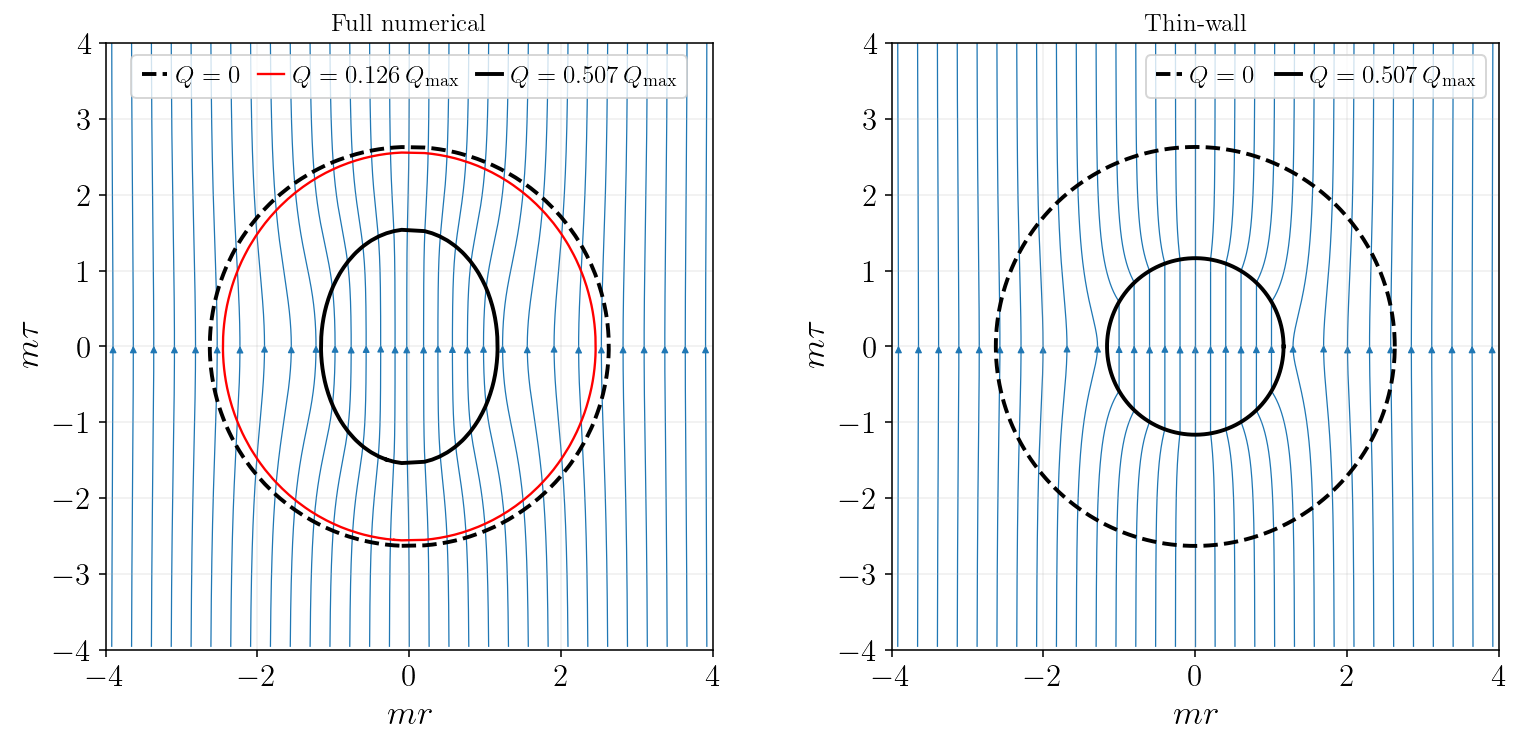

omega_ref = 9.50000000e-01
rho_i_tw  = 1.03076176e+00
rho_f_tw  = 2.00299962e+00
R0_tw     = 2.62795327e+00
R_tw      = 1.16292445e+00
Q_max source  = 2D homogeneous Q at omega_max=1.340081 from scan_summary[4], r_max=Lr=6 (section-5 1D scan used rmax=260)
Q_max         = 1.803843276761e+03
Q_black/Q_max = 0.50670184
Q_red/Q_max   = 0.12573838


In [61]:
# ============================================================
# Full numerical interface/flow vs thin-wall dielectric interface/flow
#
# Left:
#   numerical interface contours + numerical charge-flow lines.
#
# Right:
#   sharp thin-wall dielectric solution at omega_ref + analytic flux lines.
#
# Streamlines:
#   the flow lines are integrated manually from equally spaced seeds
#   placed in the asymptotic exterior at the lower boundary. This makes
#   the exterior flux look homogeneous while allowing the lines to bend
#   near the bubble.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from scipy.integrate import solve_ivp

# ------------------------------------------------------------
# Numerical input
# ------------------------------------------------------------
rho_sol_half = np.asarray(solver_o4.rho_map(sol_o4.y, sol_o4.ybar), dtype=float)
r_half = np.asarray(solver_o4.grid.r, dtype=float).flatten()
tau_half = np.asarray(solver_o4.grid.tau, dtype=float).flatten()

y_seed_o4, ybar_seed_o4 = solver_o4_seed0.unpack(np.asarray(x0_o4_seed0, dtype=float))
rho_seed_half = np.asarray(solver_o4_seed0.rho_map(y_seed_o4, ybar_seed_o4), dtype=float)

rho_red_half = np.asarray(solver_o4_red.rho_map(sol_o4_red.y, sol_o4_red.ybar), dtype=float)

# ------------------------------------------------------------
# Numerical current of the final charged solution
# ------------------------------------------------------------
y_sol = np.asarray(sol_o4.y)
ybar_sol = np.asarray(sol_o4.ybar)

phi_sol, phibar_sol = solver_o4.phi(y_sol, ybar_sol)

omega_ref = float(getattr(solver_o4, "omega", OMEGA_REF))
rho0_sol = float(solver_o4.rho0)
dtau_sol = float(getattr(solver_o4, "dt", getattr(solver_o4.grid, "dtau", None)))

Nr, Nt = y_sol.shape

j_tau_half = np.zeros_like(rho_sol_half, dtype=float)
j_r_half = np.zeros_like(rho_sol_half, dtype=float)

inv_r = np.zeros_like(r_half, dtype=float)
inv_r[r_half != 0.0] = 1.0 / r_half[r_half != 0.0]

for i_tau in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver_o4._tau_neighbors(y_sol, ybar_sol, i_tau)

    if len(tau_half) >= 2 and (tau_half[1] > tau_half[0]):
        y_t = (y_ip1 - y_im1) / (2.0 * dtau_sol)
        yb_t = (yb_ip1 - yb_im1) / (2.0 * dtau_sol)
    else:
        y_t = (y_im1 - y_ip1) / (2.0 * dtau_sol)
        yb_t = (yb_im1 - yb_ip1) / (2.0 * dtau_sol)

    y_tot = y_sol[:, i_tau] + r_half * rho0_sol
    yb_tot = ybar_sol[:, i_tau] + r_half * rho0_sol

    exp_p = np.exp(+omega_ref * tau_half[i_tau]) * inv_r
    exp_m = np.exp(-omega_ref * tau_half[i_tau]) * inv_r

    phi_tau = exp_p * (y_t + omega_ref * y_tot)
    phibar_tau = exp_m * (yb_t - omega_ref * yb_tot)

    j_tau_half[:, i_tau] = (
        phibar_sol[:, i_tau] * phi_tau
        - phi_sol[:, i_tau] * phibar_tau
    ).real

    dphi_dr = np.gradient(phi_sol[:, i_tau], r_half, edge_order=2)
    dphibar_dr = np.gradient(phibar_sol[:, i_tau], r_half, edge_order=2)

    dphi_dr[0] = 0.0
    dphibar_dr[0] = 0.0

    j_r_half[:, i_tau] = (
        phibar_sol[:, i_tau] * dphi_dr
        - phi_sol[:, i_tau] * dphibar_dr
    ).real

# ------------------------------------------------------------
# Mirror helpers
# ------------------------------------------------------------
def _mirror_full_domain_scalar(r_vec, tau_vec, field_half):
    tau_abs = np.abs(np.asarray(tau_vec, dtype=float).flatten())
    ord_tau = np.argsort(tau_abs)
    tau_abs_sorted = tau_abs[ord_tau]
    field_tau_sorted = np.asarray(field_half, dtype=float)[:, ord_tau]

    tau_full = np.concatenate([-tau_abs_sorted[::-1], tau_abs_sorted[1:]])
    field_full_tau = np.concatenate(
        [field_tau_sorted[:, ::-1], field_tau_sorted[:, 1:]],
        axis=1,
    )

    r_pos = np.asarray(r_vec, dtype=float).flatten()
    r_full = np.concatenate([-r_pos[::-1], r_pos[1:]])
    field_full = np.concatenate(
        [field_full_tau[::-1, :], field_full_tau[1:, :]],
        axis=0,
    )

    return r_full, tau_full, field_full


def _mirror_full_domain_current(r_vec, tau_vec, jr_half, jtau_half):
    tau_abs = np.abs(np.asarray(tau_vec, dtype=float).flatten())
    ord_tau = np.argsort(tau_abs)
    tau_abs_sorted = tau_abs[ord_tau]

    jr_tau_sorted = np.asarray(jr_half, dtype=float)[:, ord_tau]
    jtau_tau_sorted = np.asarray(jtau_half, dtype=float)[:, ord_tau]

    tau_full = np.concatenate([-tau_abs_sorted[::-1], tau_abs_sorted[1:]])

    jr_full_tau = np.concatenate(
        [jr_tau_sorted[:, ::-1], -jr_tau_sorted[:, 1:]],
        axis=1,
    )
    jtau_full_tau = np.concatenate(
        [jtau_tau_sorted[:, ::-1], jtau_tau_sorted[:, 1:]],
        axis=1,
    )

    r_pos = np.asarray(r_vec, dtype=float).flatten()
    r_full = np.concatenate([-r_pos[::-1], r_pos[1:]])

    jr_full = np.concatenate(
        [-jr_full_tau[::-1, :], jr_full_tau[1:, :]],
        axis=0,
    )
    jtau_full = np.concatenate(
        [jtau_full_tau[::-1, :], jtau_full_tau[1:, :]],
        axis=0,
    )

    return r_full, tau_full, jr_full, jtau_full


r_full_sol, tau_full_sol, rho_full_sol = _mirror_full_domain_scalar(
    r_half, tau_half, rho_sol_half
)
r_full_seed, tau_full_seed, rho_full_seed = _mirror_full_domain_scalar(
    r_half, tau_half, rho_seed_half
)
r_full_red, tau_full_red, rho_full_red = _mirror_full_domain_scalar(
    r_half, tau_half, rho_red_half
)
r_full_j, tau_full_j, jr_full_sol, jtau_full_sol = _mirror_full_domain_current(
    r_half, tau_half, j_r_half, j_tau_half
)

# ------------------------------------------------------------
# Interface levels
# ------------------------------------------------------------
idx_tau0 = 0

def _interface_level_from_profile(rho_half_map):
    rho_in = float(rho_half_map[0, idx_tau0])
    rho_out = float(rho_half_map[-1, idx_tau0])
    level = 0.5 * (rho_in + rho_out)

    vmin = float(np.min(rho_half_map))
    vmax = float(np.max(rho_half_map))
    span = max(vmax - vmin, 1e-14)

    level = float(np.clip(level, vmin + 1e-6 * span, vmax - 1e-6 * span))
    return rho_in, rho_out, level


rho_in_sol, rho_out_sol, level_sol = _interface_level_from_profile(rho_sol_half)
rho_in_seed, rho_out_seed, level_seed = _interface_level_from_profile(rho_seed_half)
rho_in_red, rho_out_red, level_red = _interface_level_from_profile(rho_red_half)

def _estimate_wall_radius_tau0(r_pos, rho_half_map, level):
    prof = np.asarray(rho_half_map[:, idx_tau0], dtype=float)
    f = prof - float(level)

    for j in range(len(r_pos) - 1):
        if f[j] == 0.0:
            return float(r_pos[j])

        if f[j] * f[j + 1] <= 0.0:
            fj, fj1 = float(f[j]), float(f[j + 1])
            rj, rj1 = float(r_pos[j]), float(r_pos[j + 1])

            if abs(fj1 - fj) < 1e-14:
                return 0.5 * (rj + rj1)

            return rj - fj * (rj1 - rj) / (fj1 - fj)

    return np.nan


r_wall_sol = _estimate_wall_radius_tau0(r_half, rho_sol_half, level_sol)
r_wall_seed = _estimate_wall_radius_tau0(r_half, rho_seed_half, level_seed)
r_wall_red = _estimate_wall_radius_tau0(r_half, rho_red_half, level_red)

# ------------------------------------------------------------
# Q/Qmax labels
# Q_max: omega_max from section-5 scan_summary, evaluated on the
# current 2D grid volume, not the 1D scan rmax.
# ------------------------------------------------------------
Q_black = float(
    compute_charge_tau0_ghost_2d(
        solver_o4, sol_o4.y, sol_o4.ybar, subtract_background=False
    )
)
Q_red = float(
    compute_charge_tau0_ghost_2d(
        solver_o4_red, sol_o4_red.y, sol_o4_red.ybar, subtract_background=False
    )
)


def _qmax_from_section5_scan_volume_corrected():
    """Homogeneous Q_max at omega_max of the section-5 scan, on the current 2D Lr."""
    if "scan_summary" not in globals():
        return np.nan, "missing scan_summary (run section 5)"

    if 4 in scan_summary and len(scan_summary[4]) > 0:
        branch = scan_summary[4]
        branch_name = "scan_summary[4]"
    elif 3 in scan_summary and len(scan_summary[3]) > 0:
        branch = scan_summary[3]
        branch_name = "scan_summary[3]"
    else:
        return np.nan, "scan_summary has no O(4)/O(3) points"

    omega_max = float(max(float(r["omega"]) for r in branch))

    if "CFG_2D" not in globals():
        return np.nan, "missing CFG_2D"

    Lr_2d = float(CFG_2D["Lr"])
    beta_2d = float(CFG_2D["beta"])
    r_max_scan = float(globals().get("SCAN_1D_RMAX", 260.0))

    phi_false_qmax, _ = vacua_of_Omega(
        MODEL.phi0,
        MODEL.v1,
        MODEL.v2,
        omega_max,
        verbose=False,
    )
    rho0_qmax = float(phi_false_qmax / np.sqrt(2.0))

    settings_qmax = Bubble2DSettings(
        Nr=int(CFG_2D["Nr"]),
        Ntau=int(CFG_2D["Ntau"]),
        Lr=Lr_2d,
        beta=beta_2d,
        omega_ref=omega_max,
        eta0=0.0,
        rho0=rho0_qmax,
        newton_tol=float(CFG_2D["newton_tol"]),
        newton_max_iter=int(CFG_2D["newton_max_iter"]),
        damping=float(CFG_2D["damping"]),
        max_backtracks=int(CFG_2D["max_backtracks"]),
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=bool(CFG_2D["complex_saddle"]),
        verbose=False,
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    )

    solver_qmax = Bubble2DSolver(settings_qmax, U, dU, d2U)
    targets_qmax = compute_targets_tau0_ghost(
        solver_qmax,
        subtract_background_charge=False,
    )
    Q_max_2d = float(targets_qmax["Q"])

    src = (
        f"2D homogeneous Q at omega_max={omega_max:.6f} from {branch_name}, "
        f"r_max=Lr={Lr_2d:g} (section-5 1D scan used rmax={r_max_scan:g})"
    )
    return Q_max_2d, src


Q_max, Q_max_source = _qmax_from_section5_scan_volume_corrected()

if not np.isfinite(Q_max) or Q_max <= 1e-30:
    if "_infer_static_qmax_ref" in globals():
        Q_max, Q_max_source = _infer_static_qmax_ref()
        Q_max_source = f"fallback: {Q_max_source}"
    else:
        Q_max = max(Q_black, Q_red, 1e-30)
        Q_max_source = "fallback: max(2D charges)"

qratio_black = Q_black / Q_max
qratio_red = Q_red / Q_max

# ------------------------------------------------------------
# Numerical current on uniform grid
# ------------------------------------------------------------
upsample_factor = 4
nr_uni = max(160, int(upsample_factor * len(r_full_j)))
nt_uni = max(160, int(upsample_factor * len(tau_full_j)))

r_uni = np.linspace(float(r_full_j.min()), float(r_full_j.max()), nr_uni)
tau_uni = np.linspace(float(tau_full_j.min()), float(tau_full_j.max()), nt_uni)

jr_spline = RectBivariateSpline(r_full_j, tau_full_j, jr_full_sol, kx=3, ky=3, s=0.0)
jtau_spline = RectBivariateSpline(r_full_j, tau_full_j, jtau_full_sol, kx=3, ky=3, s=0.0)

jr_uni = jr_spline(r_uni, tau_uni).T
jtau_uni = jtau_spline(r_uni, tau_uni).T

# Small smoothing removes grid artefacts but keeps the asymptotic structure.
jr_uni = gaussian_filter(jr_uni, sigma=0.6, mode="nearest")
jtau_uni = gaussian_filter(jtau_uni, sigma=0.6, mode="nearest")

jmag_uni = np.sqrt(jr_uni**2 + jtau_uni**2)
jmag_max = float(np.max(jmag_uni)) if jmag_uni.size else 0.0

# ------------------------------------------------------------
# Thin-wall dielectric current at omega_ref
# ------------------------------------------------------------
xlim = 4.0
ylim = 4.0

n_tw = 420
r_tw_grid = np.linspace(-xlim, xlim, n_tw)
tau_tw_grid = np.linspace(-ylim, ylim, n_tw)
XX, TT = np.meshgrid(r_tw_grid, tau_tw_grid, indexing="xy")

XI_tw = np.sqrt(XX**2 + TT**2)
XI_safe = np.maximum(XI_tw, 1e-12)

R_tw = float(r_wall_sol)
R0_tw = float(r_wall_seed)

rho_i_tw = float(rho_out_sol)
rho_f_tw = float(rho_in_sol)

eps_out = rho_i_tw**2
eps_in = rho_f_tw**2

den = eps_in + 3.0 * eps_out
A_in = 4.0 * eps_out / den
B_out = (eps_out - eps_in) / den

inside_tw = XI_tw < R_tw

# alpha_out = omega_ref * [1 + B R^4 / xi^4] * tau
# alpha_in  = omega_ref * A * tau
dalpha_dr_out = -4.0 * omega_ref * B_out * R_tw**4 * XX * TT / XI_safe**6
dalpha_dt_out = omega_ref * (
    1.0
    + B_out * R_tw**4 / XI_safe**4
    - 4.0 * B_out * R_tw**4 * TT**2 / XI_safe**6
)

dalpha_dr_in = np.zeros_like(XX)
dalpha_dt_in = omega_ref * A_in * np.ones_like(XX)

j_r_tw = np.where(inside_tw, eps_in * dalpha_dr_in, eps_out * dalpha_dr_out)
j_tau_tw = np.where(inside_tw, eps_in * dalpha_dt_in, eps_out * dalpha_dt_out)

# Smooth only mildly for visual continuity across the sharp interface.
j_r_tw_plot = gaussian_filter(j_r_tw, sigma=0.6, mode="nearest")
j_tau_tw_plot = gaussian_filter(j_tau_tw, sigma=0.6, mode="nearest")

jmag_tw = np.sqrt(j_r_tw_plot**2 + j_tau_tw_plot**2)
jmag_tw_max = float(np.max(jmag_tw)) if jmag_tw.size else 0.0

# ------------------------------------------------------------
# Manual streamline integration
# ------------------------------------------------------------
def _plot_manual_streamlines(
    ax,
    x_grid,
    y_grid,
    u_grid,
    v_grid,
    seed_x,
    seed_y,
    arrow_y=0.0,
    color="C0",
    lw=0.7,
    arrowsize=1.0,
    zorder=1,
    max_step=0.015,
):
    """
    Draw physical streamlines from fixed seeds in the asymptotic exterior.

    x_grid, y_grid:
        1D grid arrays.

    u_grid, v_grid:
        arrays with shape (len(y_grid), len(x_grid)).

    seed_x:
        equally spaced seed positions.

    seed_y:
        common initial y position, chosen near the lower boundary.

    The line spacing is therefore fixed in the exterior. The spacing is not
    forced near the bubble, because the bending/focusing is the physical effect
    we want to show.
    """

    u_interp = RegularGridInterpolator(
        (y_grid, x_grid),
        u_grid,
        bounds_error=False,
        fill_value=np.nan,
    )
    v_interp = RegularGridInterpolator(
        (y_grid, x_grid),
        v_grid,
        bounds_error=False,
        fill_value=np.nan,
    )

    xmin, xmax = float(np.min(x_grid)), float(np.max(x_grid))
    ymin, ymax = float(np.min(y_grid)), float(np.max(y_grid))

    def _eval_interp(interp, x, y):
        return float(np.asarray(interp((y, x))))

    def rhs(s, Y):
        x, y = float(Y[0]), float(Y[1])

        if x <= xmin or x >= xmax or y <= ymin or y >= ymax:
            return [0.0, 0.0]

        uu = _eval_interp(u_interp, x, y)
        vv = _eval_interp(v_interp, x, y)

        if not np.isfinite(uu) or not np.isfinite(vv):
            return [0.0, 0.0]

        norm = np.hypot(uu, vv)

        if norm < 1e-14:
            return [0.0, 0.0]

        # Normalize the vector field. This makes the plotted lines insensitive
        # to the local magnitude of the current and shows only the direction.
        return [uu / norm, vv / norm]

    def boundary_event(s, Y):
        x, y = float(Y[0]), float(Y[1])
        return min(x - xmin, xmax - x, y - ymin, ymax - y)

    boundary_event.terminal = True
    boundary_event.direction = -1

    smax = 5.0 * max(xmax - xmin, ymax - ymin)

    for x0 in seed_x:
        if x0 <= xmin or x0 >= xmax:
            continue
        if seed_y <= ymin or seed_y >= ymax:
            continue

        sol = solve_ivp(
            rhs,
            t_span=(0.0, smax),
            y0=[float(x0), float(seed_y)],
            max_step=max_step,
            rtol=1e-5,
            atol=1e-7,
            events=boundary_event,
        )

        if sol.y.shape[1] <= 2:
            continue

        curve = sol.y.T

        ax.plot(
            curve[:, 0],
            curve[:, 1],
            color=color,
            lw=lw,
            zorder=zorder,
        )

        if curve.shape[0] > 12:
            idx = np.argmin(np.abs(curve[:, 1] - arrow_y))
            idx = int(np.clip(idx, 1, curve.shape[0] - 2))

            ax.annotate(
                "",
                xy=(curve[idx + 1, 0], curve[idx + 1, 1]),
                xytext=(curve[idx - 1, 0], curve[idx - 1, 1]),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=color,
                    lw=lw,
                    mutation_scale=8.0 * arrowsize,
                ),
                zorder=zorder,
            )

# ------------------------------------------------------------
# Fixed streamline seeds in the asymptotic exterior
# ------------------------------------------------------------
N_FLOW_LINES = 31

seed_margin_x = 0.08
seed_margin_y = 0.05

seed_x = np.linspace(
    -xlim + seed_margin_x,
    +xlim - seed_margin_x,
    N_FLOW_LINES,
)

# Seed from the exterior, not from the middle of the bubble.
seed_y = -ylim + seed_margin_y

# Put arrows near the middle for readability.
arrow_y = 0.0

# ------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------
def _plot_inner_interface(ax_obj, r_vec, tau_vec, rho_map_T, level, color, lw, ls, r_wall_expected=np.nan):
    cs = ax_obj.contour(
        r_vec,
        tau_vec,
        rho_map_T,
        levels=[float(level)],
        colors=color,
        linewidths=0.01,
        linestyles=ls,
        alpha=0.0,
    )
    segs = cs.allsegs[0] if len(cs.allsegs) > 0 else []

    try:
        cs.remove()
    except Exception:
        pass

    if len(segs) == 0:
        return

    best = None
    best_score = np.inf

    for seg in segs:
        if seg.shape[0] < 8:
            continue

        if np.isfinite(r_wall_expected):
            dpos = np.min((seg[:, 0] - r_wall_expected) ** 2 + seg[:, 1] ** 2)
            dneg = np.min((seg[:, 0] + r_wall_expected) ** 2 + seg[:, 1] ** 2)
            score = float(dpos + dneg)
        else:
            score = float(np.mean(seg[:, 0] ** 2 + seg[:, 1] ** 2))

        if score < best_score:
            best_score = score
            best = seg

    if best is None:
        best = max(segs, key=lambda s: s.shape[0])

    ax_obj.plot(best[:, 0], best[:, 1], color=color, lw=lw, ls=ls, zorder=3)

# ------------------------------------------------------------
# Two-panel figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2), constrained_layout=True)
axL, axR = axes

# Left: full numerical plot
_plot_inner_interface(
    axL, r_full_sol, tau_full_sol, rho_full_sol.T, level_sol,
    color="k", lw=2.0, ls="-", r_wall_expected=r_wall_sol
)
_plot_inner_interface(
    axL, r_full_seed, tau_full_seed, rho_full_seed.T, level_seed,
    color="k", lw=2.0, ls="--", r_wall_expected=r_wall_seed
)
_plot_inner_interface(
    axL, r_full_red, tau_full_red, rho_full_red.T, level_red,
    color="r", lw=1.2, ls="-", r_wall_expected=r_wall_red
)

if jmag_max > 0.0:
    _plot_manual_streamlines(
        axL,
        r_uni,
        tau_uni,
        jr_uni,
        jtau_uni,
        seed_x=seed_x,
        seed_y=seed_y,
        arrow_y=arrow_y,
        color="C0",
        lw=0.65,
        arrowsize=0.9,
        zorder=1,
        max_step=0.015,
    )

axL.plot([], [], "k--", lw=2.0, label=r"$Q=0$")
axL.plot([], [], "r-", lw=1.2, label=rf"$Q={qratio_red:.3f}\,Q_{{\max}}$")
axL.plot([], [], "k-", lw=2.0, label=rf"$Q={qratio_black:.3f}\,Q_{{\max}}$")
axL.set_title("Full numerical")
axL.legend(
    loc="upper center",
    fontsize=13,
    ncol=3,
    handlelength=1.0,
    handletextpad=0.35,
    columnspacing=0.7,
)

# Right: thin-wall dielectric
if jmag_tw_max > 0.0:
    _plot_manual_streamlines(
        axR,
        r_tw_grid,
        tau_tw_grid,
        j_r_tw_plot,
        j_tau_tw_plot,
        seed_x=seed_x,
        seed_y=seed_y,
        arrow_y=arrow_y,
        color="C0",
        lw=0.65,
        arrowsize=0.9,
        zorder=1,
        max_step=0.015,
    )

theta = np.linspace(0.0, 2.0 * np.pi, 800)

axR.plot(
    R0_tw * np.cos(theta),
    R0_tw * np.sin(theta),
    "k--",
    lw=2.0,
    label=r"$Q=0$",
)
axR.plot(
    R_tw * np.cos(theta),
    R_tw * np.sin(theta),
    "k-",
    lw=2.0,
    label=rf"$Q={qratio_black:.3f}\,Q_{{\max}}$",
)

axR.set_title("Thin-wall")
axR.legend(
    loc="upper right",
    fontsize=13,
    ncol=2,
    handlelength=1.0,
    handletextpad=0.35,
    columnspacing=0.8,
)

for ax in axes:
    ax.set_xlabel(r"$mr$", fontsize=18)
    ax.set_ylabel(r"$m\tau$", fontsize=18)
    ax.tick_params(axis="both", labelsize=16)
    ax.set_xlim(-xlim, xlim)
    ax.set_ylim(-ylim, ylim)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)

if CFG.get("save_figures", False):
    fig.savefig(
        CFG["figures_dir"] / "o4_interface_charge_flow_numeric_vs_tw.pdf",
        bbox_inches="tight",
    )

plt.show()

print(f"omega_ref = {omega_ref:.8e}")
print(f"rho_i_tw  = {rho_i_tw:.8e}")
print(f"rho_f_tw  = {rho_f_tw:.8e}")
print(f"R0_tw     = {R0_tw:.8e}")
print(f"R_tw      = {R_tw:.8e}")
print(f"Q_max source  = {Q_max_source}")
print(f"Q_max         = {Q_max:.12e}")
print(f"Q_black/Q_max = {qratio_black:.8f}")
print(f"Q_red/Q_max   = {qratio_red:.8f}")

## 16. Paper figures

The following cells assemble the figure panels from the results computed above.

### 16.1 Scalar potential: two-branch construction

Clean plot of the scalar potential on the full domain $0\leq\phi\leq2$ by combining:

- branch (1) on $0\leq\phi\leq1$ from the analytic expression with $\phi_{0+}=1-\epsilon$, $\epsilon=10^{-13}$,
- branch (2) on $1\leq\phi\leq2$ reusing the project implementation already used in the workflow.

In the same figure we also plot $\Omega(\phi)$ using the existing project definition, and mark the false/true vacua of branch (2).

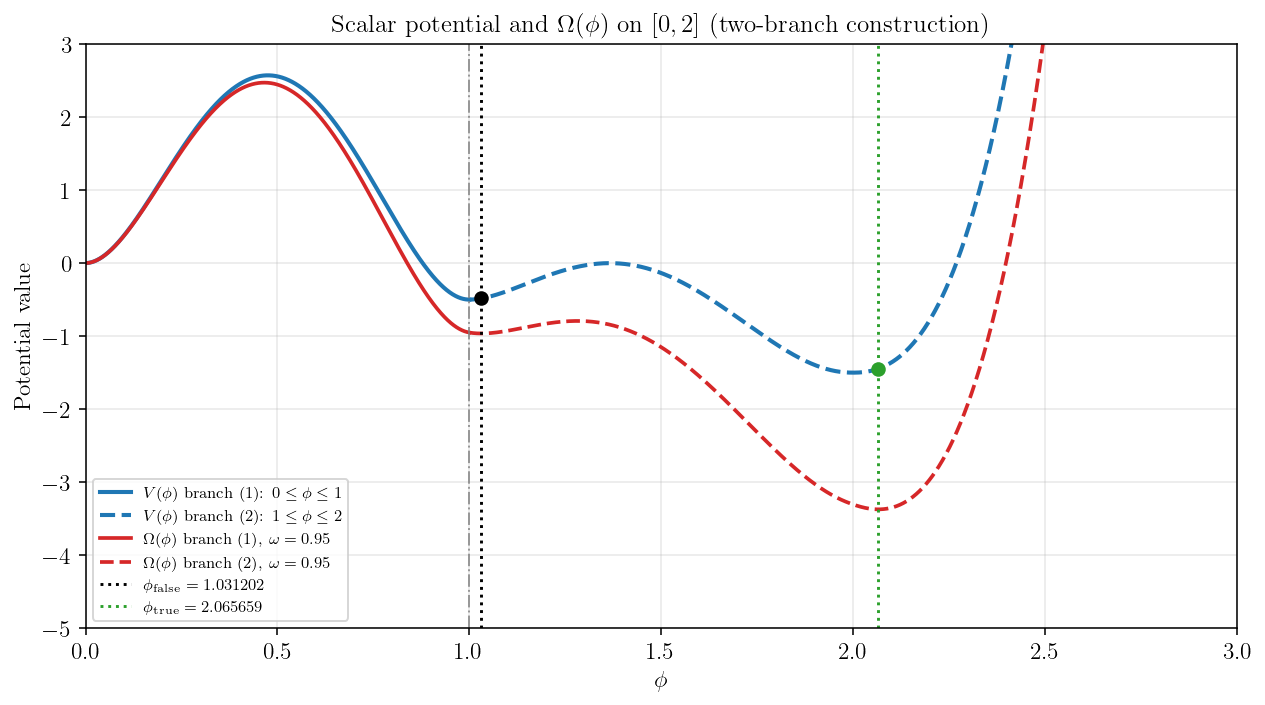

False vacuum (branch 2): phi_false = 1.0312018015
True vacuum  (branch 2): phi_true  = 2.0656590991


In [64]:
# Two-branch scalar potential + Omega on a single plot (minimal integration)
import numpy as np
import matplotlib.pyplot as plt

required_symbols = ["MODEL", "V_phi", "Omega_phi", "vacua_of_Omega"]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Missing required project symbols: {missing_symbols}")

# Keep project convention for omega used in Omega(phi)
omega_plot = float(globals().get("OMEGA_REF", 0.95))

# Numerical safeguards near logarithmic endpoints
delta_phi = 1e-8
epsilon = 1e-13
phi0_plus = 1.0 - epsilon

# Branch (1): 0 <= phi <= 1 (excluding exact singular endpoints)
phi_01 = np.linspace(delta_phi, 1.0 - delta_phi, 1600)

def V1_branch(phi, phi0p):
    phi = np.asarray(phi, dtype=float)
    one_minus = 1.0 - phi
    log_arg = ((1.0 - phi) * phi0p) / np.maximum(phi * (1.0 - phi0p), 1e-300)
    bracket = (2.0 * phi) / 3.0 - 1.0 + (one_minus**2) * np.log(np.maximum(log_arg, 1e-300))
    return 1.5 * (phi**2) * bracket

V1_vals = V1_branch(phi_01, phi0_plus)

# Branch (2): 1 <= phi <= 2 (reuse existing project implementation)
phi_12 = np.linspace(1.0 + delta_phi, 2.5 - delta_phi, 1600)
V2_vals = V_phi(phi_12, MODEL.phi0, MODEL.v1, MODEL.v2)

# Grand potential on each branch: Omega = V_branch - (1/2) omega^2 phi^2
Omega1_vals = V1_vals - 0.5 * omega_plot**2 * phi_01**2
Omega2_vals = V2_vals - 0.5 * omega_plot**2 * phi_12**2

# Vacua of branch (2) with the existing routine
phi_false_b2, phi_true_b2 = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, omega_plot, verbose=False)
phi_false_b2 = float(phi_false_b2)
phi_true_b2 = float(phi_true_b2)

V_false = float(V_phi(np.array([phi_false_b2]), MODEL.phi0, MODEL.v1, MODEL.v2)[0])
V_true = float(V_phi(np.array([phi_true_b2]), MODEL.phi0, MODEL.v1, MODEL.v2)[0])

# Plot everything on one axis, with clear branch styling
fig, ax = plt.subplots(figsize=(9.2, 5.2))

# V(phi)
ax.plot(phi_01, V1_vals, color="C0", lw=2.1, label=r"$V(\phi)$ branch (1): $0\leq\phi\leq1$")
ax.plot(phi_12, V2_vals, color="C0", lw=2.1, ls="--", label=r"$V(\phi)$ branch (2): $1\leq\phi\leq2$")

# Omega(phi)
ax.plot(phi_01, Omega1_vals, color="C3", lw=1.9, label=rf"$\Omega(\phi)$ branch (1), $\omega={omega_plot:.2f}$")
ax.plot(phi_12, Omega2_vals, color="C3", lw=1.9, ls="--", label=rf"$\Omega(\phi)$ branch (2), $\omega={omega_plot:.2f}$")

# Vacua markers/lines (branch 2)
ax.axvline(phi_false_b2, color="k", ls=":", lw=1.5, label=rf"$\phi_{{\rm false}}={phi_false_b2:.6f}$")
ax.axvline(phi_true_b2, color="C2", ls=":", lw=1.5, label=rf"$\phi_{{\rm true}}={phi_true_b2:.6f}$")
ax.scatter([phi_false_b2], [V_false], color="k", s=42, zorder=6)
ax.scatter([phi_true_b2], [V_true], color="C2", s=42, zorder=6)

# Light visual cue for branch split
ax.axvline(1.0, color="0.5", ls="-.", lw=1.0, alpha=0.8)

ax.set_xlim(0.0, 3.0)
ax.set_ylim(-5, 3)
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"Potential value")
ax.set_title(r"Scalar potential and $\Omega(\phi)$ on $[0,2]$ (two-branch construction)")
ax.grid(alpha=0.28)
ax.legend(fontsize=8, loc="best")
fig.tight_layout()

# Save plot with project-compatible behavior
out_png = None
if "CFG" in globals() and CFG.get("save_figures", False):
    out_pdf = CFG["figures_dir"] / "scalar_potential_and_omega.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print(f"False vacuum (branch 2): phi_false = {phi_false_b2:.10f}")
print(f"True vacuum  (branch 2): phi_true  = {phi_true_b2:.10f}")
if out_png is not None:
    print(f"Saved: {out_png}")

### 16.2 Effective potential branches colored by $Q_{\mathrm{hom}}/Q_{\max}$

Scan of the effective scalar potential across many $\omega$ values on the full domain $\phi\in[0,2]$, with each curve colored by the homogeneous-charge ratio $Q_{\mathrm{hom}}/Q_{\max}$ computed with the same project conventions used elsewhere in the notebook.

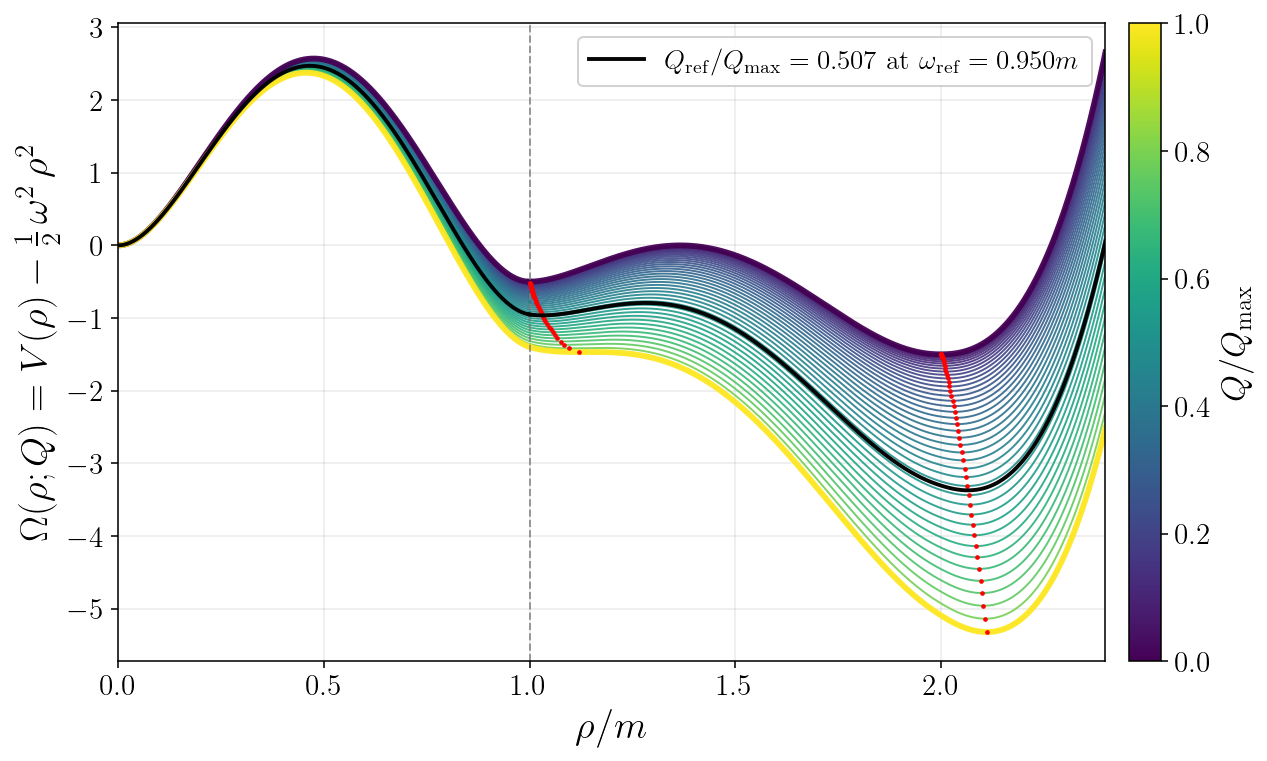

omega_min = 0.00000000
omega_max = 1.34008117
omega bounds source = omega_scan
number of curves plotted = 44
Q_hom/Q_max range = [0.00000000, 1.00000000]
phi_hom range    = [1.00116765, 2.00417014]
Q_max from scan  = 1.80384328e+03
Saved figure: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Qubble/Bubble_finder/notebooks/figures/scalar_potential_branches_colored_by_Q.pdf
Special highlighted curve at omega_ref = 0.950000 (exact)


In [63]:
# Effective-potential scan in omega, colored by Q_hom/Q_max
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors

required = ["MODEL", "V_phi", "Omega_phi", "vacua_of_Omega", "compute_targets_tau0_ghost"]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required symbols: {missing}")

# ---- omega range (prioritize the dedicated omega scan section) ----
def _infer_omega_bounds_for_plot():
    # 1) Preferred source: explicit omega scan grid from the scan section
    if "omega_scan" in globals() and len(omega_scan) > 1:
        arr = np.asarray(omega_scan, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size > 1:
            return float(np.min(arr)), float(np.max(arr)), "omega_scan"

    # 2) Next: OMEGA_MAX from estimate_omega_max and corresponding standard range
    if "OMEGA_MAX" in globals() and np.isfinite(float(OMEGA_MAX)):
        return 0.0, float(float(OMEGA_MAX)), "OMEGA_MAX"

    # 3) Fallback: terminal scan bounds
    if "omega_list_terminal" in globals() and len(omega_list_terminal) > 1:
        return float(np.min(omega_list_terminal)), float(np.max(omega_list_terminal)), "omega_list_terminal"

    wmin = float(globals().get("omega_start_scan_terminal", 0.05))
    if "omega_max_scan_terminal" in globals():
        wmax = float(omega_max_scan_terminal)
    elif "_infer_omega_max_for_scan" in globals():
        wmax = float(_infer_omega_max_for_scan())
    else:
        wmax = 1.5
    return wmin, float(wmax), "fallback"

omega_min_plot, omega_max_plot, omega_bounds_source = _infer_omega_bounds_for_plot()
if not np.isfinite(omega_min_plot) or not np.isfinite(omega_max_plot) or omega_max_plot <= omega_min_plot:
    raise RuntimeError(f"Invalid omega range: [{omega_min_plot}, {omega_max_plot}]")

n_omega_plot = 44
omega_plot_list = np.linspace(omega_min_plot, omega_max_plot, n_omega_plot)

# ---- phi grids (avoid exact singular endpoints) ----
delta_phi = 1e-8
phi_01 = np.linspace(delta_phi, 1.0 - delta_phi, 1000)
phi_12 = np.linspace(1.0 + delta_phi, 2.4 - delta_phi, 1200)

# Branch (1) potential requested in previous section
epsilon = 1e-13
phi0_plus = 1.0 - epsilon

def V1_branch(phi, phi0p):
    phi = np.asarray(phi, dtype=float)
    one_minus = 1.0 - phi
    log_arg = ((1.0 - phi) * phi0p) / np.maximum(phi * (1.0 - phi0p), 1e-300)
    bracket = (2.0 * phi) / 3.0 - 1.0 + (one_minus**2) * np.log(np.maximum(log_arg, 1e-300))
    return 1.5 * (phi**2) * bracket

# ---- helper: reuse existing solver construction if present ----
def _solver_for_hom_charge(omega_now: float):
    beta_here = float(globals().get("beta_fixed_terminal_scan", CFG_2D["beta"]))
    if "_make_solver_for_omega" in globals():
        return _make_solver_for_omega(float(omega_now), eta0_guess=0.0, beta_fixed=beta_here)

    # Fallback path reusing existing project classes/conventions
    phi_false_now, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, float(omega_now), verbose=False)
    rho0_now = float(phi_false_now / np.sqrt(2.0))
    settings = Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=float(beta_here),
        omega_ref=float(omega_now),
        eta0=0.0,
        rho0=float(rho0_now),
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=False,
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    )
    return Bubble2DSolver(settings, U, dU, d2U)


curves = []
Q_hom_list = []
phi_hom_list = []


def _pick_false_true_minima(phi_grid, veff_grid):
    """Find false/true minima directly from sampled effective branch-2 potential."""
    p = np.asarray(phi_grid, dtype=float)
    v = np.asarray(veff_grid, dtype=float)
    m = np.isfinite(p) & np.isfinite(v)
    p = p[m]
    v = v[m]
    if p.size < 5:
        return np.nan, np.nan, np.nan, np.nan

    idx = np.where((v[1:-1] <= v[:-2]) & (v[1:-1] <= v[2:]))[0] + 1
    if idx.size == 0:
        return np.nan, np.nan, np.nan, np.nan

    i_false = idx[np.argmin(np.abs(p[idx] - 1.0))]
    i_true = idx[np.argmin(np.abs(p[idx] - 2.0))]

    if i_true == i_false and idx.size > 1:
        order = np.argsort(np.abs(p[idx] - 2.0))
        for j in order:
            if idx[j] != i_false:
                i_true = idx[j]
                break

    return float(p[i_false]), float(p[i_true]), float(v[i_false]), float(v[i_true])


for om in omega_plot_list:
    # Potentials on two branches
    V1_vals = V1_branch(phi_01, phi0_plus)
    V2_vals = V_phi(phi_12, MODEL.phi0, MODEL.v1, MODEL.v2)

    # Effective potentials with requested convention: V_eff = V - (1/2) * omega * phi
    Veff1 = V1_vals - 0.5 * om**2 * phi_01**2
    Veff2 = V2_vals - 0.5 * om**2 * phi_12**2

    # False/true minima positions directly from effective branch-2 potential
    phi_false_now, phi_true_now, vf, vt = _pick_false_true_minima(phi_12, Veff2)
    phi_hom_now = phi_false_now

    # Homogeneous charge in existing project convention
    try:
        solver_q = _solver_for_hom_charge(float(om))
        tgt_q = compute_targets_tau0_ghost(solver_q, subtract_background_charge=False)
        Q_hom_now = float(tgt_q["Q"])
    except Exception:
        Q_hom_now = np.nan

    curves.append({
        "omega": float(om),
        "phi1": phi_01,
        "phi2": phi_12,
        "Veff1": Veff1,
        "Veff2": Veff2,
        "phi_hom": phi_hom_now,
        "Q_hom": Q_hom_now,
        "phi_false": phi_false_now,
        "phi_true": phi_true_now,
        "Veff_false": vf,
        "Veff_true": vt,
    })
    Q_hom_list.append(Q_hom_now)
    phi_hom_list.append(phi_hom_now)

Q_hom_arr = np.asarray(Q_hom_list, dtype=float)
finite_q = np.isfinite(Q_hom_arr)
if np.count_nonzero(finite_q) == 0:
    raise RuntimeError("No finite Q_hom values were obtained in the omega scan.")

Q_max_scan = float(np.nanmax(Q_hom_arr[finite_q]))
if not np.isfinite(Q_max_scan) or abs(Q_max_scan) < 1e-30:
    raise RuntimeError(f"Invalid Q_max from scan: {Q_max_scan}")

for c in curves:
    qh = float(c["Q_hom"]) if np.isfinite(c["Q_hom"]) else np.nan
    c["q_norm"] = float(qh / Q_max_scan) if np.isfinite(qh) else np.nan

# ---- plotting ----
cmap = cm.get_cmap("viridis")
norm = colors.Normalize(vmin=float(np.nanmin([c["q_norm"] for c in curves if np.isfinite(c["q_norm"])])),
                        vmax=float(np.nanmax([c["q_norm"] for c in curves if np.isfinite(c["q_norm"])])))

fig, ax = plt.subplots(figsize=(9.6, 5.6))

for c in curves:
    if not np.isfinite(c["q_norm"]):
        color = "orange"
        lw = 0.9
        alpha = 0.6
    else:
        color = cmap(norm(c["q_norm"]))
        lw = 1.0
        alpha = 0.9

    ax.plot(c["phi1"], c["Veff1"], color=color, lw=lw, alpha=alpha)
    ax.plot(c["phi2"], c["Veff2"], color=color, lw=lw, alpha=alpha)

# Highlight representative omegas: min, mid, max (without omega text labels)
idx_rep = [0, len(curves)-1]
for idx in idx_rep:
    c = curves[idx]
    color = "k" if not np.isfinite(c["q_norm"]) else cmap(norm(c["q_norm"]))
    ax.plot(c["phi1"], c["Veff1"], color=color, lw=3, alpha=0.95)
    ax.plot(c["phi2"], c["Veff2"], color=color, lw=3, alpha=0.95)

# Special highlight: curve at exactly omega = OMEGA_REF
omega_ref_special = float(globals().get("OMEGA_REF", 0.95))
om_ref = float(omega_ref_special)
V1_ref = V1_branch(phi_01, phi0_plus)
V2_ref = V_phi(phi_12, MODEL.phi0, MODEL.v1, MODEL.v2)
Veff1_ref = V1_ref - 0.5 * om_ref**2 * phi_01**2
Veff2_ref = V2_ref - 0.5 * om_ref**2 * phi_12**2
phi_false_ref, phi_true_ref, vf_ref, vt_ref = _pick_false_true_minima(phi_12, Veff2_ref)
phi_hom_ref = phi_false_ref
try:
    solver_q_ref = _solver_for_hom_charge(om_ref)
    tgt_q_ref = compute_targets_tau0_ghost(solver_q_ref, subtract_background_charge=False)
    Q_hom_ref = float(tgt_q_ref["Q"])
except Exception:
    Q_hom_ref = np.nan
qh_ref = float(Q_hom_ref) if np.isfinite(Q_hom_ref) else np.nan
q_ref_norm = float(qh_ref / Q_max_scan) if np.isfinite(qh_ref) else np.nan
c_ref = {
    "omega": om_ref,
    "phi1": phi_01,
    "phi2": phi_12,
    "Veff1": Veff1_ref,
    "Veff2": Veff2_ref,
    "phi_hom": phi_hom_ref,
    "Q_hom": Q_hom_ref,
    "phi_false": phi_false_ref,
    "phi_true": phi_true_ref,
    "Veff_false": vf_ref,
    "Veff_true": vt_ref,
    "q_norm": q_ref_norm,
}
if np.isfinite(q_ref_norm):
    ref_label = rf"$Q_{{\rm ref}}/Q_{{\max}}={q_ref_norm:.3f}$ at $\omega_{{\rm ref}}={om_ref:.3f}m$"
else:
    ref_label = rf"$Q_{{\rm ref}}/Q_{{\max}}=\mathrm{{nan}}$ at $\omega_{{\rm ref}}={om_ref:.3f}m$"

ax.plot(c_ref["phi1"], c_ref["Veff1"], color="black", lw=2.0, alpha=0.98, zorder=7, label=ref_label)
ax.plot(c_ref["phi2"], c_ref["Veff2"], color="black", lw=2.0, alpha=0.98, zorder=7)

# Plot all vacuum points (phi_false and phi_true) as small red markers
phi_false_pts = np.asarray([c["phi_false"] for c in curves], dtype=float)
V_false_pts = np.asarray([c["Veff_false"] for c in curves], dtype=float)
phi_true_pts = np.asarray([c["phi_true"] for c in curves], dtype=float)
V_true_pts = np.asarray([c["Veff_true"] for c in curves], dtype=float)

mf = np.isfinite(phi_false_pts) & np.isfinite(V_false_pts)
mt = np.isfinite(phi_true_pts) & np.isfinite(V_true_pts)

ax.scatter(phi_false_pts[mf], V_false_pts[mf], s=2, color="red", zorder=6)
ax.scatter(phi_true_pts[mt], V_true_pts[mt], s=2, color="red", zorder=6)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$Q/Q_{\max}$", fontsize=18)
cbar.ax.tick_params(labelsize=15)

ax.axvline(1.0, color="0.5", ls="--", lw=1.0, alpha=0.8)
ax.set_xlim(0.0, 2.4)
ax.set_xlabel(r"$\rho/m$", fontsize=20)
ax.set_ylabel(r"$\Omega(\rho;Q)=V(\rho)-\frac{1}{2}\,\omega^2\,\rho^2$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)
#ax.set_title(r"Effective potential branches ( $V-\frac{1}{2}\omega\phi$ ) colored by $Q_{\mathrm{hom}}/Q_{\max}$")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=14, framealpha=0.9)
fig.tight_layout()

# Save figure (PDF only)
if "CFG" in globals() and CFG.get("save_figures", False):
    out_path = CFG["figures_dir"] / "scalar_potential_branches_colored_by_Q.pdf"
else:
    out_path = "scalar_potential_branches_colored_by_Q.pdf"
fig.savefig(out_path, bbox_inches="tight")
plt.show()

# Diagnostics
phi_hom_arr = np.asarray(phi_hom_list, dtype=float)
q_norm_arr = np.asarray([c["q_norm"] for c in curves], dtype=float)
print(f"omega_min = {omega_min_plot:.8f}")
print(f"omega_max = {omega_max_plot:.8f}")
print(f"omega bounds source = {omega_bounds_source}")
print(f"number of curves plotted = {len(curves)}")
print(f"Q_hom/Q_max range = [{np.nanmin(q_norm_arr):.8f}, {np.nanmax(q_norm_arr):.8f}]")
print(f"phi_hom range    = [{np.nanmin(phi_hom_arr):.8f}, {np.nanmax(phi_hom_arr):.8f}]")
print(f"Q_max from scan  = {Q_max_scan:.8e}")
print(f"Saved figure: {out_path}")
print(f"Special highlighted curve at omega_ref = {omega_ref_special:.6f} (exact)")
